In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import argparse
from pathlib import Path
import re
import random
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from pathlib import Path
import re, random, math, os
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
save_dir = '/content/drive/MyDrive/CD/2Bio_SHAP/'
K_FOLDS          = 7
BATCH_SIZE =3

TRAIN_ADD_GAUSS_NOISE = True
TRAIN_NOISE_FRAC      = 0.0   # set >0 to actually add noise
TRAIN_NOISE_PROB      = 1.0
EPS_STD               = 1e-8

### Reading the BF data

In [4]:
bf_path = '/content/drive/MyDrive/ALL_CLEAN_DEIDEN_NAME AND ECMO DATA(Sheet1) (1) (version 2).csv'
cols = ['ID', 'age_days', 'Diagnosis']
df = pd.read_csv(bf_path, usecols=cols)

for col in ['age_days']:
    s = pd.to_numeric(df[col], errors='coerce')
    mx = s.max(skipna=True)
    if pd.notna(mx) and mx != 0:
        df[col] = s / mx
    else:
        df[col] = s
print(df.head())

   ID  age_days            Diagnosis
0   1  0.018213       Cardiac Arrest
1   2  0.072852       Cardiac Arrest
2   3  0.793776               Sepsis
3   4  0.000287  Respiratory Failure
4   5  0.000287  Respiratory Failure


In [5]:
diag_clean = (
    df['Diagnosis']
      .astype('string')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .fillna('Unknown')
)

codes, uniques = pd.factorize(diag_clean, sort=True)
df['Diagnosis'] = codes.astype('int64')
diagnosis_mapping = {cat: int(i) for i, cat in enumerate(uniques)}
print("Diagnosis mapping (category -> code):", diagnosis_mapping)

# Peek
print(df.head())

Diagnosis mapping (category -> code): {'Cardiac Arrest': 0, 'Cardiogenic Shock': 1, 'Respiratory Failure': 2, 'Sepsis': 3, 'Septic shock': 4}
   ID  age_days  Diagnosis
0   1  0.018213          0
1   2  0.072852          0
2   3  0.793776          3
3   4  0.000287          2
4   5  0.000287          2


In [6]:
df.head()

,ID,age_days,Diagnosis
0,1,0.018213,0
1,2,0.072852,0
2,3,0.793776,3
3,4,0.000287,2
4,5,0.000287,2


In [7]:
from pathlib import Path
import re, random, math, os
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# Config
# =========================
SPLIT_DIR = r"/content/drive/MyDrive/CD/patient_data_clean_nozero_181920212223_1800"
save_dir = '/content/drive/MyDrive/CD/2Bio_SHAP/'
POS_PATIENTS = {1, 2, 16, 19, 21, 22, 25, 37, 39, 43, 44, 47, 50, 56, 58, 62, 65, 66, 73, 78}

BATCH_SIZE       = 3
EPOCHS           = 100
LR               = 1e-4
SEED             = 1
K_FOLDS          = 7

# (kept for reference; not used to fix height)
TARGET_H = 400

# =========================
# Noise config (train-time augmentation only, EEG input only)
# =========================
TRAIN_ADD_GAUSS_NOISE = True
TRAIN_NOISE_FRAC      = 0.0   # set >0 to actually add noise
TRAIN_NOISE_PROB      = 1.0
EPS_STD               = 1e-8

# Ensure base save dir exists
Path(save_dir).mkdir(parents=True, exist_ok=True)

# =========================
# Repro
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# =========================
# Helpers
# =========================
PATIENT_NUM_RX = re.compile(r'^ID(\d+)')  # e.g., "ID76-2_..." -> 76

def patient_num_from_path(pathlike):
    stem = Path(pathlike).stem
    m = PATIENT_NUM_RX.match(stem)
    return int(m.group(1)) if m else None

def label_for_id(pid: int) -> int:
    return 1 if pid in POS_PATIENTS else 0

def label_for_file(p: Path) -> int:
    pid = patient_num_from_path(p)
    return label_for_id(pid) if pid is not None else 0

# =========================
# Load your existing features DataFrame: must exist as `df`
# Columns: 'ID' + your feature columns (3 in your current setup)
# =========================
feats_df = df.copy()  # <-- expects `df` already in memory
if "ID" not in feats_df.columns:
    raise RuntimeError("Your features DataFrame must contain column 'ID'.")

FEAT_COLS = [c for c in feats_df.columns if c != "ID"]
FEAT_DIM = len(FEAT_COLS)
print("FEAT_DIM =", FEAT_DIM)

# Clean and index by ID; drop rows with missing any of the features
feats_df["ID"] = pd.to_numeric(feats_df["ID"], errors="coerce").astype("Int64")
feats_df = feats_df.dropna(subset=["ID"] + FEAT_COLS).copy()
feats_df["ID"] = feats_df["ID"].astype(int)
ID_TO_FEAT = {
    int(row["ID"]): row[FEAT_COLS].astype("float32").to_numpy()
    for _, row in feats_df.iterrows()
}

# =========================
# Enumerate EEG files and keep only IDs present in features
# =========================
split_dir = Path(SPLIT_DIR)
all_csvs = sorted(split_dir.glob("*.csv"))
if not all_csvs:
    raise FileNotFoundError(f"No CSV found in {SPLIT_DIR}")

id_to_files = {}
for f in all_csvs:
    pid = patient_num_from_path(f)
    if pid is None:
        continue
    if pid in ID_TO_FEAT:  # keep only IDs with features
        id_to_files.setdefault(pid, []).append(f)

valid_ids = sorted(id_to_files.keys())
if not valid_ids:
    raise RuntimeError("No overlapping patient IDs between files and features table.")
y_ids = np.array([label_for_id(pid) for pid in valid_ids], dtype=int)
print("Total valid IDs:", len(valid_ids), "| Pos IDs:", y_ids.sum(), "| Neg IDs:", (1 - y_ids).sum())

# =========================
# Utilities for loading & shaping EEG (de-dup consecutive rows)
# =========================
def _drop_time_cols(df: pd.DataFrame) -> pd.DataFrame:
    time_like = [c for c in df.columns if isinstance(c, str) and c.strip().lower() == "time"]
    return df.drop(columns=time_like, errors="ignore")

def _to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    df = _drop_time_cols(df)
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _pad_crop_2d(x: np.ndarray, H: int, W: int) -> np.ndarray:
    h, w = x.shape
    if h < H:
        pad = np.zeros((H, w), dtype=x.dtype); pad[:h, :] = x; x = pad; h = H
    elif h > H:
        x = x[:H, :]; h = H
    if w < W:
        pad = np.zeros((h, W), dtype=x.dtype); pad[:, :w] = x; x = pad
    elif w > W:
        x = x[:, :W]
    return x

def _dedupe_consecutive_rows(mat: np.ndarray) -> np.ndarray:
    if mat.size == 0:
        return mat
    if mat.ndim == 1:
        mat = mat[:, None]
    if mat.shape[0] == 1:
        return mat
    diffs = np.any(mat[1:] != mat[:-1], axis=1)
    keep = np.concatenate(([True], diffs))
    return mat[keep]

def _infer_target_width(example_csv: Path) -> int:
    df0 = pd.read_csv(example_csv)
    df2 = _to_numeric_df(df0)
    return df2.shape[1]

# Width is fixed by columns in first valid sample
TARGET_W = _infer_target_width(id_to_files[valid_ids[0]][0])
print(f"TARGET_W={TARGET_W} (non-Time columns)")

# Height: max de-dup length across ALL eligible files (fixed for all folds)
def _dedup_len_from_csv(p: Path) -> int:
    dfx = pd.read_csv(p)
    mat = _to_numeric_df(dfx).to_numpy(dtype=np.float32)
    mat_d = _dedupe_consecutive_rows(mat)
    return int(mat_d.shape[0])

ALL_ELIGIBLE_FILES = [f for pid in valid_ids for f in id_to_files[pid]]
TARGET_H_DEDUP = max(_dedup_len_from_csv(f) for f in ALL_ELIGIBLE_FILES)
if TARGET_H_DEDUP <= 0:
    raise RuntimeError("After de-dup, zero-length found in data.")
print(f"Fixed input height after de-dup (all IDs): H={TARGET_H_DEDUP}")

def load_csv_as_image_dedup(csv_path: Path) -> np.ndarray:
    df0 = pd.read_csv(csv_path)
    df2 = _to_numeric_df(df0)
    mat = df2.to_numpy(dtype=np.float32)
    if mat.ndim != 2:
        mat = mat.reshape(mat.shape[0], -1) if mat.ndim > 2 else mat
    mat = _dedupe_consecutive_rows(mat)
    if mat.shape[0] == 0:
        mat = np.zeros((1, TARGET_W), dtype=np.float32)
    mat = _pad_crop_2d(mat, TARGET_H_DEDUP, TARGET_W)
    img = np.expand_dims(mat, axis=-1).astype(np.float32)  # (H, W, 1)
    if img.shape != (TARGET_H_DEDUP, TARGET_W, 1):
        raise ValueError(f"loader produced {img.shape}, expected {(TARGET_H_DEDUP, TARGET_W, 1)}")
    return img

CACHE_DEDUP = {}
def load_csv_as_image_cached(csv_path: Path) -> np.ndarray:
    key = str(csv_path)
    if key in CACHE_DEDUP:
        return CACHE_DEDUP[key]
    img = load_csv_as_image_dedup(csv_path)
    CACHE_DEDUP[key] = img
    return img


class ImageSequence(keras.utils.Sequence):
    def __init__(self, files, batch_size=BATCH_SIZE, shuffle=True,
                 add_noise=False, noise_frac=TRAIN_NOISE_FRAC, noise_prob=TRAIN_NOISE_PROB):
        super().__init__()
        self.files = list(files)
        self.batch_size = int(batch_size)
        self.shuffle = shuffle
        self.add_noise = add_noise
        self.noise_frac = float(noise_frac)
        self.noise_prob = float(noise_prob)
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.files) / self.batch_size)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.files))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        idxs = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_files = [self.files[i] for i in idxs]
        B = len(batch_files)

        X_img = np.empty((B, TARGET_H_DEDUP, TARGET_W, 1), dtype=np.float32)
        X_tab = np.empty((B, FEAT_DIM), dtype=np.float32)
        y     = np.empty((B,), dtype=np.int32)

        for i, f in enumerate(batch_files):
            xi = load_csv_as_image_cached(f)
            if xi.ndim == 2:
                xi = xi[..., None]
            if xi.shape != (TARGET_H_DEDUP, TARGET_W, 1):
                raise ValueError(f"Sample shape {xi.shape} for {f}")
            X_img[i] = xi
            pid = patient_num_from_path(f)
            X_tab[i] = ID_TO_FEAT[pid]
            y[i] = label_for_file(f)

        # Gaussian noise on EEG only (train)
        if self.add_noise and self.noise_frac > 0.0 and self.noise_prob > 0.0:
            samp_std = X_img.reshape(B, -1).std(axis=1).astype(np.float32)
            samp_std = np.maximum(samp_std, EPS_STD).reshape(B, 1, 1, 1)
            noise = np.random.normal(0.0, 1.0, size=X_img.shape).astype(np.float32)
            noise *= (self.noise_frac * samp_std)
            if self.noise_prob < 1.0:
                mask = (np.random.rand(B, 1, 1, 1) < self.noise_prob).astype(np.float32)
                noise *= mask
            X_img = X_img + noise

        return {"eeg_input": X_img, "tab_input": X_tab}, y

FEAT_DIM = 2
Total valid IDs: 43 | Pos IDs: 14 | Neg IDs: 29
TARGET_W=6 (non-Time columns)
Fixed input height after de-dup (all IDs): H=360


### AUCROC

Fold 01 | TEST AUC = 0.5488 | n=293


Fold 02 | TEST AUC = 0.9250 | n=124


Fold 03 | TEST AUC = 0.8637 | n=127


Fold 04 | TEST AUC = 0.9795 | n=69


Fold 05 | TEST AUC = 0.9617 | n=110


Fold 06 | TEST AUC = 0.8740 | n=243


Fold 07 | TEST AUC = 0.9887 | n=224


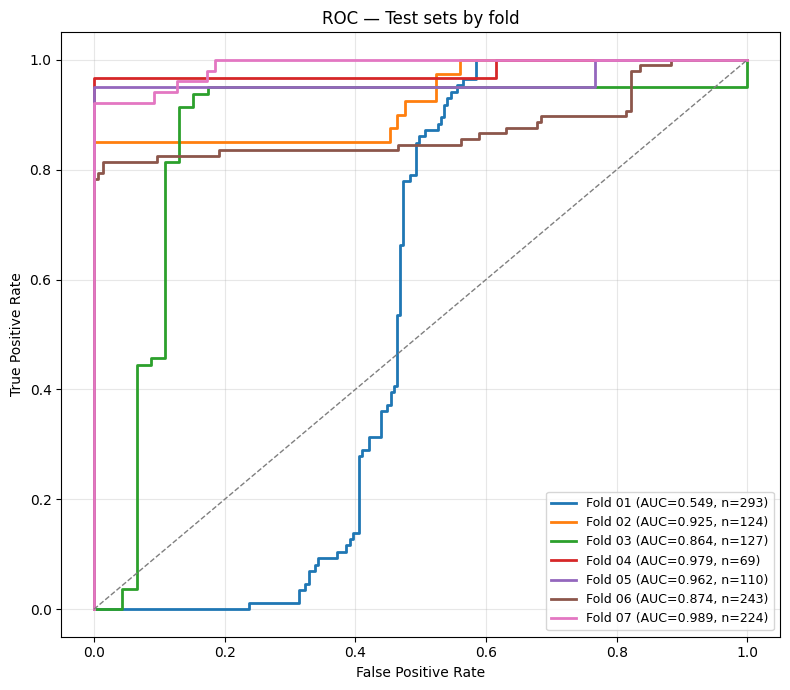

Saved combined ROC plot to: /content/drive/MyDrive/CD/2Bio_SHAP/roc_curves_all_folds.png


In [8]:
# === Load per-fold weights & test sets, plot ROC with AUC for each fold ===
# Assumes these are already defined from your training script:
#   save_dir, K_FOLDS, BATCH_SIZE, ImageSequence, label_for_file
#   (and all data-loading helpers/ID_TO_FEAT used by ImageSequence)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow import keras

save_dir = '/content/drive/MyDrive/CD/2Bio_SHAP/'
K_FOLDS          = 7
BATCH_SIZE =3

auc_rows = []
roc_data = []  # list of (fold_idx, fpr, tpr, auc, n)

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = Path(save_dir) / f"fold_{fold_idx:02d}"
    weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list = fold_dir / "test_files.txt"

    if not weights_file.exists() or not test_list.exists():
        print(f"(Fold {fold_idx:02d}) Missing weights or test_files.txt; skipping.")
        continue

    # Load test file paths
    test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    # Eval generator (no shuffle, no noise)
    test_gen = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)

    # Load model and predict
    model = keras.models.load_model(str(weights_file))
    probs = model.predict(test_gen, verbose=0).ravel().astype(float)
    y_true = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    if len(np.unique(y_true)) < 2:
        print(f"(Fold {fold_idx:02d}) Only one class present; ROC/AUC undefined.")
        auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": np.nan})
        continue

    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val = roc_auc_score(y_true, probs)

    auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": float(auc_val)})
    roc_data.append((fold_idx, fpr, tpr, auc_val, len(y_true)))
    print(f"Fold {fold_idx:02d} | TEST AUC = {auc_val:.4f} | n={len(y_true)}")

# Save AUCs table
if auc_rows:
    auc_df = pd.DataFrame(auc_rows).sort_values("fold")
    #auc_df.to_csv(Path(save_dir) / "auc_by_fold.csv", index=False)

# Plot all ROC curves in one figure with AUC in legend
if roc_data:
    plt.figure(figsize=(8, 7))
    for fold_idx, fpr, tpr, auc_val, n in roc_data:
        plt.plot(fpr, tpr, linewidth=2, label=f"Fold {fold_idx:02d} (AUC={auc_val:.3f}, n={n})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC — Test sets by fold")
    plt.legend(loc="lower right", fontsize=9, frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out_png = Path(save_dir) / "roc_curves_all_folds.png"
    #plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved combined ROC plot to: {out_png}")
else:
    print("No ROC data plotted (no valid folds).")


In [9]:
auc_rows

[{'fold': 1, 'n': 293, 'auc': 0.5488147399168632},
 {'fold': 2, 'n': 124, 'auc': 0.925},
 {'fold': 3, 'n': 127, 'auc': 0.863660762211487},
 {'fold': 4, 'n': 69, 'auc': 0.9794871794871794},
 {'fold': 5, 'n': 110, 'auc': 0.9616666666666666},
 {'fold': 6, 'n': 243, 'auc': 0.8740290919361671},
 {'fold': 7, 'n': 224, 'auc': 0.9886659866258642}]

In [10]:
roc_data

[(1,
  array([0.        , 0.00483092, 0.23671498, 0.23671498, 0.31400966,
         0.31400966, 0.3236715 , 0.3236715 , 0.32850242, 0.32850242,
         0.33816425, 0.33816425, 0.34299517, 0.34299517, 0.37198068,
         0.37198068, 0.38647343, 0.38647343, 0.39130435, 0.39130435,
         0.39613527, 0.39613527, 0.4057971 , 0.4057971 , 0.41062802,
         0.41062802, 0.42028986, 0.42028986, 0.43961353, 0.43961353,
         0.44927536, 0.44927536, 0.45410628, 0.45410628, 0.4589372 ,
         0.4589372 , 0.46376812, 0.46376812, 0.46859903, 0.46859903,
         0.47342995, 0.47342995, 0.48309179, 0.48309179, 0.49275362,
         0.49275362, 0.49758454, 0.49758454, 0.50724638, 0.50724638,
         0.52657005, 0.52657005, 0.53140097, 0.53140097, 0.53623188,
         0.53623188, 0.5410628 , 0.5410628 , 0.54589372, 0.54589372,
         0.55555556, 0.55555556, 0.56521739, 0.56521739, 0.58454106,
         0.58454106, 1.        ]),
  array([0.        , 0.        , 0.        , 0.01162791, 0.0116

### SHAP importance

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

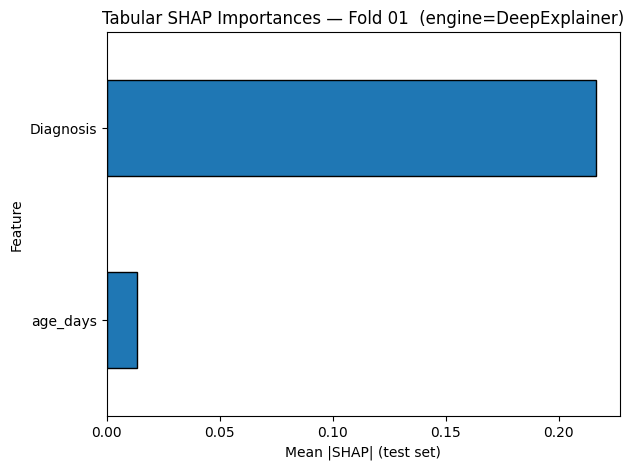

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

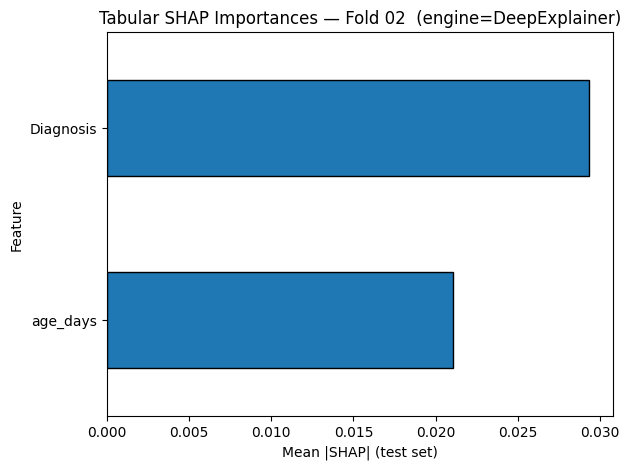

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

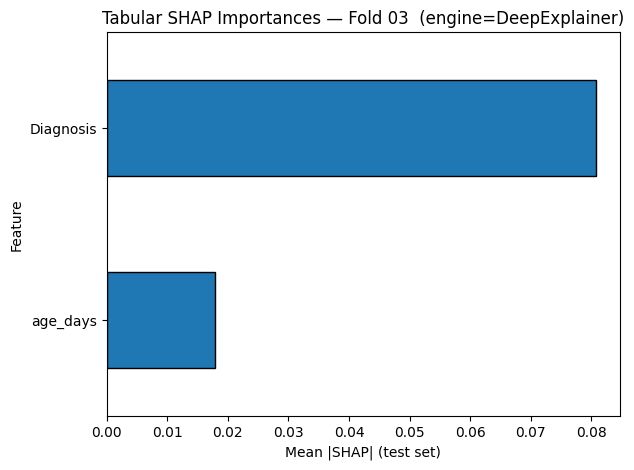

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

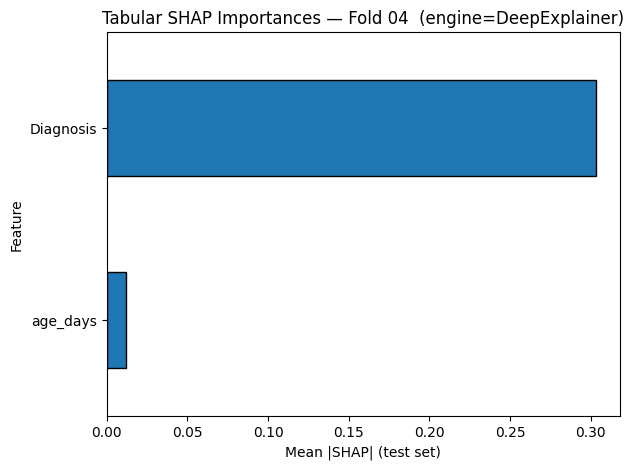

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

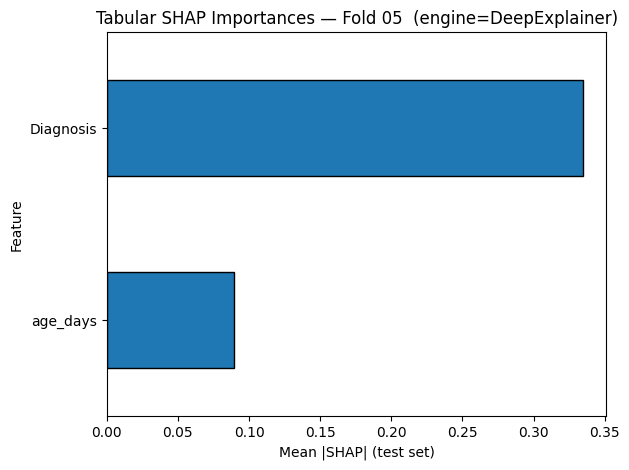

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

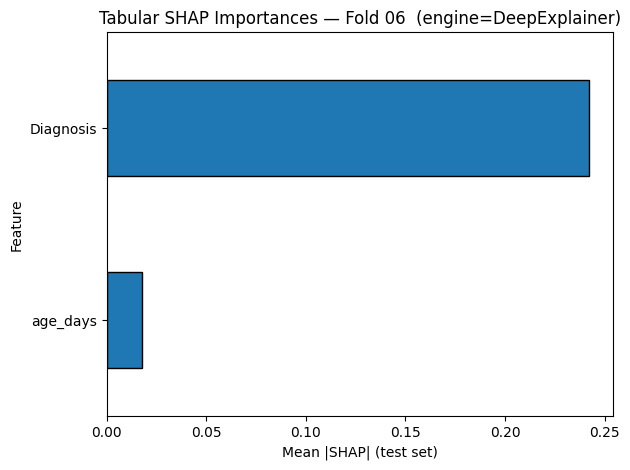

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

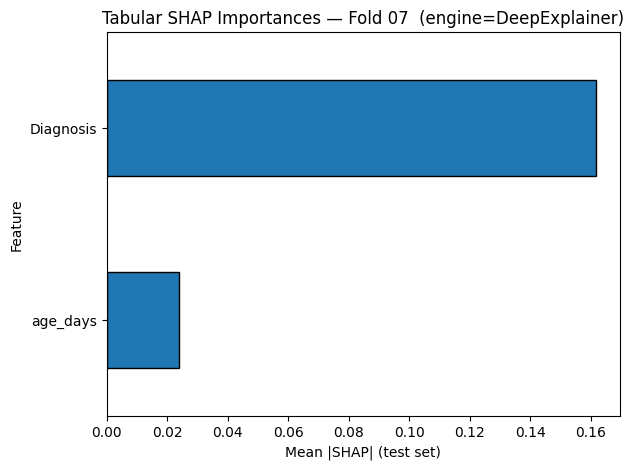


=== Tabular SHAP mean(|value|) by feature and fold ===
            fold_01   fold_02   fold_03   fold_04   fold_05   fold_06   fold_07  mean_over_folds
Diagnosis  0.216351  0.029350  0.080711  0.303022  0.334537  0.242145  0.161613         0.195390
age_days   0.013336  0.021049  0.017803  0.011658  0.089578  0.017861  0.023760         0.027864


In [11]:
# === SHAP feature importances (tabular features) per fold on each fold's TEST set ===
# Assumes these are already defined in your session:
#   save_dir, K_FOLDS, BATCH_SIZE
#   FEAT_COLS, FEAT_DIM, TARGET_H_DEDUP, TARGET_W
#   ID_TO_FEAT, load_csv_as_image_cached, patient_num_from_path, label_for_file
# And for each fold directory:
#   .../fold_XX/best_fold_XX.h5
#   .../fold_XX/train_files.txt, .../fold_XX/test_files.txt, (optional) .../fold_XX/val_files.txt
#
# This script:
#   • Computes SHAP values for the *tabular* input on each fold’s TEST set
#   • Plots a bar chart of mean |SHAP| per feature for each fold (NO saving of plots)
#   • Collects per-fold importances into `fold_importances` (a list of Series)
#   • Prints a cross-fold table `imp_table` (features x folds) and a mean-over-folds row

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

# Ensure SHAP is available
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# -------- tweakables --------
BACKGROUND_N = 32     # number of background samples (from train+val) to fit explainer
SHAP_BATCH   = 16     # SHAP computation batch size
TOP_K        = 20     # max features to display in each bar plot
# ---------------------------

rng = np.random.default_rng(1)
save_dir_path = Path(save_dir)

def _build_arrays(file_list):
    """Construct (X_img, X_tab, y) arrays for a list of CSV Paths."""
    n = len(file_list)
    X_img = np.empty((n, TARGET_H_DEDUP, TARGET_W, 1), dtype=np.float32)
    X_tab = np.empty((n, FEAT_DIM), dtype=np.float32)
    y     = np.empty((n,), dtype=np.int32)
    for i, f in enumerate(file_list):
        xi = load_csv_as_image_cached(f)
        if xi.ndim == 2:
            xi = xi[..., None]
        if xi.shape != (TARGET_H_DEDUP, TARGET_W, 1):
            raise ValueError(f"Bad EEG shape {xi.shape} for {f}")
        X_img[i] = xi
        pid = patient_num_from_path(f)
        X_tab[i] = ID_TO_FEAT[pid]
        y[i] = label_for_file(f)
    return X_img, X_tab, y

def _get_bg_files(train_files, val_files, k=BACKGROUND_N):
    """Pick up to k files from train+val as SHAP background."""
    pool = list(train_files) + list(val_files)
    if len(pool) == 0:
        pool = list(train_files)
    if len(pool) == 0:
        raise RuntimeError("No background data: train+val empty for this fold.")
    k = min(k, len(pool))
    idx = rng.choice(len(pool), size=k, replace=False)
    return [pool[i] for i in idx]

def _extract_tab_shap_2d(shap_vals, feat_dim_expected=None):
    """
    Return a (N, D) numpy array of SHAP values for the *tabular* input (2nd model input).
    Handles nesting and odd shapes like (1, N, D), (C, N, D), or (N, D, 1).
    """
    sv = shap_vals
    # Unwrap one level if SHAP returns [[sv_img, sv_tab]]
    if isinstance(sv, list) and len(sv) > 0 and isinstance(sv[0], list):
        sv = sv[0]

    # Tabular component is index 1 (since inputs=[eeg_input, tab_input])
    sv_tab = np.asarray(sv[1])

    # Normalize to (N, D)
    if sv_tab.ndim == 3:
        if sv_tab.shape[0] == 1:         # (1, N, D)
            sv_tab = sv_tab[0]
        elif sv_tab.shape[-1] == 1:      # (N, D, 1)
            sv_tab = sv_tab[..., 0]
        else:                            # (C, N, D) -> average across outputs/classes
            sv_tab = sv_tab.mean(axis=0)
    elif sv_tab.ndim == 1:
        sv_tab = sv_tab.reshape(1, -1)   # (D,) -> (1, D)

    # If axes swapped (D, N), transpose
    if sv_tab.ndim == 2 and feat_dim_expected is not None and sv_tab.shape[0] == feat_dim_expected and sv_tab.shape[1] != feat_dim_expected:
        sv_tab = sv_tab.T

    if sv_tab.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape for tabular input: {sv_tab.shape}")

    if (feat_dim_expected is not None) and (sv_tab.shape[1] != feat_dim_expected):
        raise ValueError(f"SHAP D={sv_tab.shape[1]} != FEAT_DIM={feat_dim_expected}")

    return sv_tab

def _compute_tab_shap_in_batches(explainer, X_img, X_tab, batch=SHAP_BATCH):
    """Compute SHAP for the tabular input over (X_img, X_tab) in batches; returns (N, D)."""
    parts = []
    for i in range(0, X_tab.shape[0], batch):
        x_img_b = X_img[i:i+batch]
        x_tab_b = X_tab[i:i+batch]
        sv = explainer.shap_values([x_img_b, x_tab_b], check_additivity=False)
        shap_tab_b = _extract_tab_shap_2d(sv, feat_dim_expected=len(FEAT_COLS))
        parts.append(shap_tab_b)
    return np.concatenate(parts, axis=0)

# ---- Collect per-fold importances here ----
fold_importances = []  # list[pd.Series], index=FEAT_COLS, name=f"fold_XX"

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir    = save_dir_path / f"fold_{fold_idx:02d}"
    weights_fp  = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list   = fold_dir / "test_files.txt"
    train_list  = fold_dir / "train_files.txt"
    val_list    = fold_dir / "val_files.txt"

    if not weights_fp.exists() or not test_list.exists() or not train_list.exists():
        print(f"(Fold {fold_idx:02d}) Missing weights/test/train lists; skipping SHAP.")
        continue

    # Load file lists
    test_files  = [Path(x) for x in test_list.read_text().splitlines()  if x.strip()]
    train_files = [Path(x) for x in train_list.read_text().splitlines() if x.strip()]
    val_files   = [Path(x) for x in (val_list.read_text().splitlines() if val_list.exists() else []) if x.strip()]

    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping SHAP.")
        continue

    # Build arrays
    X_img_test, X_tab_test, y_true = _build_arrays(test_files)
    bg_files = _get_bg_files(train_files, val_files, k=BACKGROUND_N)
    X_img_bg, X_tab_bg, _ = _build_arrays(bg_files)

    # Load model
    model = keras.models.load_model(str(weights_fp))

    # Explainer: Deep -> Gradient -> generic
    try:
        explainer = shap.DeepExplainer(model, [X_img_bg, X_tab_bg])
        _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
        engine = "DeepExplainer"
    except Exception as e:
        print(f"(Fold {fold_idx:02d}) DeepExplainer failed ({e}); trying GradientExplainer.")
        try:
            explainer = shap.GradientExplainer(model, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            engine = "GradientExplainer"
        except Exception as e2:
            print(f"(Fold {fold_idx:02d}) GradientExplainer failed ({e2}); trying generic Explainer.")
            try:
                explainer = shap.Explainer(model, masker=[X_img_bg, X_tab_bg])
                _ = explainer([X_img_test[:1], X_tab_test[:1]])
                engine = "Explainer"
            except Exception as e3:
                print(f"(Fold {fold_idx:02d}) All SHAP explainers failed ({e3}); skipping.")
                continue

    # Compute SHAP for tabular on TEST -> (N, D)
    if engine == "Explainer":
        exp = explainer([X_img_test, X_tab_test])
        shap_tab = _extract_tab_shap_2d([exp.values[0], exp.values[1]], feat_dim_expected=len(FEAT_COLS))
    else:
        shap_tab = _compute_tab_shap_in_batches(explainer, X_img_test, X_tab_test, batch=SHAP_BATCH)

    # Mean |SHAP| per feature -> 1-D
    mean_abs = np.mean(np.abs(shap_tab), axis=0).ravel()
    imp_df = (
        pd.DataFrame({"feature": FEAT_COLS, "mean_abs_shap": mean_abs})
          .sort_values("mean_abs_shap", ascending=False)
    )

    # --- collect for later ---
    fold_importances.append(pd.Series(mean_abs, index=FEAT_COLS, name=f"fold_{fold_idx:02d}"))

    # --- plot (DO NOT SAVE) ---
    top_k = min(TOP_K, len(FEAT_COLS))
    plt.figure(figsize=(8, 6))
    imp_df.head(top_k)[::-1].plot(
        kind="barh", x="feature", y="mean_abs_shap",
        legend=False, edgecolor="black"
    )
    plt.xlabel("Mean |SHAP| (test set)")
    plt.ylabel("Feature")
    plt.title(f"Tabular SHAP Importances — Fold {fold_idx:02d}  (engine={engine})")
    plt.tight_layout()
    plt.show()

# ---- Cross-fold summary in-memory (no file saving) ----
if fold_importances:
    imp_table = pd.concat(fold_importances, axis=1)           # rows=features, cols=fold_XX
    imp_table["mean_over_folds"] = imp_table.mean(axis=1)
    print("\n=== Tabular SHAP mean(|value|) by feature and fold ===")
    print(imp_table.sort_values("mean_over_folds", ascending=False).to_string())
else:
    print("\nNo SHAP importances computed (no valid folds).")


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


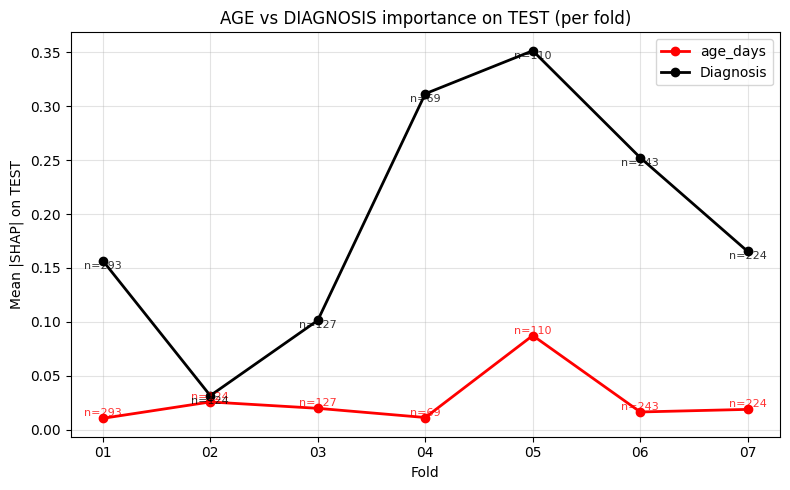

{'feature_indices': {'AGE': 0,
                     'AGE_label': 'age_days',
                     'DIAGNOSIS': 1,
                     'DIAGNOSIS_label': 'Diagnosis'},
 'overall_weighted_mean': {'Diagnosis': 0.1859539715354057,
                           'age_days': 0.0229839035588982,
                           'total_test_samples': 1190},
 'per_fold': {'fold_01': {'Diagnosis': 0.15684444373378167,
                          'age_days': 0.010485156800807692,
                          'engine': 'DeepExplainer',
                          'n_test': 293},
              'fold_02': {'Diagnosis': 0.03155583662596802,
                          'age_days': 0.025698218641111686,
                          'engine': 'DeepExplainer',
                          'n_test': 124},
              'fold_03': {'Diagnosis': 0.10140363308857744,
                          'age_days': 0.01977900205011384,
                          'engine': 'DeepExplainer',
                          'n_test': 127},
             

In [12]:
# ========= AGE & DIAGNOSIS importance over TEST sets only =========
# This block assumes:
# - You are inside the same session where FEAT_COLS exists
# - You will run it alongside (or after) your per-fold SHAP loop
# - We'll recompute (or read) shap_tab inside the loop to build per-fold values

# 1) Find indices for AGE and DIAGNOSIS in FEAT_COLS (case-insensitive; exact match preferred)
feat_lower = [c.lower() for c in FEAT_COLS]

def _find_feature_idx(name):
    nl = name.lower()
    # exact case-insensitive match first
    if nl in feat_lower:
        return feat_lower.index(nl), FEAT_COLS[feat_lower.index(nl)]
    # otherwise try substring match (robust to e.g., "AGE_YEARS", "diagnosis_code")
    cand = [i for i, c in enumerate(feat_lower) if nl in c]
    if len(cand) == 1:
        return cand[0], FEAT_COLS[cand[0]]
    elif len(cand) > 1:
        # if multiple, take the shortest FEAT_COLS name as the most “exact”
        best = min(cand, key=lambda i: len(FEAT_COLS[i]))
        return best, FEAT_COLS[best]
    raise ValueError(f"Feature '{name}' not found in FEAT_COLS={FEAT_COLS}")

idx_age, AGE_LABEL = _find_feature_idx("age")
idx_dx,  DX_LABEL  = _find_feature_idx("diagnosis")

# 2) Collect per-fold results (we recompute quickly from your loop inputs)
age_dx_results = {"per_fold": {}, "overall_weighted_mean": {}, "feature_indices": {
    "AGE": idx_age, "DIAGNOSIS": idx_dx, "AGE_label": AGE_LABEL, "DIAGNOSIS_label": DX_LABEL
}}

# For overall weighted mean across all TEST samples from all folds
sum_abs_overall = np.zeros(len(FEAT_COLS), dtype=float)
n_test_overall  = 0

age_vals, dx_vals, fold_ids, ns = [], [], [], []

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir    = save_dir_path / f"fold_{fold_idx:02d}"
    weights_fp  = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list   = fold_dir / "test_files.txt"
    train_list  = fold_dir / "train_files.txt"
    val_list    = fold_dir / "val_files.txt"

    if not (weights_fp.exists() and test_list.exists() and train_list.exists()):
        print(f"(Fold {fold_idx:02d}) Missing weights/test/train lists; skipping.")
        continue

    # Load file paths
    test_files  = [Path(x) for x in test_list.read_text().splitlines()  if x.strip()]
    train_files = [Path(x) for x in train_list.read_text().splitlines() if x.strip()]
    val_files   = [Path(x) for x in (val_list.read_text().splitlines() if val_list.exists() else []) if x.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    # Build arrays
    X_img_test, X_tab_test, _ = _build_arrays(test_files)
    bg_files = _get_bg_files(train_files, val_files, k=BACKGROUND_N)
    X_img_bg,  X_tab_bg,  _ = _build_arrays(bg_files)

    # Load model and explainer
    model = keras.models.load_model(str(weights_fp))
    try:
        explainer = shap.DeepExplainer(model, [X_img_bg, X_tab_bg])
        _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
        engine = "DeepExplainer"
    except Exception:
        try:
            explainer = shap.GradientExplainer(model, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            engine = "GradientExplainer"
        except Exception:
            explainer = shap.Explainer(model, masker=[X_img_bg, X_tab_bg])
            _ = explainer([X_img_test[:1], X_tab_test[:1]])
            engine = "Explainer"

    # Compute SHAP for tabular on TEST -> (N, D)
    if engine == "Explainer":
        exp = explainer([X_img_test, X_tab_test])  # Explanation object
        shap_tab = _extract_tab_shap_2d([exp.values[0], exp.values[1]], feat_dim_expected=len(FEAT_COLS))
    else:
        shap_tab = _compute_tab_shap_in_batches(explainer, X_img_test, X_tab_test, batch=SHAP_BATCH)

    # Mean |SHAP| per feature for THIS fold’s TEST set
    mean_abs = np.mean(np.abs(shap_tab), axis=0)  # (D,)

    # Also accumulate sums to make an overall (weighted by #test samples) mean later
    sum_abs_overall += np.sum(np.abs(shap_tab), axis=0)  # (D,)
    n_test_overall  += shap_tab.shape[0]

    # Pull just AGE & DIAGNOSIS
    age_imp = float(mean_abs[idx_age])
    dx_imp  = float(mean_abs[idx_dx])

    # Save per-fold values
    age_dx_results["per_fold"][f"fold_{fold_idx:02d}"] = {
        "n_test": int(shap_tab.shape[0]),
        AGE_LABEL: age_imp,
        DX_LABEL: dx_imp,
        "engine": engine,
    }

    # Collect for plotting
    fold_ids.append(fold_idx)
    age_vals.append(age_imp)
    dx_vals.append(dx_imp)
    ns.append(int(shap_tab.shape[0]))

# 3) Overall weighted mean across all TEST samples (all folds combined)
if n_test_overall > 0:
    overall_mean = (sum_abs_overall / n_test_overall)
    age_dx_results["overall_weighted_mean"] = {
        AGE_LABEL: float(overall_mean[idx_age]),
        DX_LABEL:  float(overall_mean[idx_dx]),
        "total_test_samples": int(n_test_overall)
    }
else:
    print("No test samples found across folds; overall mean not computed.")

# 4) Plot across folds: red = AGE, black = DIAGNOSIS
if fold_ids:
    plt.figure(figsize=(8, 5))
    plt.plot(fold_ids, age_vals, marker='o', linewidth=2, color='red',   label=AGE_LABEL)
    plt.plot(fold_ids, dx_vals,  marker='o', linewidth=2, color='black', label=DX_LABEL)
    for x, (a, d, n) in enumerate(zip(age_vals, dx_vals, ns), start=min(fold_ids)):
        plt.text(x, a, f"n={n}", fontsize=8, ha='center', va='bottom', color='red',   alpha=0.8)
        plt.text(x, d, f"n={n}", fontsize=8, ha='center', va='top',    color='black', alpha=0.8)

    plt.xticks(fold_ids, [f"{f:02d}" for f in fold_ids])
    plt.xlabel("Fold")
    plt.ylabel("Mean |SHAP| on TEST")
    plt.title(f"AGE vs DIAGNOSIS importance on TEST (per fold)")
    plt.grid(True, alpha=0.35)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
else:
    print("No folds plotted.")

# 5) Your dictionary with values (per-fold + overall) is in:
#    `age_dx_results`
# Example of quick view:
import pprint
pprint.pprint(age_dx_results)


In [13]:
age_dx_results

{'per_fold': {'fold_01': {'n_test': 293,
   'age_days': 0.010485156800807692,
   'Diagnosis': 0.15684444373378167,
   'engine': 'DeepExplainer'},
  'fold_02': {'n_test': 124,
   'age_days': 0.025698218641111686,
   'Diagnosis': 0.03155583662596802,
   'engine': 'DeepExplainer'},
  'fold_03': {'n_test': 127,
   'age_days': 0.01977900205011384,
   'Diagnosis': 0.10140363308857744,
   'engine': 'DeepExplainer'},
  'fold_04': {'n_test': 69,
   'age_days': 0.01124696822270103,
   'Diagnosis': 0.3117125494324643,
   'engine': 'DeepExplainer'},
  'fold_05': {'n_test': 110,
   'age_days': 0.08733892633092843,
   'Diagnosis': 0.351625051417134,
   'engine': 'DeepExplainer'},
  'fold_06': {'n_test': 243,
   'age_days': 0.0163998676881371,
   'Diagnosis': 0.2523483141888807,
   'engine': 'DeepExplainer'},
  'fold_07': {'n_test': 224,
   'age_days': 0.01880219360983964,
   'Diagnosis': 0.1653172189939401,
   'engine': 'DeepExplainer'}},
 'overall_weighted_mean': {'age_days': 0.0229839035588982,
  

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


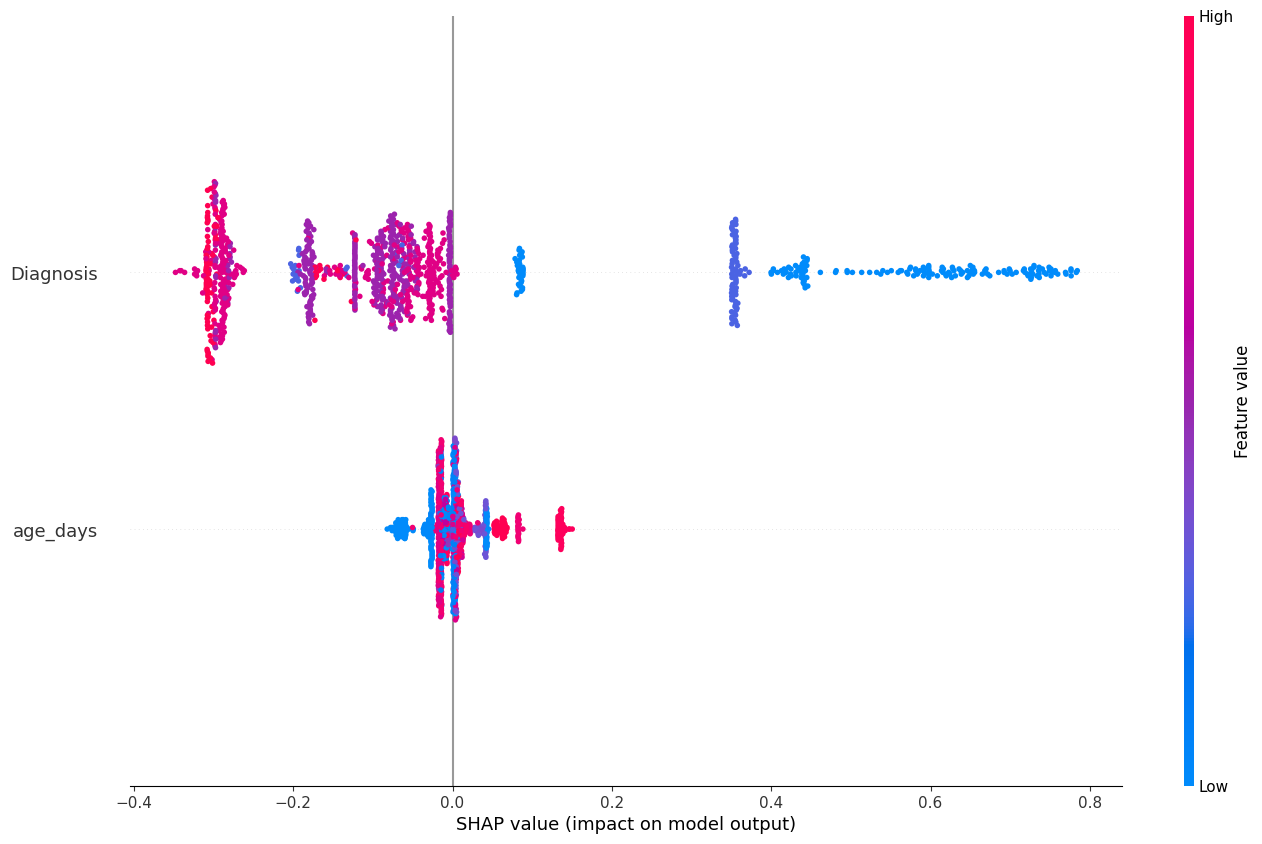

In [15]:
# ===== Beeswarm for AGE & DIAGNOSIS (robust to SHAP return shapes) =====
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow import keras
import shap

# ---------- 0) find feature indices ----------
feat_lower = [c.lower() for c in FEAT_COLS]

def _find_feature_idx(name: str):
    nl = name.lower()
    if nl in feat_lower:  # exact
        i = feat_lower.index(nl)
        return i, FEAT_COLS[i]
    cand = [i for i, c in enumerate(feat_lower) if nl in c]
    if len(cand) == 1:
        return cand[0], FEAT_COLS[cand[0]]
    if len(cand) > 1:
        i = min(cand, key=lambda j: len(FEAT_COLS[j]))  # shortest name
        return i, FEAT_COLS[i]
    raise ValueError(f"Feature '{name}' not found in FEAT_COLS.")

idx_age, AGE_LABEL = _find_feature_idx("age")
idx_dx,  DX_LABEL  = _find_feature_idx("diagnosis")

# ---------- 1) helpers to extract TABULAR SHAP ----------
def _iter_ndarrays(obj):
    if isinstance(obj, np.ndarray):
        yield obj
    elif isinstance(obj, (list, tuple)):
        for x in obj:
            yield from _iter_ndarrays(x)

def _find_tab_shap_array(vals_obj, N_expected, D_expected):
    """
    Find and reshape a numpy array within `vals_obj` that corresponds to the
    tabular SHAP values with shape (N, D).
    Accepts variants like (N,D), (C,N,D), (N,D,C), or any array containing
    axes with sizes N and D (we'll transpose/reshape accordingly).
    """
    shapes_seen = []
    # exact matches first
    for a in _iter_ndarrays(vals_obj):
        shapes_seen.append(a.shape)
        if a.ndim == 2 and a.shape == (N_expected, D_expected):
            return a
    # class-first/last 3D variants
    for a in _iter_ndarrays(vals_obj):
        if a.ndim == 3:
            # (C, N, D)
            if a.shape[1] == N_expected and a.shape[2] == D_expected:
                cidx = int(np.argmax(np.mean(np.abs(a), axis=(1,2))))
                return a[cidx]
            # (N, D, C)
            if a.shape[0] == N_expected and a.shape[1] == D_expected:
                # pick first class/channel
                return a[..., 0]
    # general fallback: find array containing both N and D as axes
    for a in _iter_ndarrays(vals_obj):
        if N_expected in a.shape and D_expected in a.shape and a.ndim <= 4:
            n_ax = a.shape.index(N_expected)
            d_ax = a.shape.index(D_expected)
            axes = list(range(a.ndim))
            # move N to axis0, D to last
            tmp = np.transpose(a, [n_ax] + [k for k in axes if k not in (n_ax, d_ax)] + [d_ax])
            return tmp.reshape(N_expected, D_expected)
    raise ValueError(f"Could not locate tabular SHAP array. Saw shapes: {shapes_seen}")

def _extract_age_dx_from_explanation(exp, feat_cols, idx_age, idx_dx):
    """
    Handle shap.Explainer outputs that return a single flattened Explanation:
      exp.values shape (N, F_total), exp.data shape (N, F_total), with
      exp.feature_names as a flat list or list-of-lists.
    Returns (vals_2col, data_2col) for AGE & DX (N, 2).
    """
    fn = exp.feature_names
    # flatten feature_names if nested
    if isinstance(fn[0], list):
        flat_names = [n for sub in fn for n in sub]
    else:
        flat_names = fn

    age_name = feat_cols[idx_age]
    dx_name  = feat_cols[idx_dx]

    def _find_idx_by_label(lbl):
        # exact → case-insensitive → substring
        for eq in (lambda n: n == lbl,
                   lambda n: n.lower() == lbl.lower(),
                   lambda n: lbl.lower() in n.lower()):
            hits = [i for i, n in enumerate(flat_names) if eq(n)]
            if hits:
                return hits[0]
        raise ValueError(f"Feature '{lbl}' not found in Explanation.feature_names")

    ia = _find_idx_by_label(age_name)
    idd = _find_idx_by_label(dx_name)
    vals_2 = exp.values[:, [ia, idd]]
    data_2 = exp.data[:,  [ia, idd]]
    return vals_2, data_2

# ---------- 2) collectors across folds ----------
all_age_shap, all_dx_shap = [], []
all_age_val,  all_dx_val  = [], []
fold_ids_used = []

# ---------- 3) loop folds ----------
for fold_idx in range(1, K_FOLDS + 1):
    fold_dir    = Path(save_dir_path) / f"fold_{fold_idx:02d}"
    weights_fp  = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list   = fold_dir / "test_files.txt"
    train_list  = fold_dir / "train_files.txt"
    val_list    = fold_dir / "val_files.txt"

    if not (weights_fp.exists() and test_list.exists() and train_list.exists()):
        print(f"(Fold {fold_idx:02d}) Missing weights/test/train lists; skipping.")
        continue

    test_files  = [Path(x) for x in test_list.read_text().splitlines()  if x.strip()]
    train_files = [Path(x) for x in train_list.read_text().splitlines() if x.strip()]
    val_files   = [Path(x) for x in (val_list.read_text().splitlines() if val_list.exists() else []) if x.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    X_img_test, X_tab_test, _ = _build_arrays(test_files)
    bg_files = _get_bg_files(train_files, val_files, k=BACKGROUND_N)
    X_img_bg,  X_tab_bg,  _ = _build_arrays(bg_files)

    model = keras.models.load_model(str(weights_fp))
    N, D = X_tab_test.shape

    # Prefer GradientExplainer (works well with TF 2.x in eager), then Explainer, then Deep
    engine = None
    try:
        explainer = shap.GradientExplainer(model, data=[X_img_bg, X_tab_bg])
        vals_obj = explainer.shap_values([X_img_test, X_tab_test], check_additivity=False)
        engine = "GradientExplainer"
    except Exception:
        try:
            explainer = shap.Explainer(model, masker=[X_img_bg, X_tab_bg])
            exp = explainer([X_img_test, X_tab_test])  # shap.Explanation
            engine = "Explainer"
        except Exception:
            explainer = shap.DeepExplainer(model, [X_img_bg, X_tab_bg])
            vals_obj = explainer.shap_values([X_img_test, X_tab_test], check_additivity=False)
            engine = "DeepExplainer"

    if engine == "Explainer":
        # Flattened Explanation or list-per-input; handle both
        if isinstance(exp.values, list):
            # list-per-input: take the tabular part directly
            tab_vals = exp.values[1]  # (N, D)
            tab_data = exp.data[1]    # (N, D)
            age_shap = tab_vals[:, idx_age]
            dx_shap  = tab_vals[:, idx_dx]
            age_val  = tab_data[:, idx_age]
            dx_val   = tab_data[:, idx_dx]
        else:
            # flattened (N, F_total) — slice two columns by name
            two_vals, two_data = _extract_age_dx_from_explanation(exp, FEAT_COLS, idx_age, idx_dx)
            age_shap, dx_shap = two_vals[:, 0], two_vals[:, 1]
            age_val,  dx_val  = two_data[:, 0], two_data[:, 1]
    else:
        # Gradient/Deep: find the tabular array among returned structures
        tab_shap = _find_tab_shap_array(vals_obj, N_expected=N, D_expected=D)  # (N, D)
        age_shap = tab_shap[:, idx_age]
        dx_shap  = tab_shap[:, idx_dx]
        age_val  = X_tab_test[:, idx_age]
        dx_val   = X_tab_test[:, idx_dx]

    all_age_shap.append(np.asarray(age_shap))
    all_dx_shap.append(np.asarray(dx_shap))
    all_age_val.append(np.asarray(age_val))
    all_dx_val.append(np.asarray(dx_val))
    fold_ids_used.append(fold_idx)

if not all_age_shap:
    raise RuntimeError("No SHAP values collected for AGE/DIAGNOSIS.")

# ---------- 4) build 2-feature Explanation and beeswarm ----------
S_age = np.concatenate(all_age_shap, axis=0)
S_dx  = np.concatenate(all_dx_shap,  axis=0)
V_age = np.concatenate(all_age_val,  axis=0)
V_dx  = np.concatenate(all_dx_val,   axis=0)

exp2 = shap.Explanation(
    values=np.column_stack([S_age, S_dx]),   # (N_total, 2)
    data=np.column_stack([V_age, V_dx]),     # (N_total, 2) for color
    feature_names=[AGE_LABEL, DX_LABEL]
)

# Beeswarm (two rows, colored by feature value)
shap.plots.beeswarm(exp2, max_display=2, color_bar=True, show=True,  plot_size=(16, 10))

# (optional) save
# shap.plots.beeswarm(exp2, max_display=2, color_bar=True, show=False)
# plt.tight_layout(); plt.savefig("beeswarm_age_dx.png", dpi=200, bbox_inches="tight"); plt.show()


/tmp/ipython-input-1028919588.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


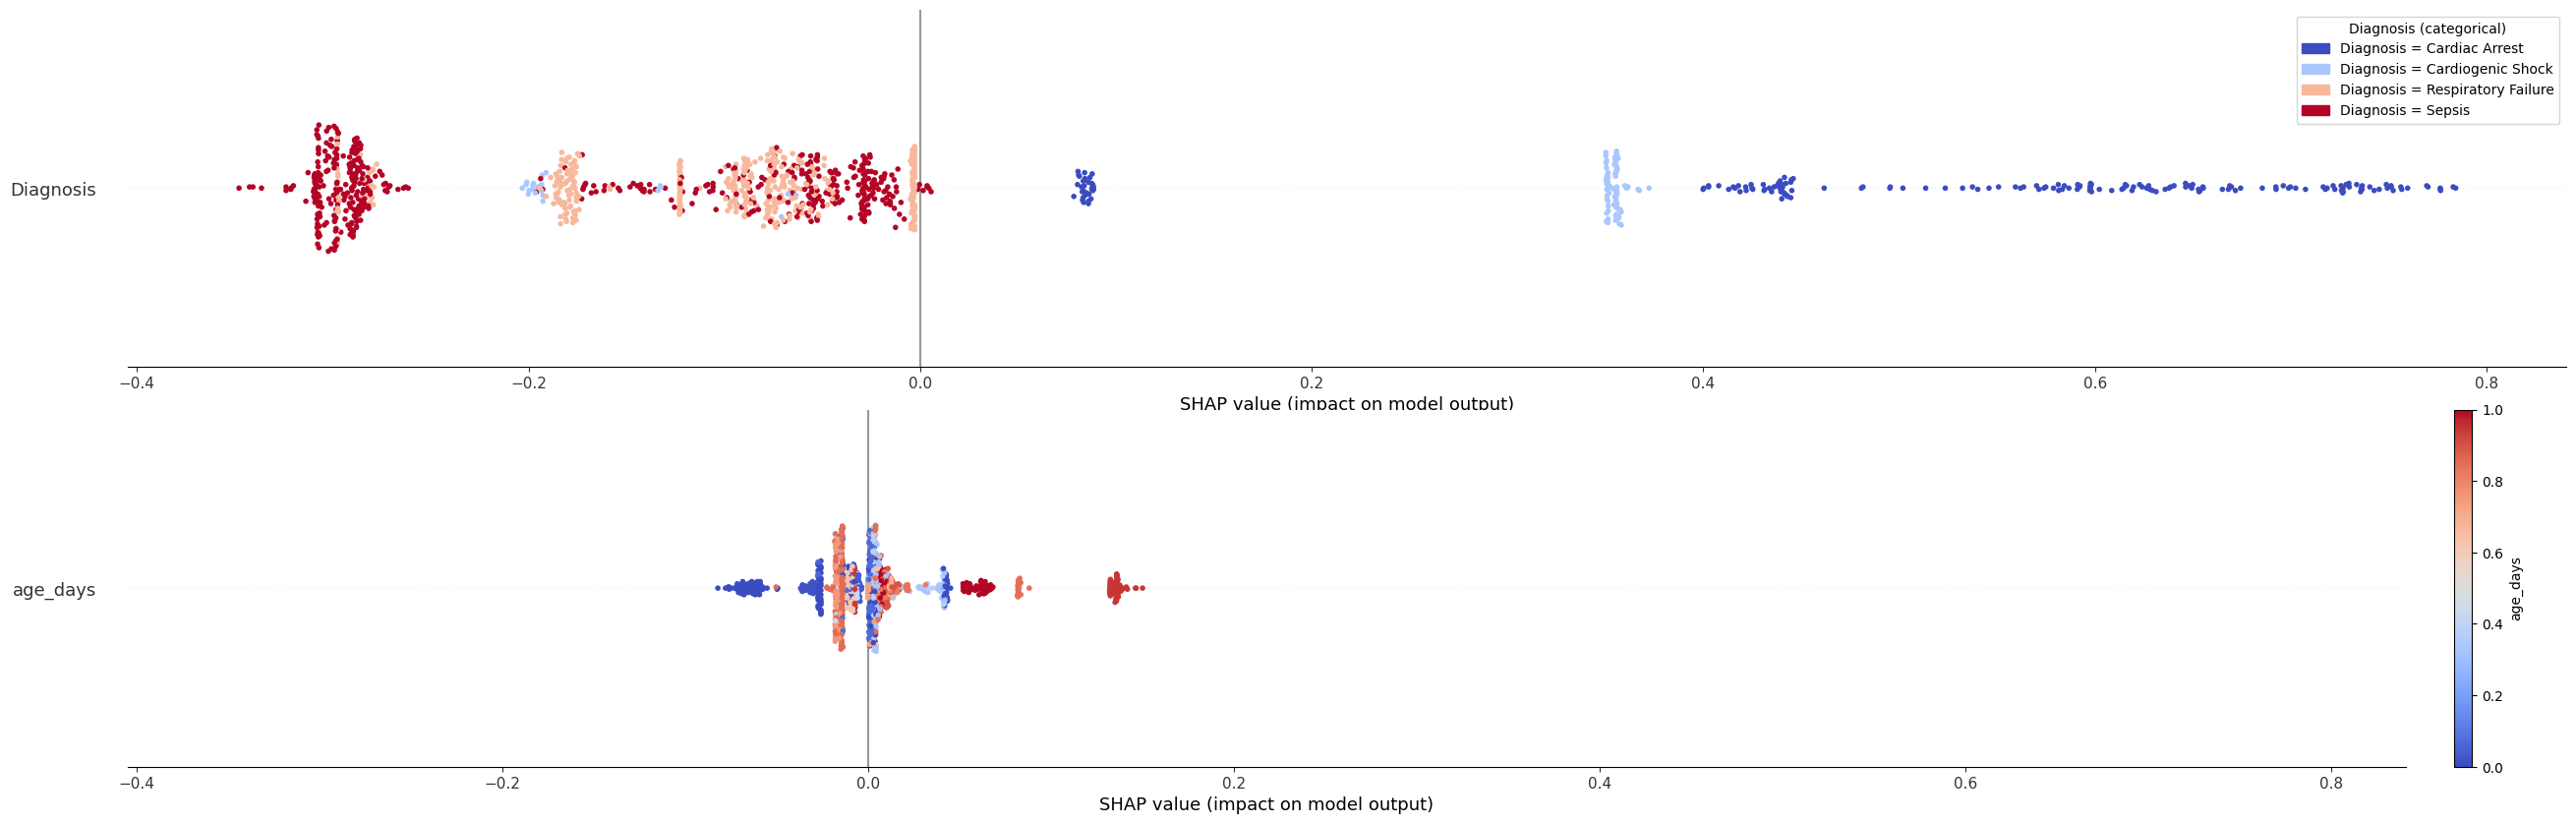

In [89]:
# --- Define Dx bins & labels, snap TEST Dx to {0,1,2,3}, build bins array ---
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt
import shap
W, H = 32, 20
# 1) Snap any float-like Dx to integer codes {0,1,2,3}
def to_0123(a):
    a = np.asarray(a).reshape(-1)
    choices = np.array([0., 1., 2., 3.])
    idx = np.argmin(np.abs(a[:, None] - choices[None, :]), axis=1)
    return choices[idx].astype(int)

V_dx_codes = to_0123(V_dx)  # V_dx = Diagnosis values for ALL test dots used in beeswarm

# 2) Discrete bins used only for coloring the Dx row
dx_bin_values  = {0: -1.5, 1: -0.5, 2: 0.5,  3: 1.5}  # four well-separated bins
dx_text_labels = {0: "Cardiac Arrest", 1: "Cardiogenic Shock",
                  2: "Respiratory Failure", 3: "Sepsis"}

V_dx_bins = np.array([dx_bin_values[c] for c in V_dx_codes], dtype=float)

# 3) Build one-feature Explanations for separate rows
age_col = exp2.feature_names.index(AGE_LABEL)
dx_col  = exp2.feature_names.index(DX_LABEL)

exp_dx  = shap.Explanation(values=exp2.values[:, [dx_col]],
                           data=V_dx_bins.reshape(-1, 1),
                           feature_names=[DX_LABEL])
exp_age = shap.Explanation(values=exp2.values[:, [age_col]],
                           data=V_age.reshape(-1, 1),
                           feature_names=[AGE_LABEL])

cmap     = plt.get_cmap("coolwarm")
dx_norm  = mcolors.Normalize(vmin=min(dx_bin_values.values()),
                             vmax=max(dx_bin_values.values()))
age_norm = mcolors.Normalize(vmin=np.nanmin(V_age), vmax=np.nanmax(V_age))

# Shared x-limits
x_min, x_max = float(np.min(exp2.values)), float(np.max(exp2.values))
pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
xlim = (x_min - pad, x_max + pad)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(W, H), sharex=True, gridspec_kw={'hspace': 0.12})

# --- Top: Diagnosis (categorical colors, discrete legend) ---
plt.sca(ax1)
shap.plots.beeswarm(exp_dx, max_display=1, color=cmap, color_bar=False, show=False, plot_size=(W, H/2))
ax1.set_xlim(*xlim)

legend_handles = [
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[0])), label=f"Diagnosis = {dx_text_labels[0]}"),
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[1])), label=f"Diagnosis = {dx_text_labels[1]}"),
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[2])), label=f"Diagnosis = {dx_text_labels[2]}"),
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[3])), label=f"Diagnosis = {dx_text_labels[3]}"),
]
ax1.legend(handles=legend_handles, title=f"{DX_LABEL} (categorical)", loc="upper right", frameon=True)

# --- Bottom: Age (continuous colorbar) ---
plt.sca(ax2)
shap.plots.beeswarm(exp_age, max_display=1, color=cmap, color_bar=False, show=False, plot_size=(W, H/2))
ax2.set_xlim(xlim)   # <-- only fix Age to ±0.8

sm = ScalarMappable(cmap=cmap, norm=age_norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label(AGE_LABEL)

ax2.set_xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.show()

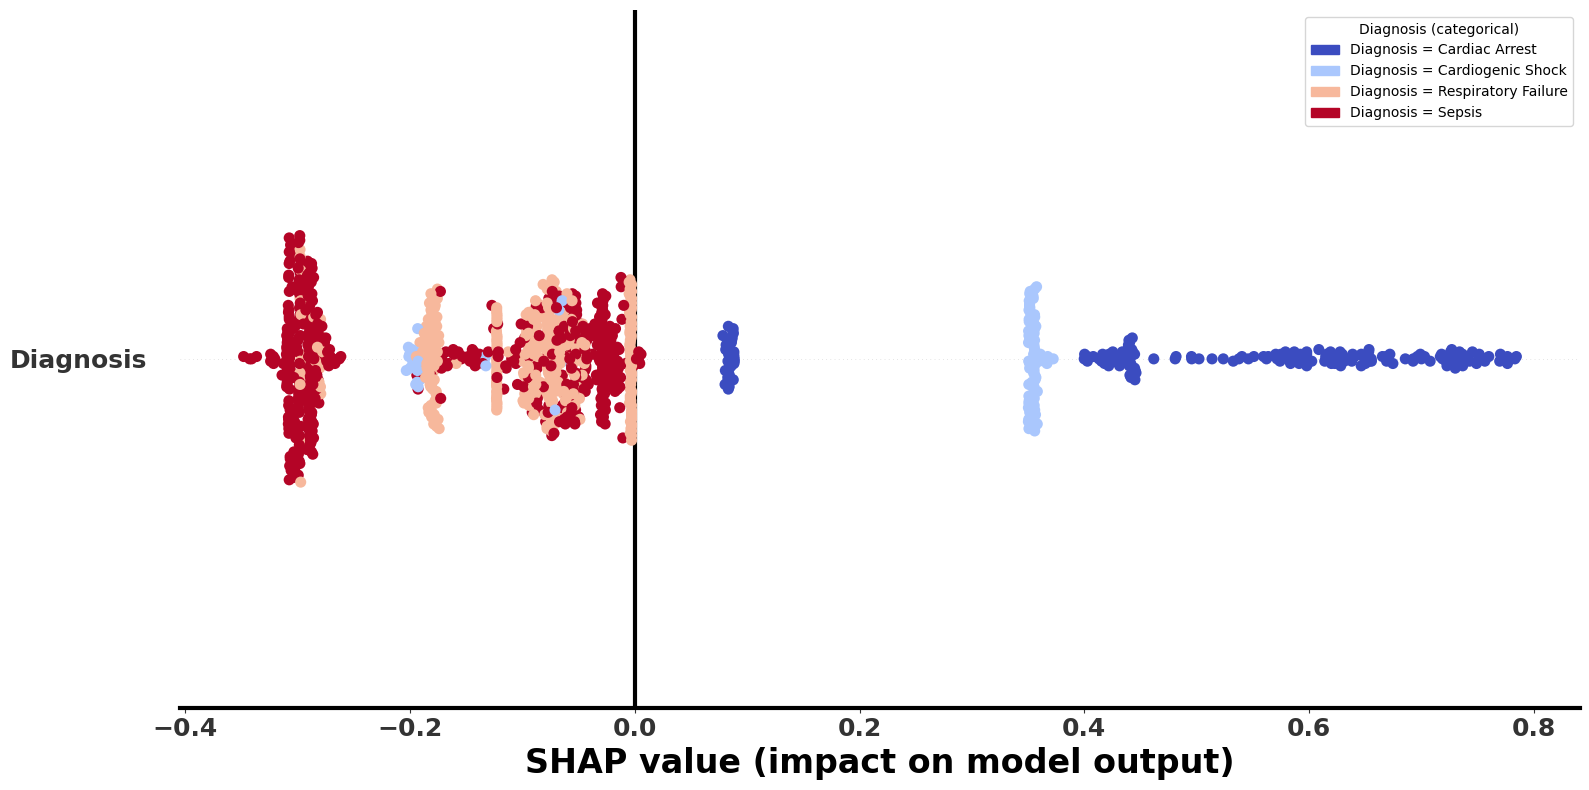

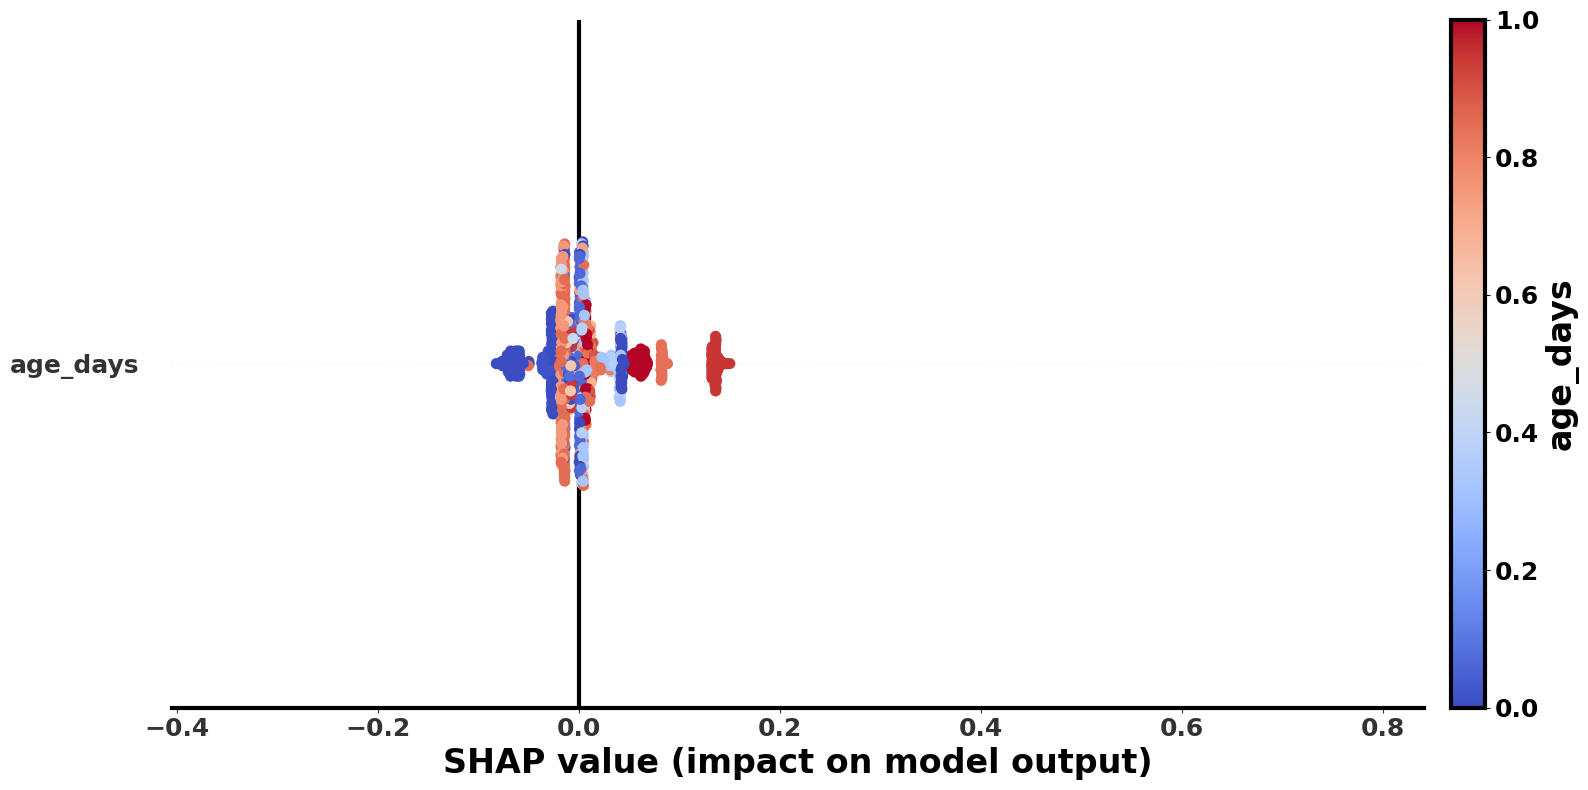

In [107]:
from matplotlib.cm import ScalarMappable

# ---------- knobs ----------
W, H = 16, 8          # figure size (each plot)
POINT_SCALE = 4.0     # multiplies dot sizes from SHAP beeswarm
LABEL_FS = 24
TICK_FS  = 18
SPINE_W  = 3.0        # <-- thicker black boundary
ZERO_W   = 3.0

def scale_beeswarm_points(ax, scale=POINT_SCALE):
    for col in ax.collections:
        try:
            col.set_sizes(col.get_sizes() * scale)
        except Exception:
            pass

def style_axes_with_black_boundary(ax, xlabel=None):
    # ticks
    for t in ax.get_xticklabels():
        t.set_fontsize(TICK_FS); t.set_fontweight("bold")
    for t in ax.get_yticklabels():
        t.set_fontsize(TICK_FS); t.set_fontweight("bold")
    # spines = black boundary
    for s in ax.spines.values():
        s.set_linewidth(SPINE_W)
        s.set_color("black")
    # zero line
    ax.axvline(0, color="black", linewidth=ZERO_W)
    # label
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=LABEL_FS, fontweight="bold")

# ===================== Figure 1: Diagnosis (categorical) =====================
try:
    shap.plots.beeswarm(exp_dx, max_display=1, color=cmap,
                        color_bar=False, show=False, plot_size=(W, H))
except TypeError:
    shap.plots.beeswarm(exp_dx, max_display=1, color=cmap,
                        color_bar=False, show=False)

fig1 = plt.gcf(); ax1 = plt.gca()
fig1.set_size_inches(W, H, forward=True)
scale_beeswarm_points(ax1, POINT_SCALE)

ax1.set_xlim(*xlim)
legend_handles = [
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[0])), label=f"Diagnosis = {dx_text_labels[0]}"),
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[1])), label=f"Diagnosis = {dx_text_labels[1]}"),
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[2])), label=f"Diagnosis = {dx_text_labels[2]}"),
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[3])), label=f"Diagnosis = {dx_text_labels[3]}"),
]
ax1.legend(handles=legend_handles, title=f"{DX_LABEL} (categorical)", loc="upper right", frameon=True)

style_axes_with_black_boundary(ax1, xlabel="SHAP value (impact on model output)")
plt.tight_layout()
plt.show()

# ===================== Figure 2: Age (continuous colorbar) =====================
try:
    shap.plots.beeswarm(exp_age, max_display=1, color=cmap,
                        color_bar=False, show=False, plot_size=(W, H))
except TypeError:
    shap.plots.beeswarm(exp_age, max_display=1, color=cmap,
                        color_bar=False, show=False)

fig2 = plt.gcf(); ax2 = plt.gca()
fig2.set_size_inches(W, H, forward=True)
scale_beeswarm_points(ax2, POINT_SCALE)

ax2.set_xlim(*xlim)

# Colorbar with black boundary too
sm = ScalarMappable(cmap=cmap, norm=age_norm); sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label(AGE_LABEL, fontsize=LABEL_FS, fontweight="bold")
for t in cbar.ax.get_yticklabels():
    t.set_fontsize(TICK_FS); t.set_fontweight("bold")
for s in cbar.ax.spines.values():          # <-- black boundary around the colorbar
    s.set_linewidth(SPINE_W)
    s.set_color("black")

style_axes_with_black_boundary(ax2, xlabel="SHAP value (impact on model output)")
plt.tight_layout();
plt.show()


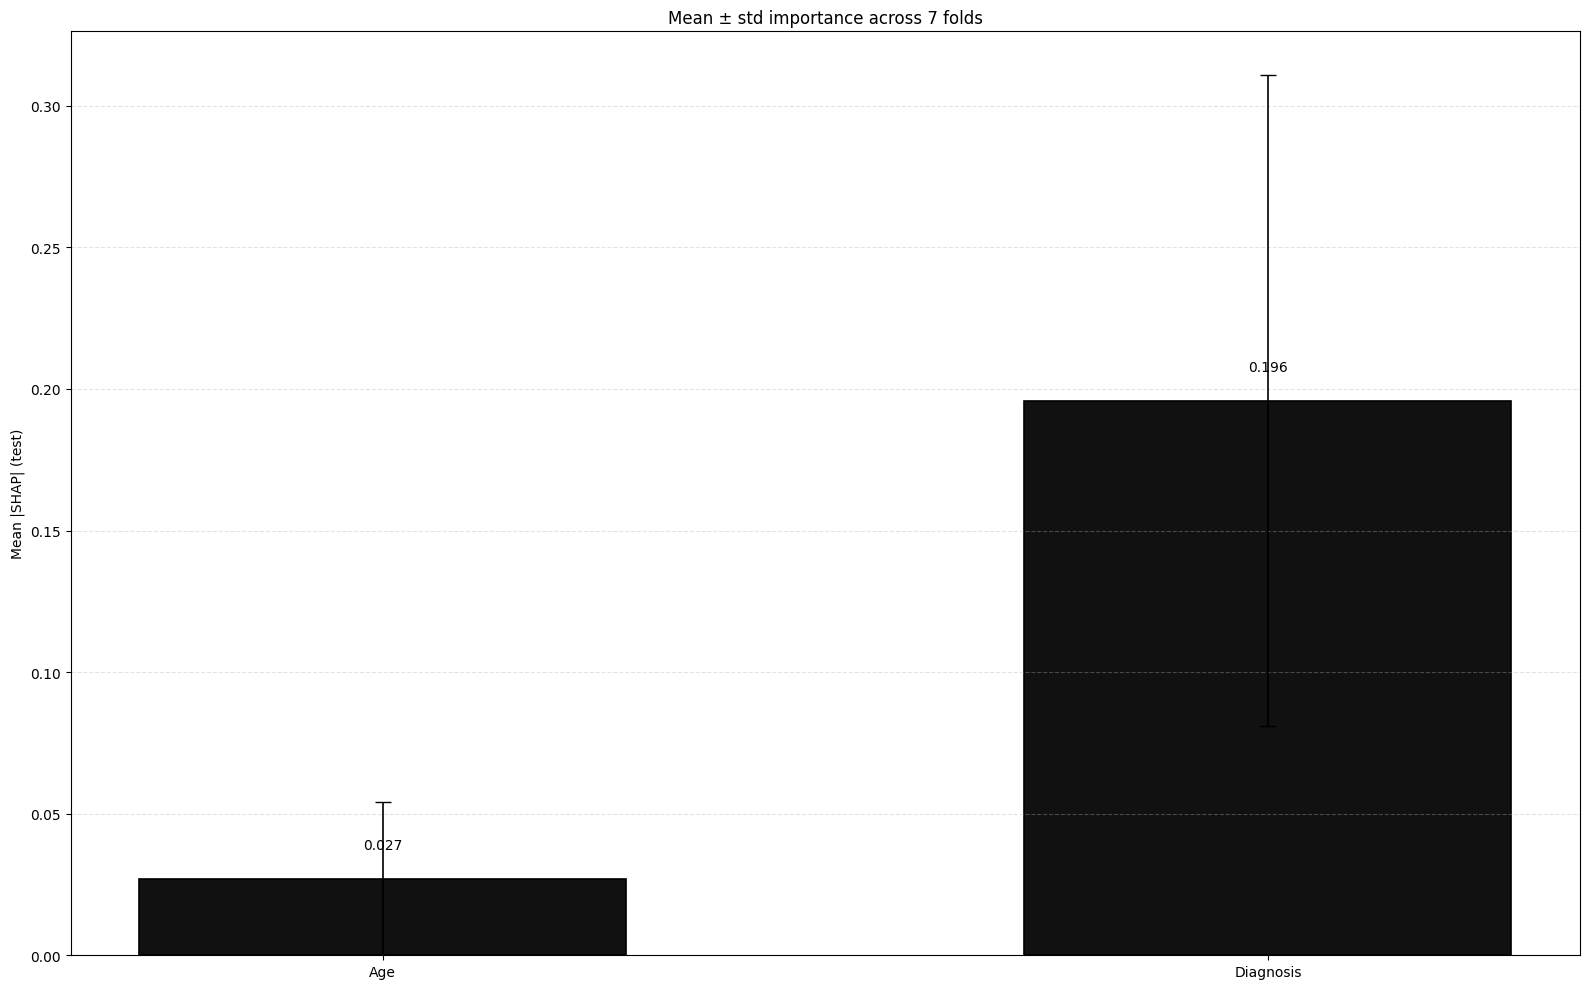

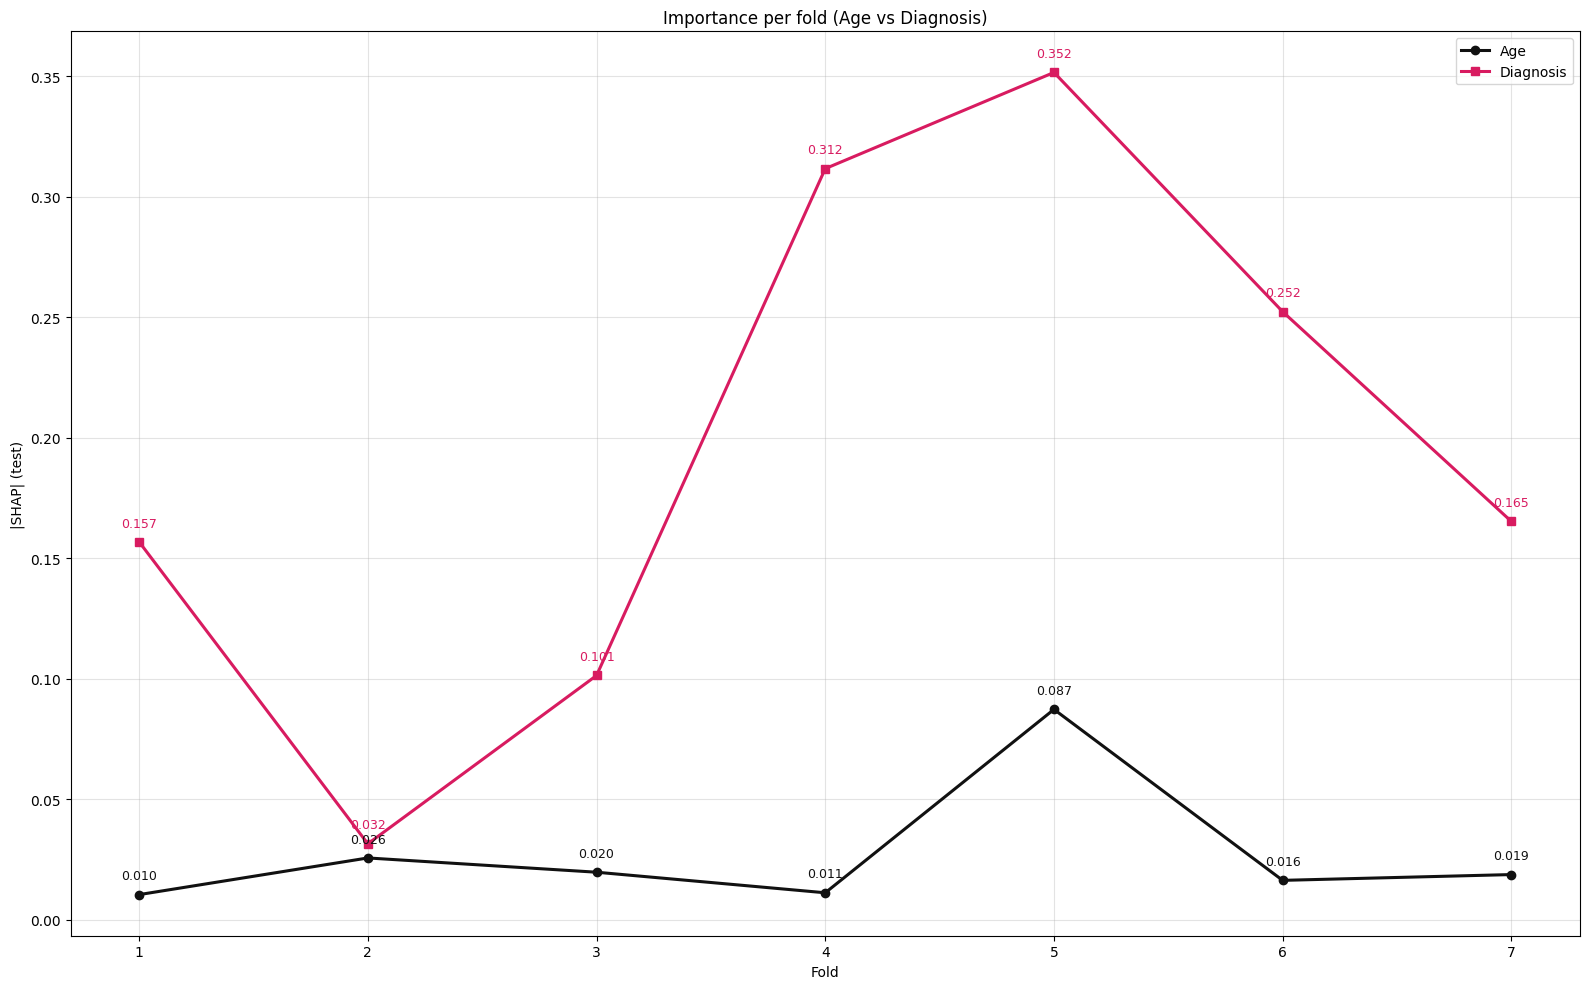

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# assume your dict is:
stats = age_dx_results

per_fold = stats["per_fold"]
age_key  = stats["feature_indices"].get("AGE_label", "age_days")
dx_key   = stats["feature_indices"].get("DIAGNOSIS_label", "Diagnosis")

# order folds numerically: fold_01, fold_02, ...
fold_ids  = sorted(per_fold.keys(), key=lambda s: int(s.split("_")[1]))
fold_nums = [int(f.split("_")[1]) for f in fold_ids]

# arrays of per-fold values
age_vals = np.array([float(per_fold[f][age_key]) for f in fold_ids], dtype=float)
dx_vals  = np.array([float(per_fold[f][dx_key])  for f in fold_ids], dtype=float)

# ---------- Plot 1: mean ± std across folds (both bars black) ----------
age_mean, age_std = age_vals.mean(), age_vals.std(ddof=1)
dx_mean,  dx_std  = dx_vals.mean(),  dx_vals.std(ddof=1)

plt.figure(figsize=(16, 10))
x = np.arange(2)
means = [age_mean, dx_mean]
stds  = [age_std,  dx_std]

bars = plt.bar(
    x, means, yerr=stds, width=0.55,
    color=["#111111", "#111111"],  # both black
    edgecolor="black", linewidth=1.2,
    error_kw=dict(ecolor="black", elinewidth=1.2, capsize=6)
)
plt.xticks(x, ["Age", "Diagnosis"])
plt.ylabel("Mean |SHAP| (test)")
plt.title("Mean ± std importance across 7 folds")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# annotate means above bars
ymax = max(m + s for m, s in zip(means, stds))
for i, m in enumerate(means):
    plt.text(i, m + 0.03 * ymax, f"{m:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# ---------- Plot 2: importance across folds with value labels ----------
plt.figure(figsize=(16, 10))

# Age: black
plt.plot(fold_nums, age_vals, marker="o", linewidth=2.2, color="#111111", label="Age")
# Diagnosis: red
plt.plot(fold_nums, dx_vals,  marker="s", linewidth=2.2, color="#D81B60", label="Diagnosis")

plt.xticks(fold_nums, [str(n) for n in fold_nums])
plt.xlabel("Fold")
plt.ylabel("|SHAP| (test)")
plt.title("Importance per fold (Age vs Diagnosis)")
plt.grid(True, alpha=0.35)
plt.legend(frameon=True, loc="best")

# add numeric labels near each point
all_vals = np.concatenate([age_vals, dx_vals])
offset = 0.015 * (all_vals.max() - all_vals.min() if all_vals.max() > all_vals.min() else 1.0)

for x0, y0 in zip(fold_nums, age_vals):
    plt.text(x0, y0 + offset, f"{y0:.3f}", color="#111111", ha="center", va="bottom", fontsize=9)
for x0, y0 in zip(fold_nums, dx_vals):
    plt.text(x0, y0 + offset, f"{y0:.3f}", color="#D81B60", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [40]:
# ===== Save AGE & DIAGNOSIS SHAP to a pickle =====
import pickle, platform, sys, json
from pathlib import Path
from datetime import datetime
import numpy as np
import shap

# --- helper to snap Dx to {0,1,2,3} (handles floats/strings/np types) ---
def to_0123(a):
    a = np.asarray(a).reshape(-1)
    choices = np.array([0., 1., 2., 3.], dtype=float)
    idx = np.argmin(np.abs(a[:, None] - choices[None, :]), axis=1)
    return choices[idx].astype(np.int8)

# --- REQUIRED: these should already exist from your previous steps ---
# S_age, S_dx = per-sample SHAP arrays across ALL test samples (shape: [N])
# V_age, V_dx = raw feature values for those samples (shape: [N])
# AGE_LABEL, DX_LABEL = your feature names/labels
# Optional: fold_ids_used, all_age_shap (to record per-fold counts)

# ---- build the payload ----
V_dx_codes = to_0123(V_dx)

# diagnosis legend text (edit to your labels)
dx_text_labels = {0: "Cardiac Arrest", 1: "Cardiogenic Shock",
                  2: "Respiratory Failure", 3: "Sepsis"}

payload = {
    "version": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "shap": getattr(shap, "__version__", "unknown"),
        "platform": platform.platform(),
    },
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "meta": {
        "age_label": AGE_LABEL,
        "dx_label": DX_LABEL,
        "dx_text_labels": dx_text_labels,   # {code: label}
        "notes": "Per-sample SHAP across all folds (test only).",
        # Optional per-fold counts if available:
        "per_fold_counts": (
            {int(fid): int(len(arr)) for fid, arr in zip(fold_ids_used, all_age_shap)}
            if 'fold_ids_used' in globals() and 'all_age_shap' in globals() else None
        ),
    },
    "arrays": {
        # SHAP values (impact) for the two features
        "S_age": np.asarray(S_age, dtype=np.float32),
        "S_dx":  np.asarray(S_dx,  dtype=np.float32),
        # Raw feature values used for coloring / filtering
        "V_age": np.asarray(V_age, dtype=np.float32),
        "V_dx_codes": V_dx_codes,  # exactly 0/1/2/3 as int
    }
}

# ---- choose where to save ----
OUT_DIR = Path(save_dir_path) / "exports"  # or set your own folder
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PKL = OUT_DIR / "shap_age_diagnosis.pkl"

with open(OUT_PKL, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"[OK] Saved AGE & DIAGNOSIS SHAP to: {OUT_PKL}")
print(f"N samples: {payload['arrays']['S_age'].shape[0]}")


[OK] Saved AGE & DIAGNOSIS SHAP to: /content/drive/MyDrive/CD/2Bio_SHAP/exports/shap_age_diagnosis.pkl
N samples: 1190


### check the EEG importances

In [110]:
from pathlib import Path
import numpy as np
import shap
from tensorflow import keras
from tensorflow.keras import layers

In [111]:
def compute_eeg_shap_per_sample(save_dir: str,
                                fold_to_run: int = 1,
                                background_n: int = 64):
    """
    Compute EEG SHAP maps per test sample for a given fold.
    Inputs
    ------
    save_dir:       directory that contains fold_{XX}/ with weights & split files
    fold_to_run:    which fold to load (1-based)
    background_n:   number of (train+val) examples used as SHAP background

    Returns
    -------
    shapN : np.ndarray, shape (N, H, W, 1)   # SHAP for class N per test sample
    shapY : np.ndarray, shape (N, H, W, 1)   # SHAP for class Y per test sample
    info  : dict with keys:
        - engine: str  (which SHAP explainer was used)
        - H, W, C
        - X_img_test, X_tab_test  (for optional plotting)
        - test_files, bg_files
    """


    # ---------- helpers (use your existing loaders/globals) ----------
    rng = np.random.default_rng(1)

    def _pick_bg_files(train_files, val_files, k):
        pool = list(train_files) + list(val_files)
        if not pool:
            pool = list(train_files)
        if not pool:
            raise RuntimeError("No background data for SHAP (train+val empty).")
        k = min(k, len(pool))
        idx = rng.choice(len(pool), size=k, replace=False)
        return [pool[i] for i in idx]

    def _build_arrays(file_list, H=None, W=None):
        """Return (X_img, X_tab, H, W) using load_csv_as_image_cached + ID_TO_FEAT."""
        img0 = load_csv_as_image_cached(file_list[0])
        if img0.ndim == 2:
            img0 = img0[..., None]
        if H is None or W is None:
            H, W = img0.shape[0], img0.shape[1]

        tab_dim = len(next(iter(ID_TO_FEAT.values())))
        X_img = np.empty((len(file_list), H, W, 1), dtype=np.float32)
        X_tab = np.empty((len(file_list), tab_dim), dtype=np.float32)

        for i, f in enumerate(file_list):
            xi = load_csv_as_image_cached(f)
            if xi.ndim == 2:
                xi = xi[..., None]
            # pad/crop to (H, W)
            if xi.shape[:2] != (H, W):
                h, w = xi.shape[:2]
                buf = np.zeros((H, W, 1), dtype=xi.dtype)
                buf[:min(h, H), :min(w, W), 0] = xi[:min(h, H), :min(w, W), 0]
                xi = buf
            X_img[i] = xi
            pid = patient_num_from_path(f)
            X_tab[i] = ID_TO_FEAT[pid]
        return X_img, X_tab, H, W

    def _ensure_4d(x, H, W, C, select_class=None):
        """
        Normalize SHAP map to (1, H, W, C).
        Handles shapes like (H,W,C,2), (H,W,2), (1,H,W,C,2), (1,H,W,2), (H,W,C), (H,W), etc.
        If last dim==2 and select_class is not None, pick that class; else average over it.
        """
        x = np.asarray(x)
        # if final dim is the two classes [N,Y]
        if x.ndim >= 3 and x.shape[-1] == 2:
            x = x[..., select_class] if select_class is not None else x.mean(axis=-1)

        if x.ndim == 2 and x.shape == (H, W):
            x = x[..., None]
        if x.ndim == 3 and x.shape == (H, W, C):
            return x[None, ...]
        if x.ndim == 4 and x.shape[1:4] == (H, W, C):
            return x[:1]  # K==1
        # best-effort squeeze then fix
        x = np.squeeze(x)
        if x.ndim == 2 and x.shape == (H, W):
            return x[None, ..., None]
        if x.ndim == 3 and x.shape == (H, W, C):
            return x[None, ...]
        raise ValueError(f"Unexpected SHAP map shape {x.shape}")

    # ---------- locate fold files ----------
    fold_dir   = Path(save_dir) / f"fold_{fold_to_run:02d}"
    weights_fp = fold_dir / f"best_fold_{fold_to_run:02d}.h5"
    train_txt  = fold_dir / "train_files.txt"
    test_txt   = fold_dir / "test_files.txt"
    val_txt    = fold_dir / "val_files.txt"

    if not weights_fp.exists():
        raise FileNotFoundError(f"Missing weights: {weights_fp}")
    if not train_txt.exists() or not test_txt.exists():
        raise FileNotFoundError(f"Missing split lists in {fold_dir}")

    train_files = [Path(s) for s in train_txt.read_text().splitlines() if s.strip()]
    test_files  = [Path(s) for s in test_txt.read_text().splitlines() if s.strip()]
    val_files   = [Path(s) for s in (val_txt.read_text().splitlines() if val_txt.exists() else []) if s.strip()]
    if not test_files:
        raise RuntimeError("Empty test set.")

    # ---------- build background & test tensors ----------
    bg_files = _pick_bg_files(train_files, val_files, k=background_n)
    img0 = load_csv_as_image_cached(test_files[0])
    if img0.ndim == 2:
        img0 = img0[..., None]
    H, W, C = img0.shape[0], img0.shape[1], 1

    X_img_bg,  X_tab_bg,  H, W = _build_arrays(bg_files,  H, W)
    X_img_test, X_tab_test, _, _ = _build_arrays(test_files, H, W)

    print("X_img_bg.shape =", X_img_bg.shape)
    print("X_tab_bg.shape =", X_tab_bg.shape)
    print("X_img_test.shape =", X_img_test.shape)
    print("X_tab_test.shape =", X_tab_test.shape)

    # ---------- load model & set up SHAP explainer ----------
    base = keras.models.load_model(str(weights_fp))
    explainer = None
    two_output = False
    engine = None

    try:
        # build 2-output head: [pN, pY] = [1-pY, pY]
        p1 = base.output
        p0 = layers.Lambda(lambda t: 1.0 - t, name="p0")(p1)
        preds2 = layers.Concatenate(name="p0_p1")([p0, p1])
        twin = keras.Model(inputs=base.inputs, outputs=preds2)
        try:
            explainer = shap.DeepExplainer(twin, [X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            two_output = True
            engine = "DeepExplainer (two-output)"
        except Exception:
            explainer = shap.GradientExplainer(twin, data=[X_img_bg, X_tab_bg])
            _ = explainer.shap_values([X_img_test[:1], X_tab_test[:1]], check_additivity=False)
            two_output = True
            engine = "GradientExplainer (two-output)"
    except Exception:
        # fall back to single-output pY
        try:
            explainer = shap.DeepExplainer(base, [X_img_bg, X_tab_bg])
            engine = "DeepExplainer (single-output)"
        except Exception:
            try:
                explainer = shap.GradientExplainer(base, data=[X_img_bg, X_tab_bg])
                engine = "GradientExplainer (single-output)"
            except Exception:
                explainer = shap.Explainer(base, masker=[X_img_bg, X_tab_bg])
                engine = "Explainer (single-output)"

    print("SHAP engine:", engine)

    # ---------- per-sample SHAP ----------
    N = X_img_test.shape[0]
    shapN = np.zeros((N, H, W, 1), dtype=np.float32)
    shapY = np.zeros((N, H, W, 1), dtype=np.float32)

    for i in range(N):
        xi = X_img_test[i:i+1]   # (1,H,W,1)
        xt = X_tab_test[i:i+1]   # (1,D)
        sv = explainer.shap_values([xi, xt], check_additivity=False)

        if two_output:
            # expected: list over classes -> list over inputs
            if isinstance(sv, list) and len(sv) == 2 and isinstance(sv[0], list):
                eegN = sv[0][0]
                eegY = sv[1][0]
                eegN = _ensure_4d(eegN, H, W, 1, select_class=0)
                eegY = _ensure_4d(eegY, H, W, 1, select_class=1)
            else:
                # sometimes SHAP returns a single EEG array where last dim is classes
                eeg = sv[0] if isinstance(sv, list) else sv
                eegN = _ensure_4d(eeg, H, W, 1, select_class=0)
                eegY = _ensure_4d(eeg, H, W, 1, select_class=1)
            shapN[i] = eegN[0]
            shapY[i] = eegY[0]
        else:
            # single-output pY; N map is negative
            eegY = sv[0] if isinstance(sv, list) else sv
            eegY = _ensure_4d(eegY, H, W, 1, select_class=None)
            shapY[i] = eegY[0]
            shapN[i] = -eegY[0]

    print("Per-sample SHAP done:")
    print("  shapN:", shapN.shape)
    print("  shapY:", shapY.shape)

    info = dict(
        engine=engine, H=H, W=W, C=C,
        X_img_test=X_img_test, X_tab_test=X_tab_test,
        test_files=test_files, bg_files=bg_files
    )
    return shapN, shapY, info


In [112]:
 shapN, shapY, info = compute_eeg_shap_per_sample(save_dir = '/content/drive/MyDrive/CD/2Bio_SHAP/',
                                fold_to_run= 2,
                                background_n = 128)

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (124, 360, 6, 1)
X_tab_test.shape = (124, 2)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (124, 360, 6, 1)
  shapY: (124, 360, 6, 1)


In [113]:
def plot_avg_eeg_shap(
    shapN=None, shapY=None,          # (N, time, channels, 1) — optional
    avgN=None, avgY=None,            # (time, channels) or (channels, time) — optional
    cell_x=0.070, cell_y=0.260,      # inches per time step / per channel
    cmap="RdBu_r",
    title_suffix=""
):
    """
    Plot two heatmaps (Avg SHAP — Y on top, Avg SHAP — N below) with a single
    vertical colorbar. Matches your layout; thickness/width set by cell_x/cell_y.

    Pass either shapN/shapY (per-sample SHAP, shape (N, time, channels, 1))
    or pre-averaged maps avgN/avgY (shape (time, channels) or (channels, time)).
    """

    # ----- prepare averages -----
    if avgN is None or avgY is None:
        if shapN is None or shapY is None:
            raise ValueError("Provide either shapN/shapY or avgN/avgY.")
        avgN = shapN.mean(axis=0)[..., 0]      # (time, channels)
        avgY = shapY.mean(axis=0)[..., 0]

    # infer time length & channels, and orient to (channels, time) for plotting
    def _orient_to_ct(mat):
        a = np.asarray(mat)
        h, w = a.shape[:2]
        # your data has time >> channels (e.g., 360 > 6)
        time_is_first = (h >= w)
        if time_is_first:   # (time, channels) -> (channels, time)
            return a.T, h, w
        else:               # (channels, time) -> already correct
            return a, w, h

    avgN_plot, tN, cN = _orient_to_ct(avgN)
    avgY_plot, tY, cY = _orient_to_ct(avgY)

    # sanity: use common dims
    time_len   = tN if tN == tY else max(tN, tY)
    n_channels = cN if cN == cY else max(cN, cY)

    # symmetric color scale across both panels
    vmax = float(max(np.abs(avgN_plot).max(), np.abs(avgY_plot).max())) + 1e-12

    # ----- size from "cell" knobs -----
    W = time_len * cell_x     # total inches for the x dimension
    H = n_channels * cell_y   # total inches for the y dimension

    fig = plt.figure(figsize=(W + 1.0, 2 * H + 0.8))
    gs  = fig.add_gridspec(
        nrows=2, ncols=2,
        width_ratios=[W, 0.7],          # thinner colorbar
        height_ratios=[H, H],
        wspace=0.25, hspace=0.35
    )

    axY = fig.add_subplot(gs[0, 0])
    axN = fig.add_subplot(gs[1, 0])
    cax = fig.add_subplot(gs[:, 1])

    # --- Y on top ---
    imY = axY.imshow(
        avgY_plot, origin="lower", cmap=cmap,
        vmin=-vmax, vmax=vmax,
        extent=[0, time_len, 0, n_channels],
        interpolation="nearest", aspect="auto"   # do not stretch; fill the axes
    )
    axY.set_title(f"Average SHAP — Y{(' ' + title_suffix) if title_suffix else ''}")
    axY.set_xlim(0, time_len); axY.set_ylim(0, n_channels)
    axY.set_xticks([0, time_len/3, 2*time_len/3, time_len])
    axY.set_yticks(list(range(1, n_channels + 1)))
    axY.set_ylabel("Channel")

    # --- N below ---
    imN = axN.imshow(
        avgN_plot, origin="lower", cmap=cmap,
        vmin=-vmax, vmax=vmax,
        extent=[0, time_len, 0, n_channels],
        interpolation="nearest", aspect="auto"
    )
    axN.set_title(f"Average SHAP — N{(' ' + title_suffix) if title_suffix else ''}")
    axN.set_xlim(0, time_len); axN.set_ylim(0, n_channels)
    axN.set_xticks([0, time_len/3, 2*time_len/3, time_len])
    axN.set_yticks(list(range(1, n_channels + 1)))
    axN.set_xlabel("Time")
    axN.set_ylabel("Channel")

    # shared vertical colorbar
    cb = fig.colorbar(imY, cax=cax, orientation="vertical")
    cb.set_label("SHAP value", rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()
    return fig, (axY, axN), cb

def compute_sum(shapY):
    A = np.abs(np.asarray(shapY, float))
    per_time = A.mean(axis=0)                # (T, C, 1)
    return per_time.sum(axis=(0, 2)).reshape(-1,1)         # -> (C,)

/tmp/ipython-input-2874357802.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


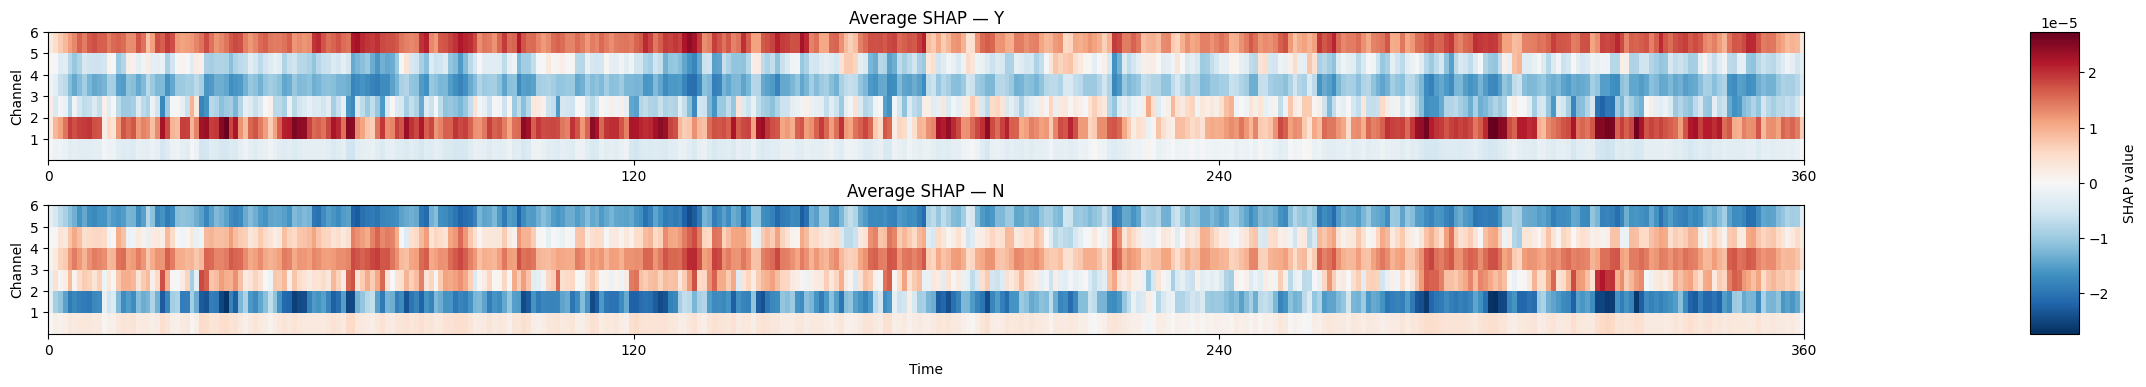

(<Figure size 2620x392 with 3 Axes>,
 (<Axes: title={'center': 'Average SHAP — Y'}, ylabel='Channel'>,
  <Axes: title={'center': 'Average SHAP — N'}, xlabel='Time', ylabel='Channel'>),
 <matplotlib.colorbar.Colorbar at 0x78eb2e93e780>)

In [114]:
plot_avg_eeg_shap(shapN, shapY)

In [115]:
shapY.shape

(124, 360, 6, 1)

### Compute 7 fold importances

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (293, 360, 6, 1)
X_tab_test.shape = (293, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (293, 360, 6, 1)
  shapY: (293, 360, 6, 1)


/tmp/ipython-input-2874357802.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


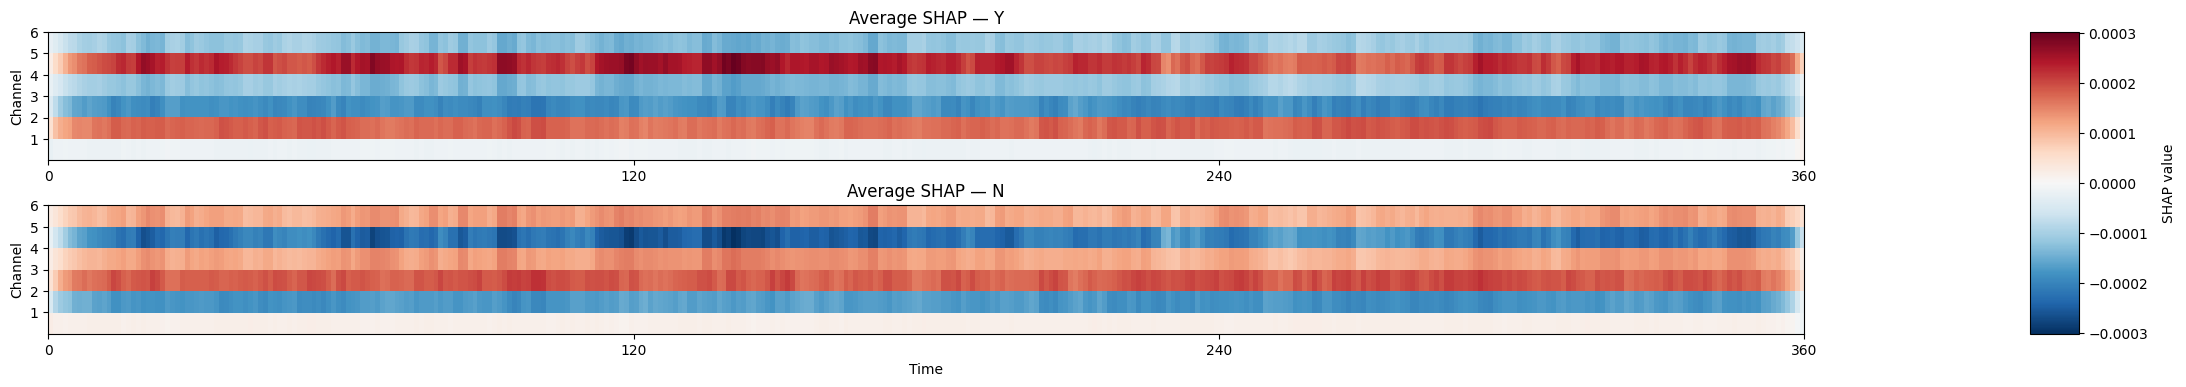

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (124, 360, 6, 1)
X_tab_test.shape = (124, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (124, 360, 6, 1)
  shapY: (124, 360, 6, 1)


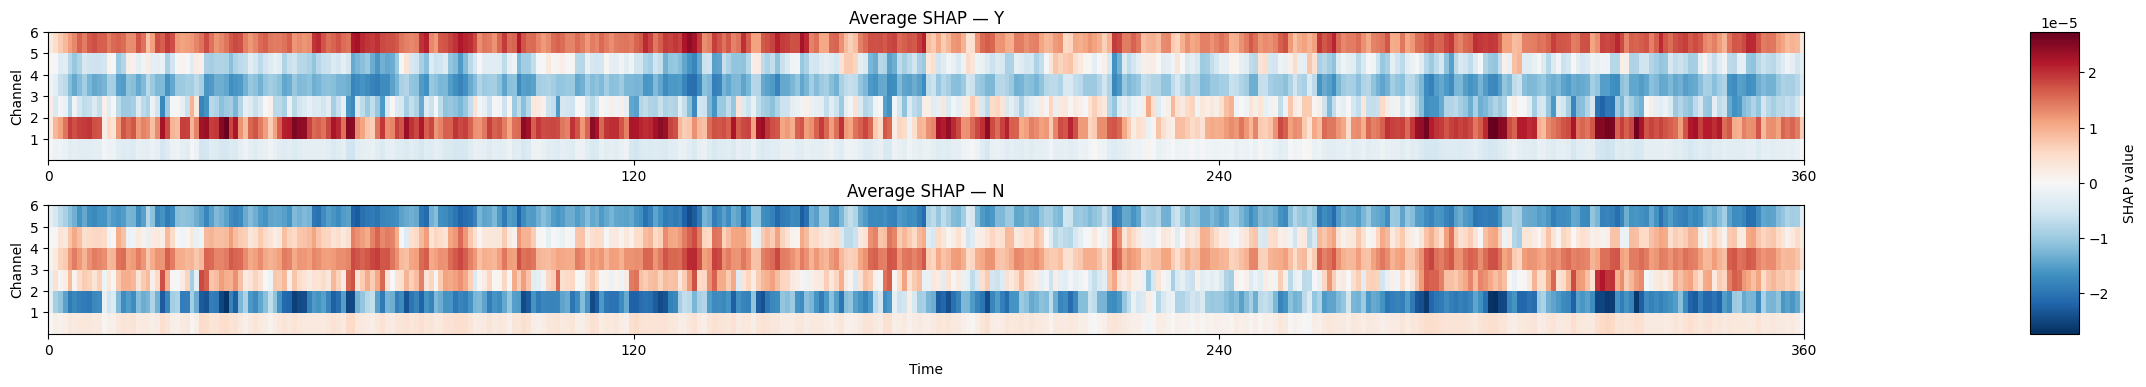

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (127, 360, 6, 1)
X_tab_test.shape = (127, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (127, 360, 6, 1)
  shapY: (127, 360, 6, 1)


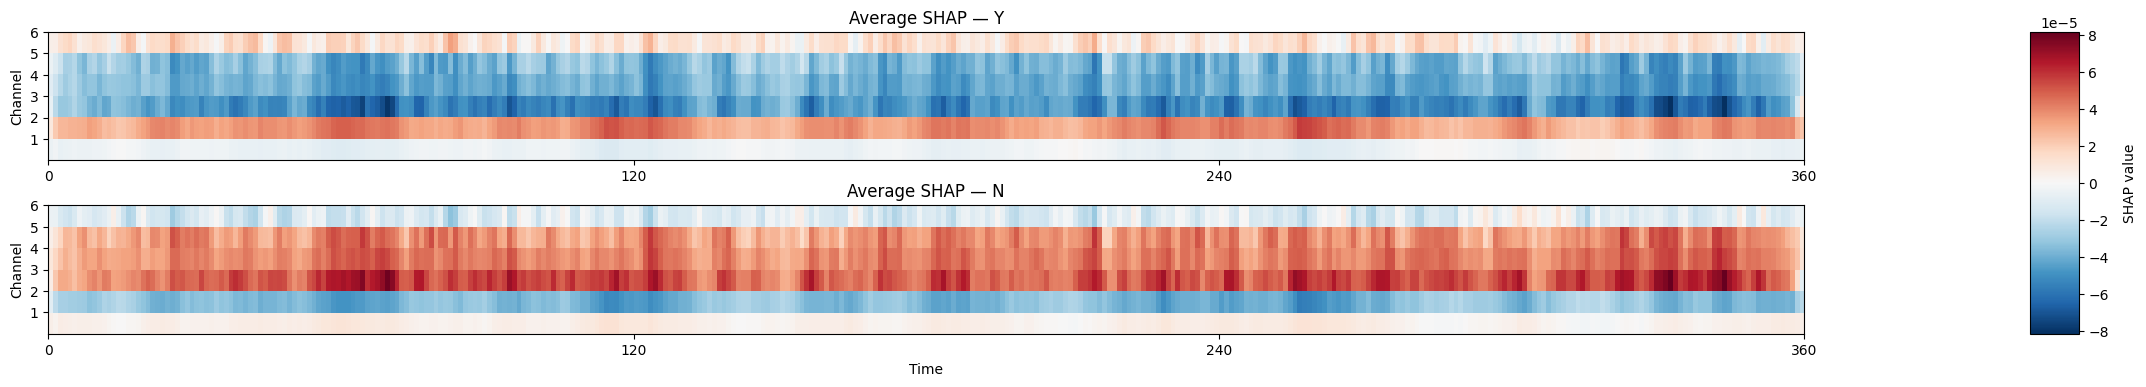

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (69, 360, 6, 1)
X_tab_test.shape = (69, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (69, 360, 6, 1)
  shapY: (69, 360, 6, 1)


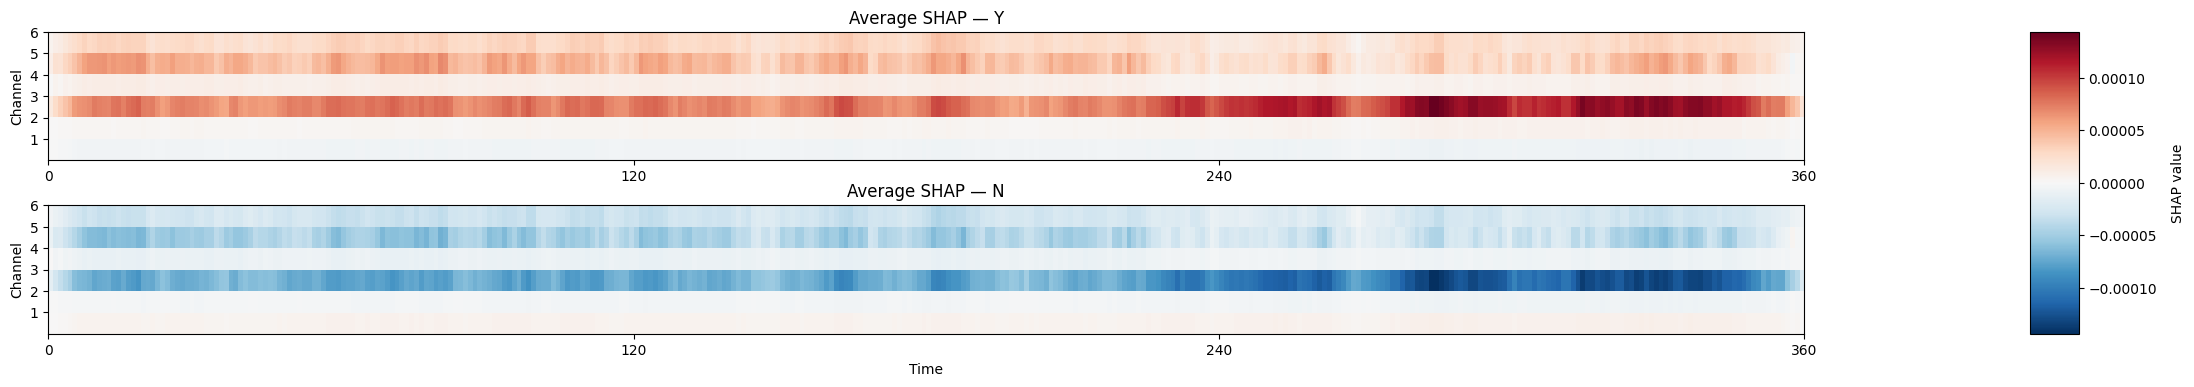

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (110, 360, 6, 1)
X_tab_test.shape = (110, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (110, 360, 6, 1)
  shapY: (110, 360, 6, 1)


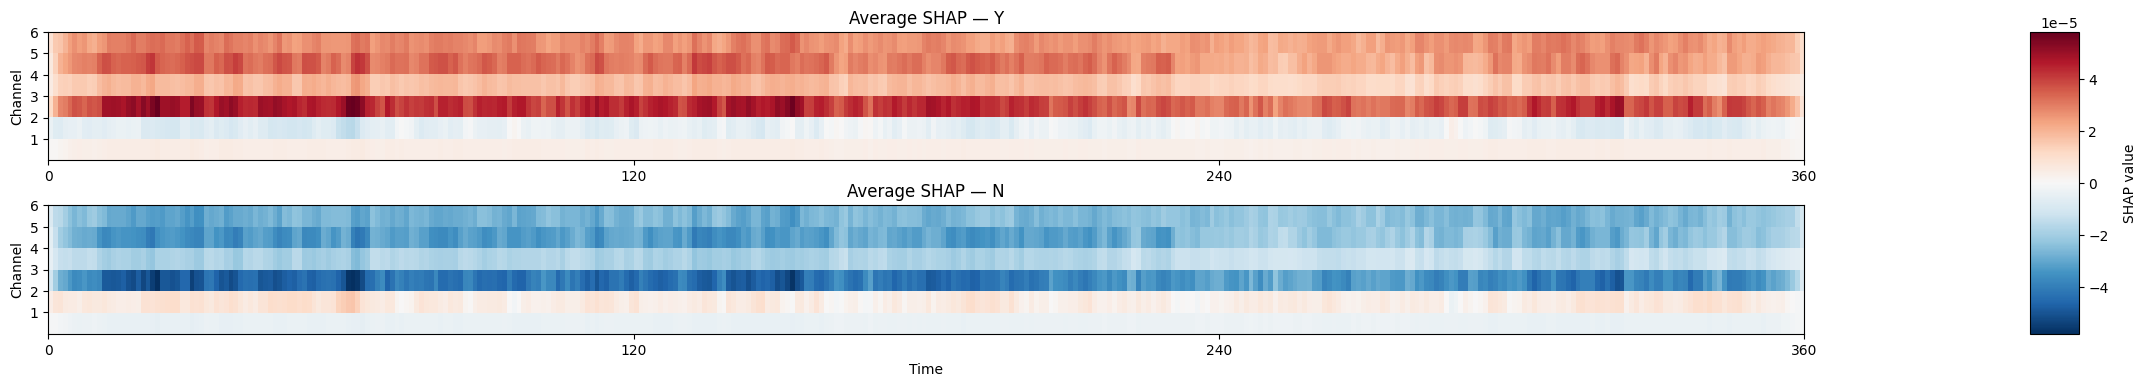

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (243, 360, 6, 1)
X_tab_test.shape = (243, 2)


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (243, 360, 6, 1)
  shapY: (243, 360, 6, 1)


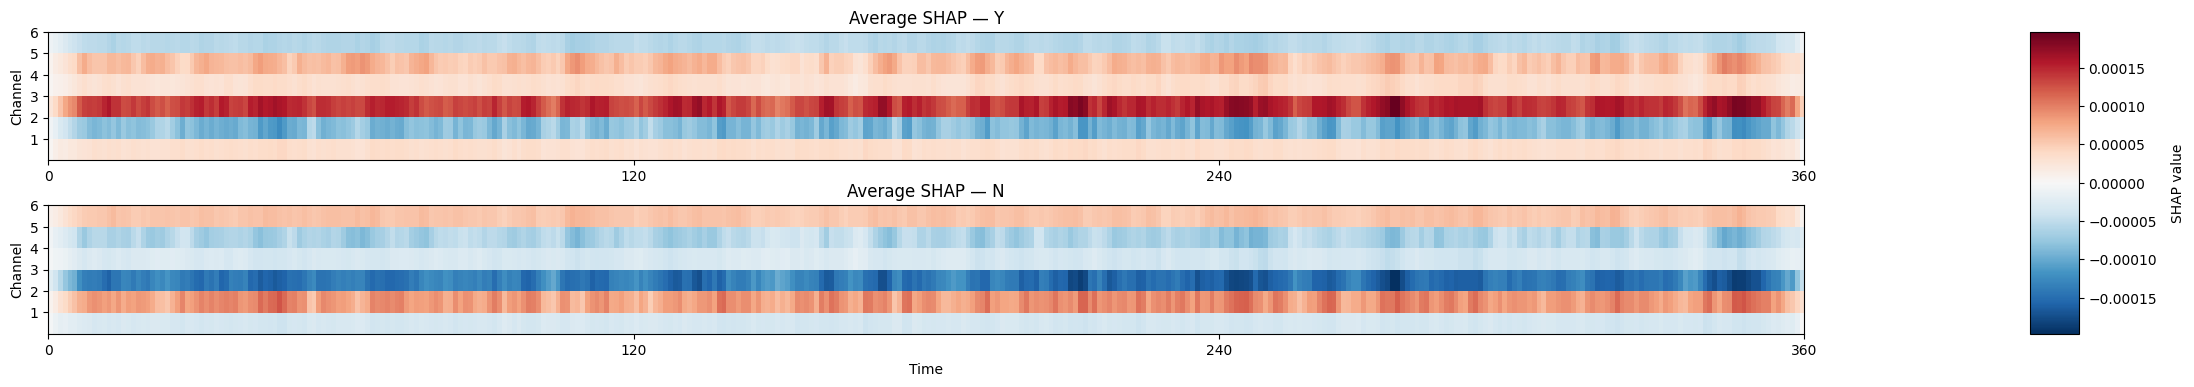

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (224, 360, 6, 1)
X_tab_test.shape = (224, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (224, 360, 6, 1)
  shapY: (224, 360, 6, 1)


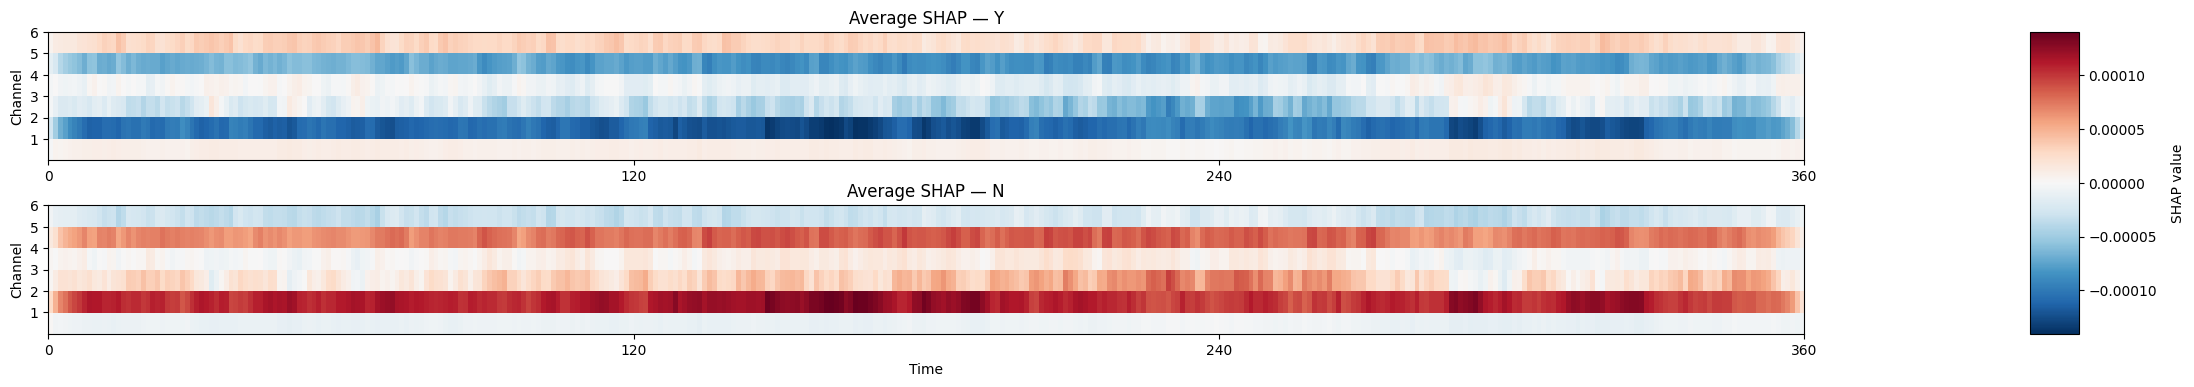

In [116]:
results = {}
for i in range (1, 8):
   shapN, shapY, info = compute_eeg_shap_per_sample(save_dir = '/content/drive/MyDrive/CD/2Bio_SHAP/',
                                fold_to_run= i,
                                background_n = 128)
   plot_avg_eeg_shap(shapN, shapY)
   results[i] = [compute_sum(shapY), compute_sum(shapN)]

In [117]:
results[1]

[array([[0.01014964],
        [0.09218619],
        [0.12345375],
        [0.05219736],
        [0.09891746],
        [0.05194081]]),
 array([[0.01014964],
        [0.09218619],
        [0.12345375],
        [0.05219736],
        [0.09891746],
        [0.05194081]])]

                        Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  \
Row 1 — Global 1–4hz  0.010150  0.006028  0.004176  0.003174  0.002286   
Row 2 — Left 1–4hz    0.092186  0.043009  0.017096  0.004048  0.031228   
Row 3 — Right 1–4hz   0.123454  0.031583  0.033345  0.041829  0.038427   
Row 4 — Global 4–8hz  0.052197  0.018913  0.026524  0.005269  0.017641   
Row 5 — Left 4–8hz    0.098917  0.035662  0.032848  0.038246  0.031029   
Row 6 — Right 4–8hz   0.051941  0.017995  0.034906  0.020324  0.016592   

                        Fold 6    Fold 7  
Row 1 — Global 1–4hz  0.024572  0.008837  
Row 2 — Left 1–4hz    0.110316  0.063889  
Row 3 — Right 1–4hz   0.108535  0.079984  
Row 4 — Global 4–8hz  0.019801  0.034614  
Row 5 — Left 4–8hz    0.051995  0.059670  
Row 6 — Right 4–8hz   0.032882  0.027919  


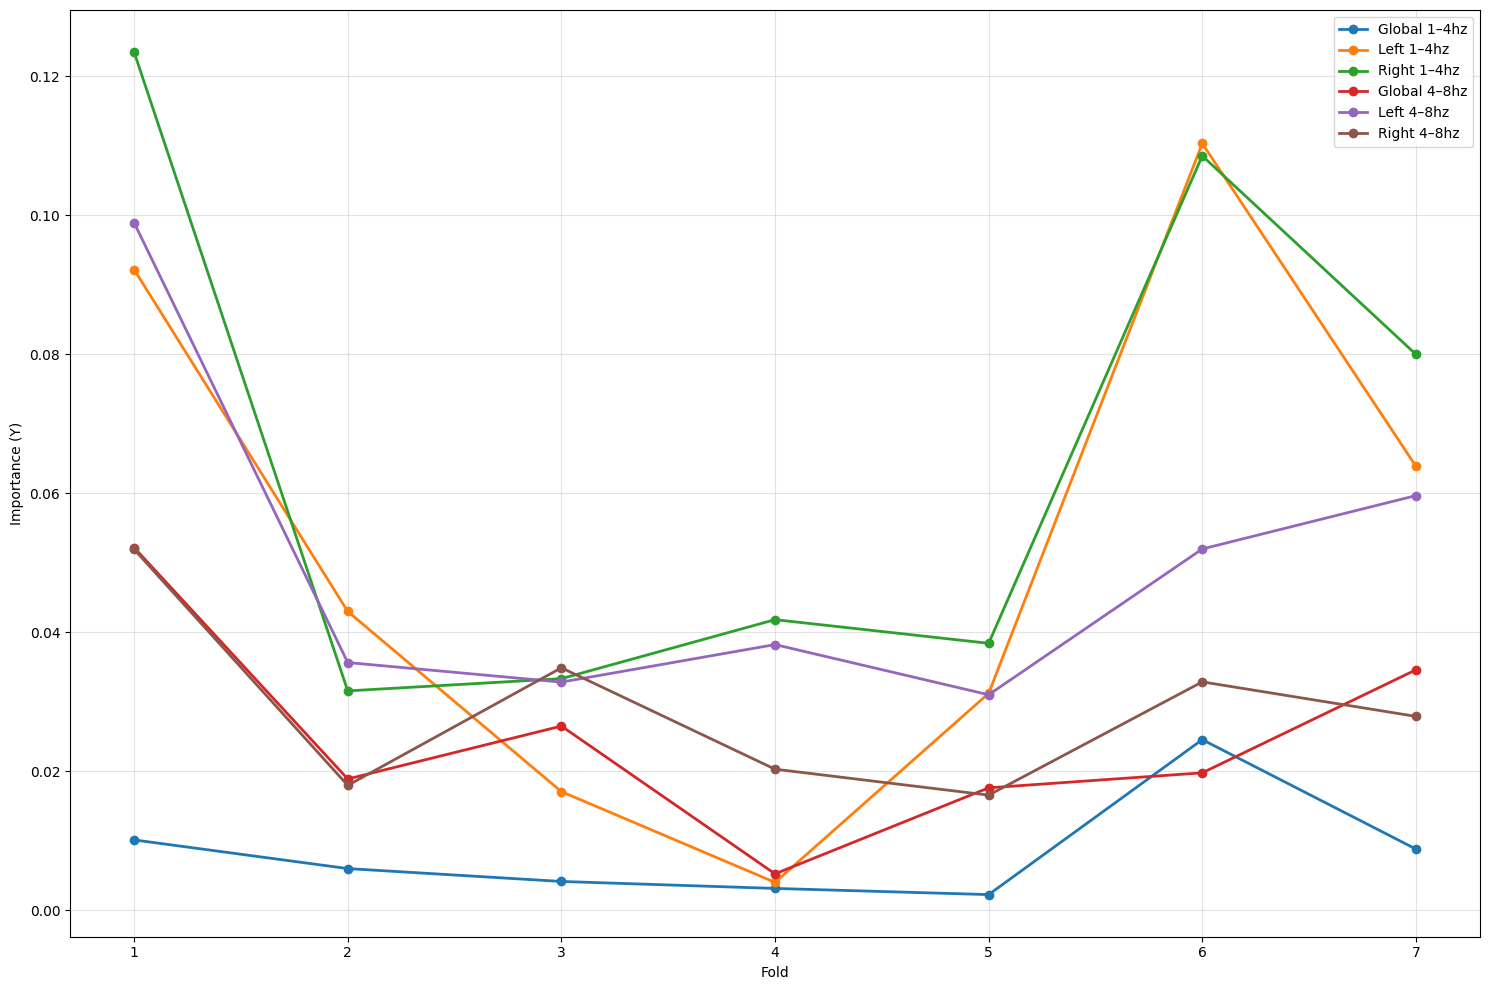

In [118]:
# === labels for the 6 rows (row 1 is the BOTTOM band, row 6 is the TOP band) ===
# Put YOUR exact CSV non-Time column names here, in order 1..6:
ROW_LABELS = [
    "Global 1–4hz",
    "Left 1–4hz",
    "Right 1–4hz",
    "Global 4–8hz",
    "Left 4–8hz",
    "Right 4–8hz",                     # row 6 (top)
]
assert len(ROW_LABELS) == 6, "Need exactly 6 row labels."

# ---- collect Y-only importances into a (6 x F) matrix ----
folds = sorted(results.keys())
y_cols = []
for f in folds:
    y_imp = np.squeeze(np.asarray(results[f][0])).astype(float)
    if y_imp.ndim > 1:
        y_imp = y_imp.ravel()
    if y_imp.shape[0] != 6:
        raise ValueError(f"Fold {f} Y importance has shape {y_imp.shape}, expected 6.")
    y_cols.append(y_imp)

Y = np.column_stack(y_cols)  # (6, num_folds)

# Optional: table
imp_table = pd.DataFrame(Y, index=[f"Row {i+1} — {ROW_LABELS[i]}" for i in range(6)],
                         columns=[f"Fold {f}" for f in folds])
print(imp_table)

# ---- plot: 6 labeled lines over folds (Y only) ----
fig, ax = plt.subplots(figsize=(15, 10))
for r in range(6):
    ax.plot(folds, Y[r, :], marker='o', linewidth=2, label=f"{ROW_LABELS[r]}")

ax.set_xticks(folds, [str(f) for f in folds])
ax.set_xlabel("Fold")
ax.set_ylabel("Importance (Y)")
#ax.set_title("Row-wise EEG importance for Y across folds\n"
#             "(Row 1 = bottom band in the EEG image; Row 6 = top band)")
ax.grid(True, alpha=0.35)

# Put the legend outside so long labels fit
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


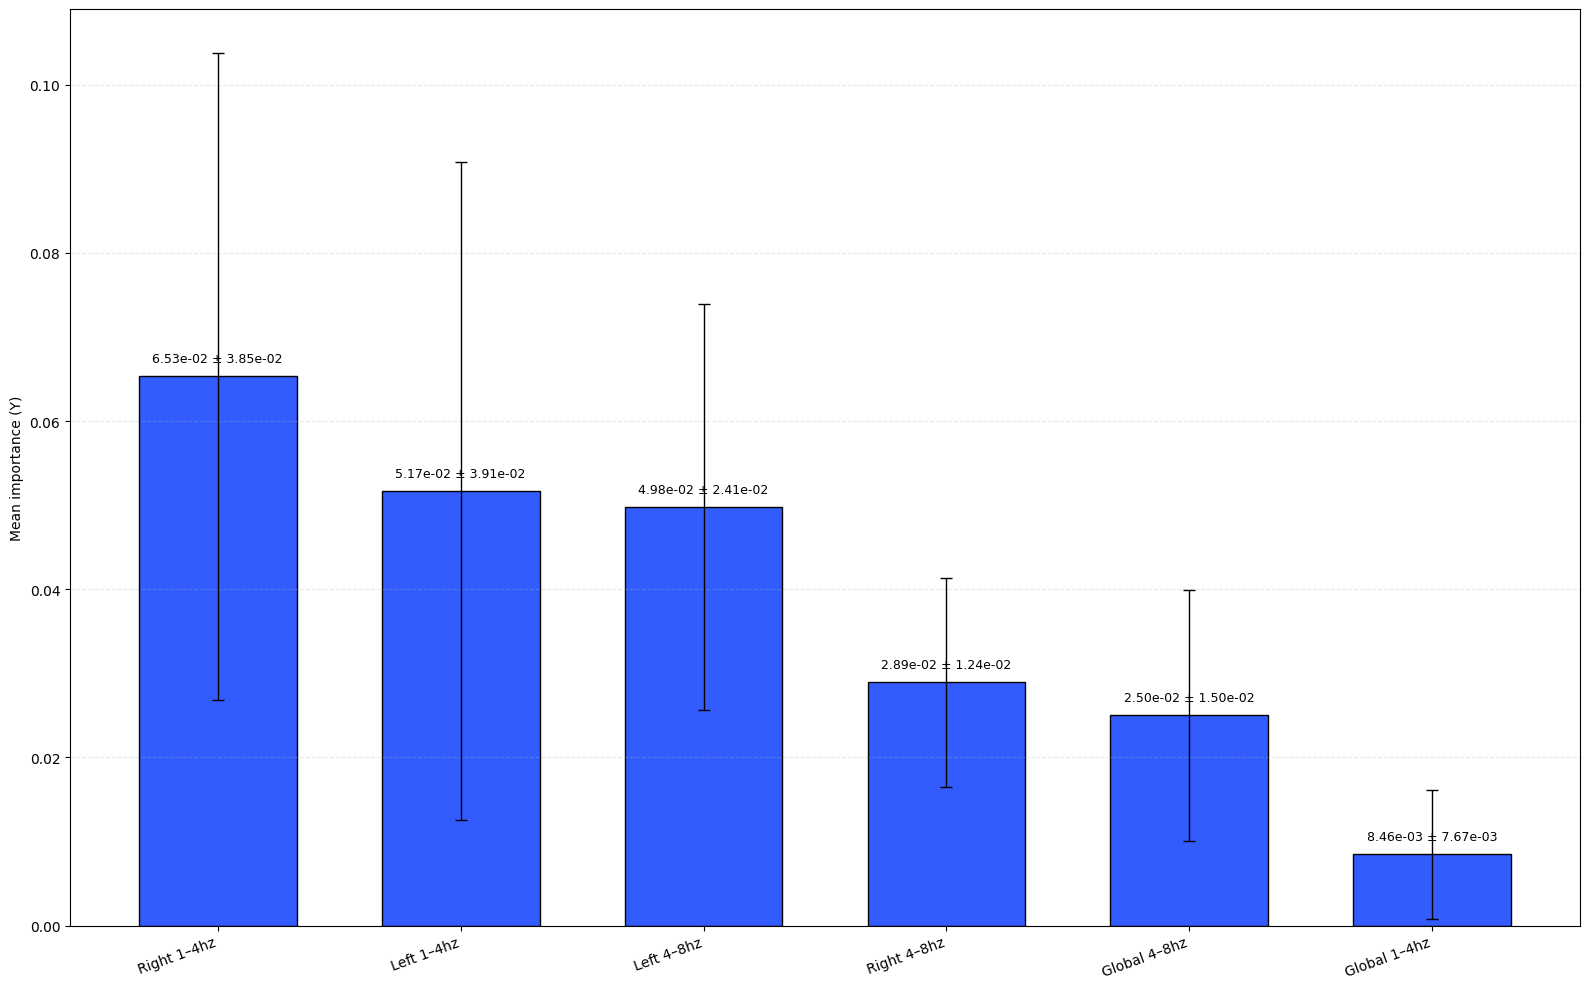

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# --- compute mean/std across folds (columns) ---
avg = Y.mean(axis=1)                 # shape (6,)
std = Y.std(axis=1, ddof=1)          # sample std

# --- sort by mean importance descending (optional) ---
order = np.argsort(avg)[::-1]
avg_sorted = avg[order]
std_sorted = std[order]
labels_sorted = [ROW_LABELS[i] for i in order]

# --- bar chart ---
fig, ax = plt.subplots(figsize=(16, 10))
x = np.arange(len(labels_sorted))

bars = ax.bar(
    x, avg_sorted, yerr=std_sorted, width=0.65,
    color="#335CFF", edgecolor="black", linewidth=1.0,
    error_kw=dict(ecolor="black", elinewidth=1.0, capsize=4)
)

# axes & labels
ax.set_xticks(x, labels_sorted, rotation=20, ha="right")
ax.set_ylabel("Mean importance (Y)")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))  # scientific notation if tiny

# annotate values on top of bars
for xi, m, s in zip(x, avg_sorted, std_sorted):
    ax.text(xi, m + (0.02 * max(abs(avg_sorted)) if max(abs(avg_sorted)) > 0 else 1e-12),
            f"{m:.2e} ± {s:.2e}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


                Fold 1    Fold 2    Fold 3    Fold 4    Fold 5    Fold 6  \
Global 1–4hz  0.010150  0.006028  0.004176  0.003174  0.002286  0.024572   
Left 1–4hz    0.092186  0.043009  0.017096  0.004048  0.031228  0.110316   
Right 1–4hz   0.123454  0.031583  0.033345  0.041829  0.038427  0.108535   
Global 4–8hz  0.052197  0.018913  0.026524  0.005269  0.017641  0.019801   
Left 4–8hz    0.098917  0.035662  0.032848  0.038246  0.031029  0.051995   
Right 4–8hz   0.051941  0.017995  0.034906  0.020324  0.016592  0.032882   

                Fold 7  
Global 1–4hz  0.008837  
Left 1–4hz    0.063889  
Right 1–4hz   0.079984  
Global 4–8hz  0.034614  
Left 4–8hz    0.059670  
Right 4–8hz   0.027919  


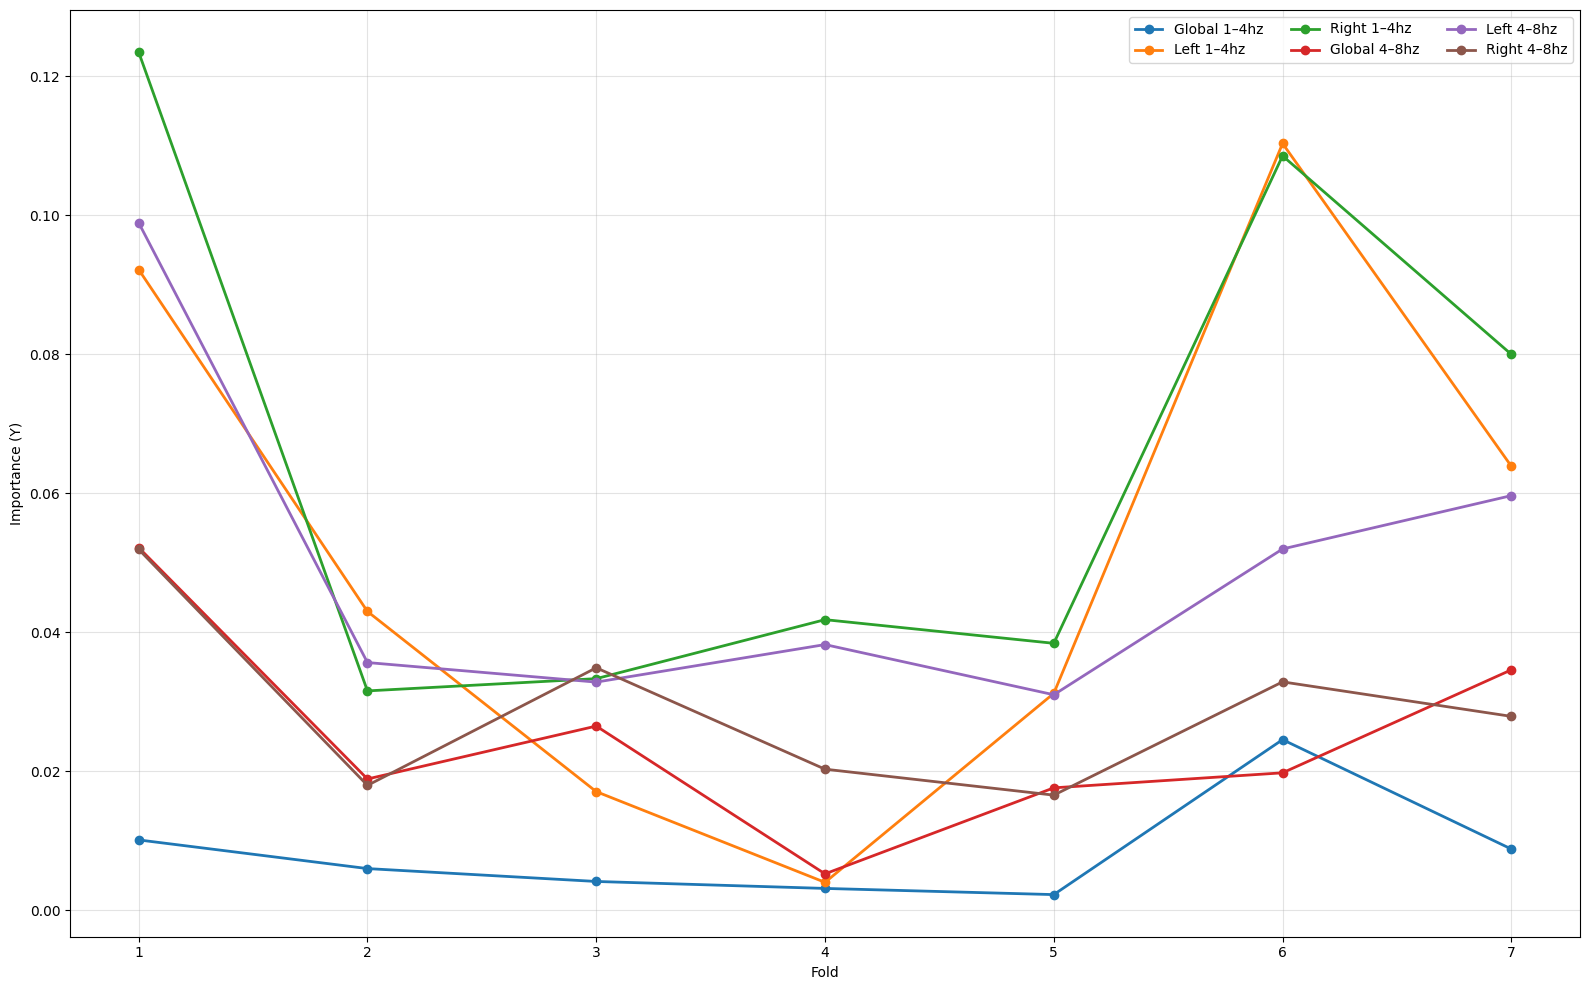

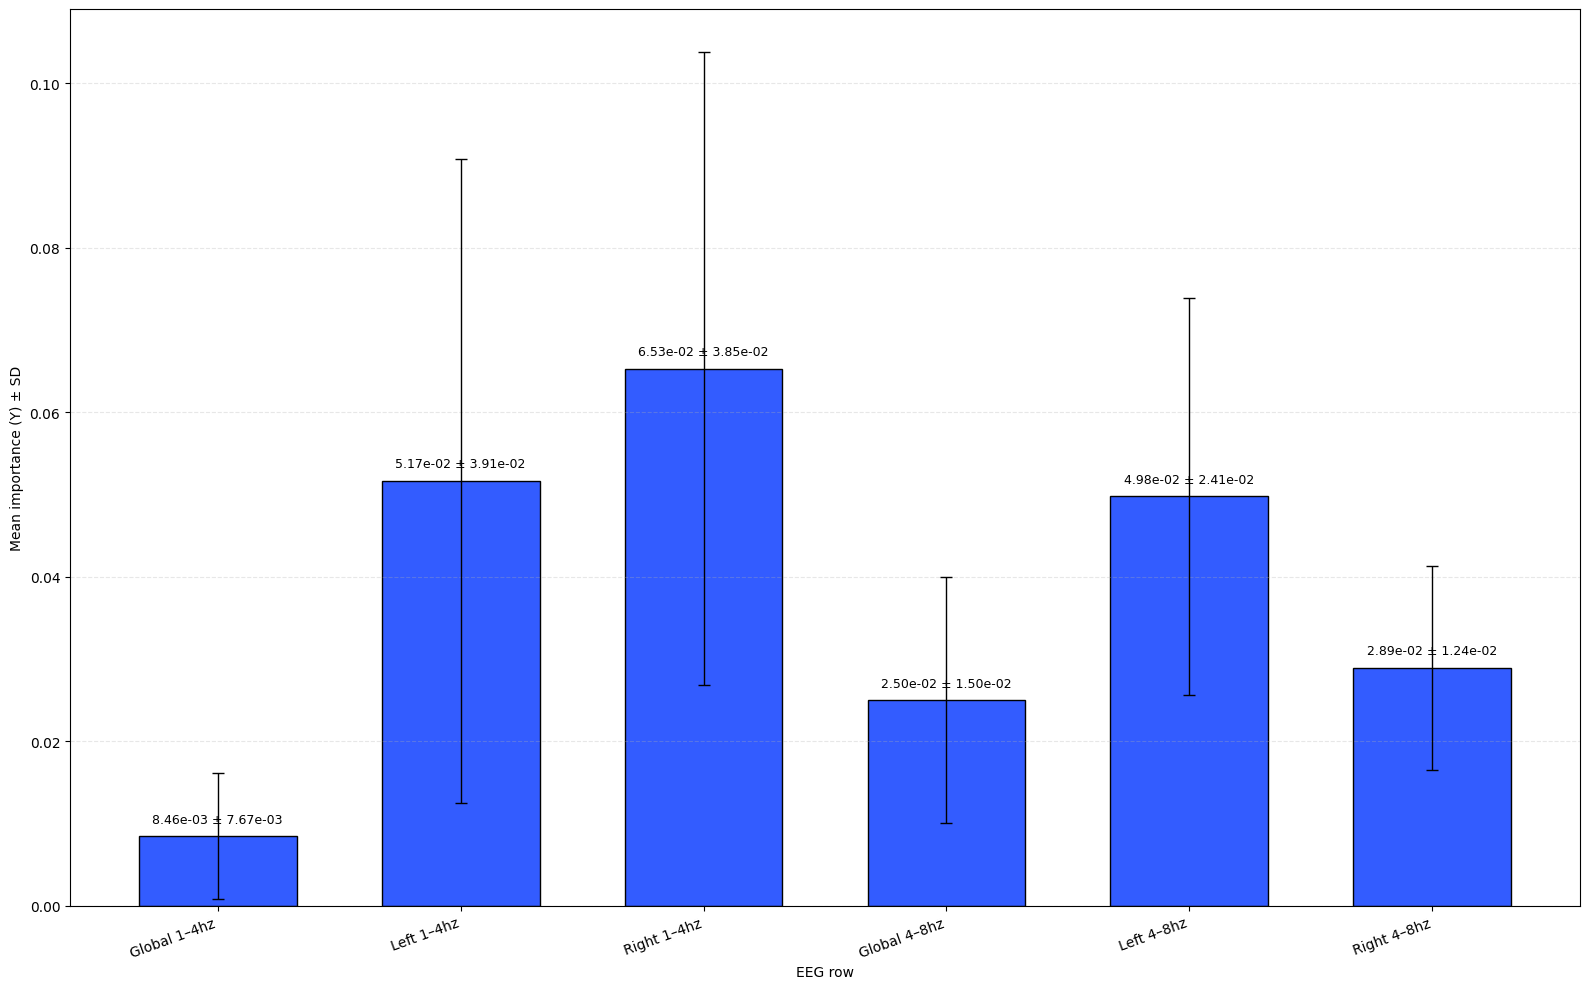

In [120]:
# 1) Choose the exact fold order you want (no surprises)
folds = sorted(results.keys())  # or explicitly: folds = [1,2,3,4,5,6,7]

# 2) Build Y matrix strictly in that order and with your row order
y_cols = []
for f in folds:
    y_imp = np.asarray(results[f][0]).reshape(-1)  # Y only
    assert y_imp.shape[0] == len(ROW_LABELS), f"Fold {f} has {y_imp.shape[0]} rows, expected {len(ROW_LABELS)}."
    y_cols.append(y_imp)
Y = np.column_stack(y_cols)  # shape (6, len(folds))

# Optional: show the table (rows=ROW_LABELS order, columns=folds order)
imp_table = pd.DataFrame(Y, index=ROW_LABELS, columns=[f"Fold {f}" for f in folds])
print(imp_table)

# 3) Line plot across folds (row order preserved)
plt.figure(figsize=(16, 10))
for r, label in enumerate(ROW_LABELS):
    plt.plot(folds, Y[r, :], marker='o', linewidth=2, label=label)
plt.xticks(folds, [str(f) for f in folds])
plt.xlabel("Fold")
plt.ylabel("Importance (Y)")
plt.grid(True, alpha=0.35)
plt.legend(ncol=3, frameon=True)
plt.tight_layout()
plt.show()

# 4) Bar chart of mean ± SD across folds (NO sorting)
avg = Y.mean(axis=1)
std = Y.std(axis=1, ddof=1)

x = np.arange(len(ROW_LABELS))
plt.figure(figsize=(16, 10))
plt.bar(
    x, avg, yerr=std, width=0.65,
    color="#335CFF", edgecolor="black", linewidth=1.0,
    error_kw=dict(ecolor="black", elinewidth=1.0, capsize=4)
)
plt.xticks(x, ROW_LABELS, rotation=20, ha="right")
plt.ylabel("Mean importance (Y) ± SD")
plt.xlabel("EEG row")
plt.grid(axis="y", linestyle="--", alpha=0.3)

# annotate values (optional)
for xi, m, s in zip(x, avg, std):
    plt.text(xi, m + (0.02 * max(abs(avg)) if max(abs(avg)) > 0 else 1e-12),
             f"{m:.2e} ± {s:.2e}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### All 9 features together

     feature  mean_importance  std_importance
Global 1–4hz         0.008460        0.007670
  Left 1–4hz         0.051682        0.039129
 Right 1–4hz         0.065308        0.038509
Global 4–8hz         0.024994        0.014955
  Left 4–8hz         0.049767        0.024110
 Right 4–8hz         0.028937        0.012434
    age_days         0.027107        0.027065
   Diagnosis         0.195830        0.114926


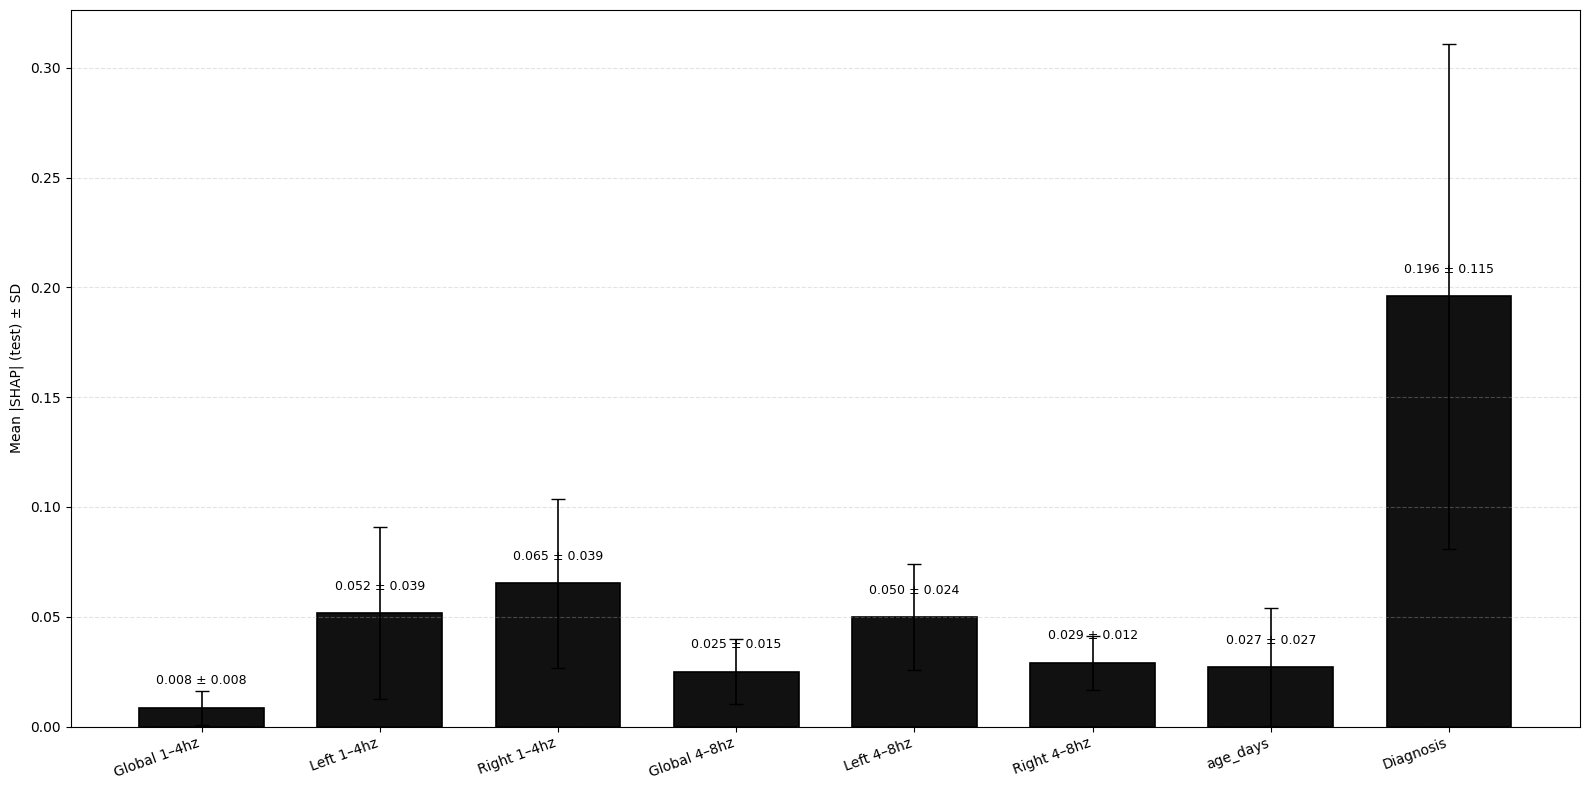

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- inputs expected ---
# results: dict where results[fold] = [compute_sum(shapY), compute_sum(shapN)], shapY -> (6,)
# age_dx_results: your dict with per-fold tabular SHAP (Age & Diagnosis)

# ---------- 1) Build EEG (Y) matrix strictly in your chosen fold order ----------
folds = sorted(results.keys())              # e.g., [1,2,3,4,5,6,7]
y_cols = []
for f in folds:
    y_imp = np.asarray(results[f][0]).reshape(-1)  # Y only, shape (6,)
    if y_imp.shape[0] != 6:
        raise ValueError(f"Fold {f} Y importance has shape {y_imp.shape}, expected 6.")
    y_cols.append(y_imp)

Y = np.column_stack(y_cols)                 # shape (6, num_folds)

# Row labels (preserve your order). If ROW_LABELS is already defined, this keeps it.
try:
    ROW_LABELS
except NameError:
    ROW_LABELS = [
        "Global 1–4 Hz",
        "Left 1–4 Hz",
        "Right 1–4 Hz",
        "Global 4–8 Hz",
        "Left 4–8 Hz",
        "Right 4–8 Hz",
    ]

# ---------- 2) Collect Age & Diagnosis per fold in the same order ----------
per_fold = age_dx_results["per_fold"]
age_key  = age_dx_results["feature_indices"].get("AGE_label", "age_days")
dx_key   = age_dx_results["feature_indices"].get("DIAGNOSIS_label", "Diagnosis")

def fold_key(f): return f"fold_{int(f):02d}"

age_vals = np.array([float(per_fold[fold_key(f)][age_key]) for f in folds], dtype=float)
dx_vals  = np.array([float(per_fold[fold_key(f)][dx_key])  for f in folds], dtype=float)

# ---------- 3) Means & stds across folds ----------
eeg_means = Y.mean(axis=1)
eeg_stds  = Y.std(axis=1, ddof=1)

age_mean, age_std = age_vals.mean(), age_vals.std(ddof=1)
dx_mean,  dx_std  = dx_vals.mean(),  dx_vals.std(ddof=1)

# Combine (6 EEG + 2 tabular)
feature_names = ROW_LABELS + [age_key, dx_key]
feature_means = np.concatenate([eeg_means, [age_mean, dx_mean]])
feature_stds  = np.concatenate([eeg_stds,  [age_std,  dx_std]])

# (optional) as a table/dict for later use
combined_df = pd.DataFrame({
    "feature": feature_names,
    "mean_importance": feature_means,
    "std_importance": feature_stds
})
combined_stats = {
    "features": feature_names,
    "means": feature_means.tolist(),
    "stds": feature_stds.tolist(),
    "fold_order": folds,
}

print(combined_df.to_string(index=False))

# ---------- 4) Plot: 8 features mean ± std (ALL BLACK) ----------
plt.figure(figsize=(16, 8))
x = np.arange(len(feature_names))
bars = plt.bar(
    x, feature_means, yerr=feature_stds, width=0.70,
    color="#111111", edgecolor="black", linewidth=1.2,
    error_kw=dict(ecolor="black", elinewidth=1.2, capsize=5)
)

plt.xticks(x, feature_names, rotation=20, ha="right")
plt.ylabel("Mean |SHAP| (test) ± SD")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# annotate: “m ± s”
ymax = (feature_means + feature_stds).max()
offset = 0.03 * ymax if ymax > 0 else 1e-3
for xi, m, s in zip(x, feature_means, feature_stds):
    plt.text(xi, m + offset, f"{m:.3f} ± {s:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


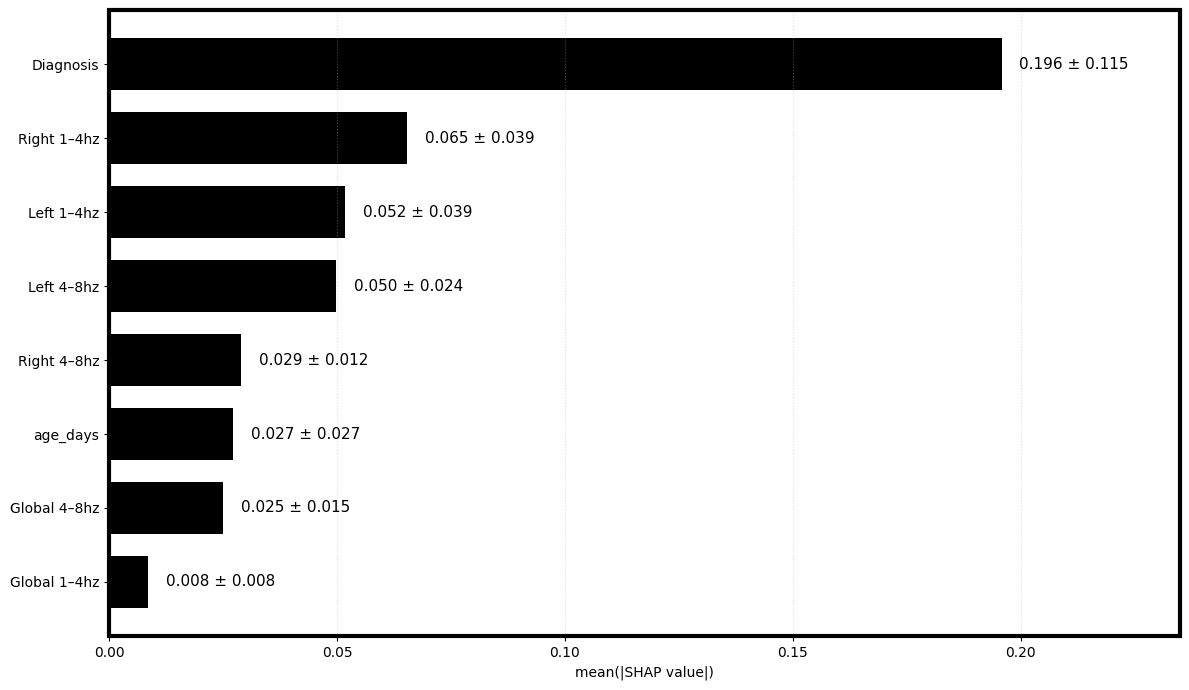

In [128]:
# ---------- 4) Plot: horizontal bars like reference (value ± std, no '+') ----------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# sort by mean descending so the largest is on top
order = np.argsort(feature_means)[::-1]
names = [feature_names[i] for i in order]
means = feature_means[order]
stds  = feature_stds[order]

fig, ax = plt.subplots(figsize=(12, 7))

ypos = np.arange(len(names))
bars = ax.barh(ypos, means, height=0.7, color="black")
ax.invert_yaxis()  # largest at top

ax.set_yticks(ypos)
ax.set_yticklabels(names)
ax.set_xlabel("mean(|SHAP value|)")
ax.grid(axis="x", linestyle=":", alpha=0.4)

# room on the right for labels
xmax = means.max()
ax.set_xlim(0, xmax * 1.20)

# annotate at the end of each bar: "m ± s"
offset = xmax * 0.02 if xmax > 0 else 1e-3
for y, m, s in zip(ypos, means, stds):
    ax.text(m + offset, y, f"{m:.3f} ± {s:.3f}", va="center", ha="left",
            fontsize=11, color="black")

# optional: keep default spines, or hide them if you only want the custom frame
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

# ---- add black box (frame) around the plotting area ----
frame = Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                  fill=False, edgecolor="black", linewidth=3.0,
                  clip_on=False, zorder=10)
ax.add_patch(frame)

plt.tight_layout()
plt.show()


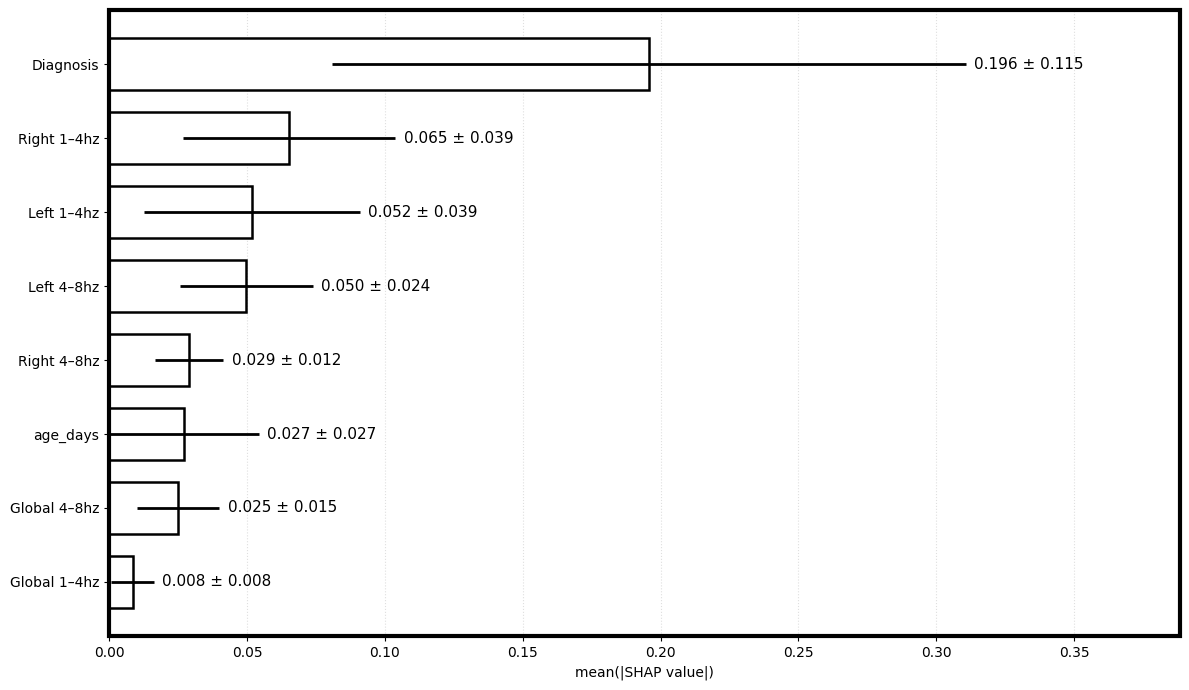

In [130]:
# ---------- Horizontal bars: white bars + black std sticks + non-overlapping labels ----------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle  # <-- add this import

# sort by mean descending
order  = np.argsort(feature_means)[::-1]
names  = [feature_names[i] for i in order]
means  = feature_means[order]
stds   = feature_stds[order]

fig, ax = plt.subplots(figsize=(12, 7))

ypos = np.arange(len(names))

# white bars with black edges
ax.barh(ypos, means, height=0.7,
        facecolor="white", edgecolor="black", linewidth=1.8, zorder=2)

# black "sticks" for ± std (horizontal errorbars centered at the mean)
ax.errorbar(means, ypos, xerr=stds,
            fmt="none", ecolor="black", elinewidth=2.0, capsize=0, zorder=3)

# largest on top
ax.invert_yaxis()
ax.set_yticks(ypos); ax.set_yticklabels(names)
ax.set_xlabel("mean(|SHAP value|)")
ax.grid(axis="x", linestyle=":", alpha=0.4, zorder=1)

# give room for the errorbars + text
xmax = float(np.max(means + stds))
ax.set_xlim(0, xmax * 1.25)

# annotate to the right of the whisker (bar end + std), with a small point offset
text_transform = mtransforms.ScaledTranslation(6/72., 0, fig.dpi_scale_trans)  # 6 pt right
for y, m, s in zip(ypos, means, stds):
    x_at_label = m + s  # end of whisker
    ax.text(x_at_label, y, f"{m:.3f} ± {s:.3f}",
            transform=ax.transData + text_transform,
            va="center", ha="left", fontsize=11, color="black", zorder=4)

# hide default spines if you only want the custom frame
for s in ax.spines.values():
    s.set_visible(False)

# ---- add black box (frame) around the plotting area ----
frame = Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                  fill=False, edgecolor="black", linewidth=3.0,
                  clip_on=False, zorder=10)
ax.add_patch(frame)

plt.tight_layout()
plt.show()


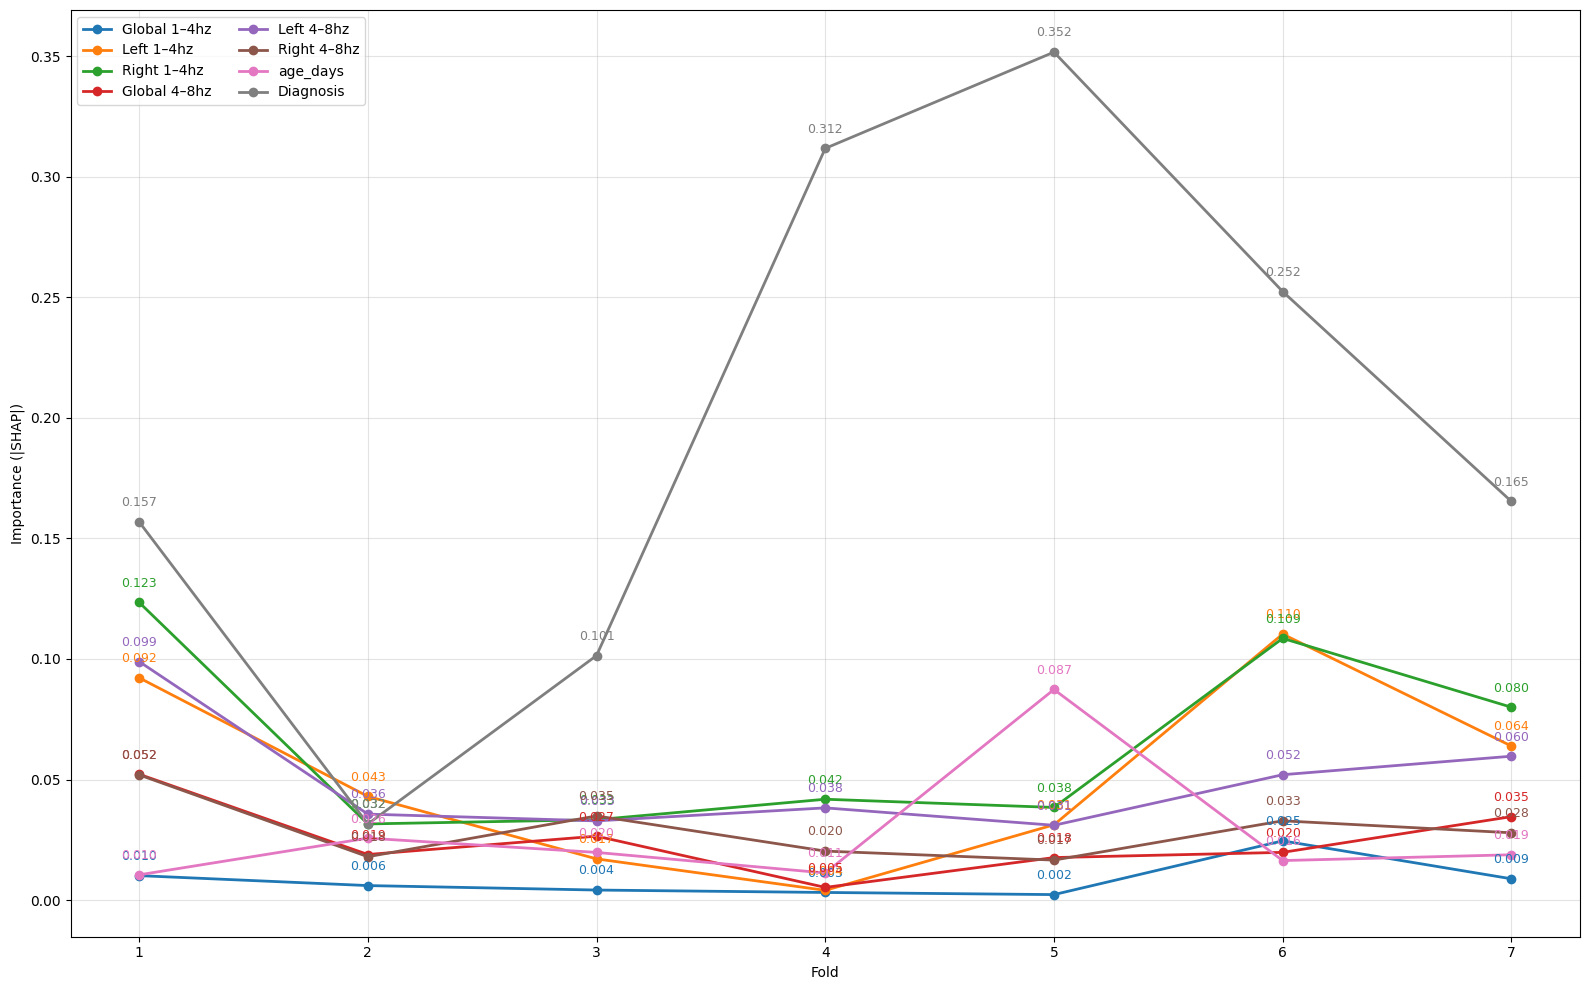

In [123]:
# ===== Build Y8 (8 x num_folds) and labels8, then plot across folds =====
import numpy as np
import matplotlib.pyplot as plt

# 0) Helpers / inputs expected:
# - results[fold] = [shapY_sum, shapN_sum], where shapY_sum has shape (6,)
# - age_dx_results["per_fold"]["fold_XX"] has AGE & DIAGNOSIS keys (labels may vary)
def fold_key(f): return f"fold_{int(f):02d}"

# Find the actual labels used for AGE and DIAGNOSIS in age_dx_results
age_key  = age_dx_results["feature_indices"].get("AGE_label",  "age")
dx_key   = age_dx_results["feature_indices"].get("DIAGNOSIS_label", "Diagnosis")
per_fold = age_dx_results["per_fold"]

# 1) Align folds to the intersection of what's available in both sources
folds_results = sorted(results.keys())
folds_tabular = sorted(int(k.split("_")[1]) for k in per_fold.keys() if k.startswith("fold_"))
folds = [f for f in folds_results if fold_key(f) in per_fold]  # common folds only
if not folds:
    raise ValueError("No common folds between `results` and `age_dx_results`.")

# 2) Build EEG (6 x F) from results in the chosen fold order
y_cols = []
for f in folds:
    y_imp = np.asarray(results[f][0]).reshape(-1)
    if y_imp.shape[0] != 6:
        raise ValueError(f"Fold {f} EEG Y has shape {y_imp.shape}, expected (6,).")
    y_cols.append(y_imp)
Y = np.column_stack(y_cols)  # (6, F)

# 3) Collect AGE & DIAGNOSIS per fold (vectors of length F)
age_vals = np.array([float(per_fold[fold_key(f)][age_key]) for f in folds], dtype=float)
dx_vals  = np.array([float(per_fold[fold_key(f)][dx_key])  for f in folds], dtype=float)

# 4) Compose Y8 (8 x F) and labels8
try:
    ROW_LABELS  # if previously defined, reuse
except NameError:
    ROW_LABELS = [
        "Global 1–4 Hz","Left 1–4 Hz","Right 1–4 Hz",
        "Global 4–8 Hz","Left 4–8 Hz","Right 4–8 Hz",
    ]
if len(ROW_LABELS) != 6:
    raise ValueError(f"ROW_LABELS length {len(ROW_LABELS)} != 6.")

Y8 = np.vstack([Y, age_vals[None, :], dx_vals[None, :]])  # (8, F)
labels8 = ROW_LABELS + [age_key, dx_key]

# 5) Line plot: 8 features across folds + numeric labels on each point
NUM_FMT = "{:.3f}"          # how each value is rendered
LABEL_OFFSET_FRAC = 0.015   # vertical offset as a fraction of y-range

fig, ax = plt.subplots(figsize=(16, 10))

ymin, ymax = float(np.min(Y8)), float(np.max(Y8))
yrange = max(ymax - ymin, 1e-12)
y_off = LABEL_OFFSET_FRAC * yrange

for i, lab in enumerate(labels8):
    line, = ax.plot(folds, Y8[i, :], marker='o', linewidth=2, label=lab)
    color = line.get_color()
    # numeric label above each point
    for x, y in zip(folds, Y8[i, :]):
        ax.text(x, float(y) + y_off, NUM_FMT.format(float(y)),
                ha="center", va="bottom", fontsize=9, color=color, clip_on=True)

ax.set_xticks(folds, [f"{f}" for f in folds])
ax.set_xlabel("Fold")
ax.set_ylabel("Importance (|SHAP|)")
ax.grid(True, alpha=0.35)
ax.legend(ncol=2, frameon=True, loc="upper left")
plt.tight_layout()
plt.show()


### The swam plot for all 8 features

X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (293, 360, 6, 1)
X_tab_test.shape = (293, 2)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (293, 360, 6, 1)
  shapY: (293, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (124, 360, 6, 1)
X_tab_test.shape = (124, 2)


SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (124, 360, 6, 1)
  shapY: (124, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (127, 360, 6, 1)
X_tab_test.shape = (127, 2)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (127, 360, 6, 1)
  shapY: (127, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (69, 360, 6, 1)
X_tab_test.shape = (69, 2)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (69, 360, 6, 1)
  shapY: (69, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (110, 360, 6, 1)
X_tab_test.shape = (110, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (110, 360, 6, 1)
  shapY: (110, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (243, 360, 6, 1)
X_tab_test.shape = (243, 2)


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (243, 360, 6, 1)
  shapY: (243, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (224, 360, 6, 1)
X_tab_test.shape = (224, 2)


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (224, 360, 6, 1)
  shapY: (224, 360, 6, 1)


/tmp/ipython-input-614652414.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


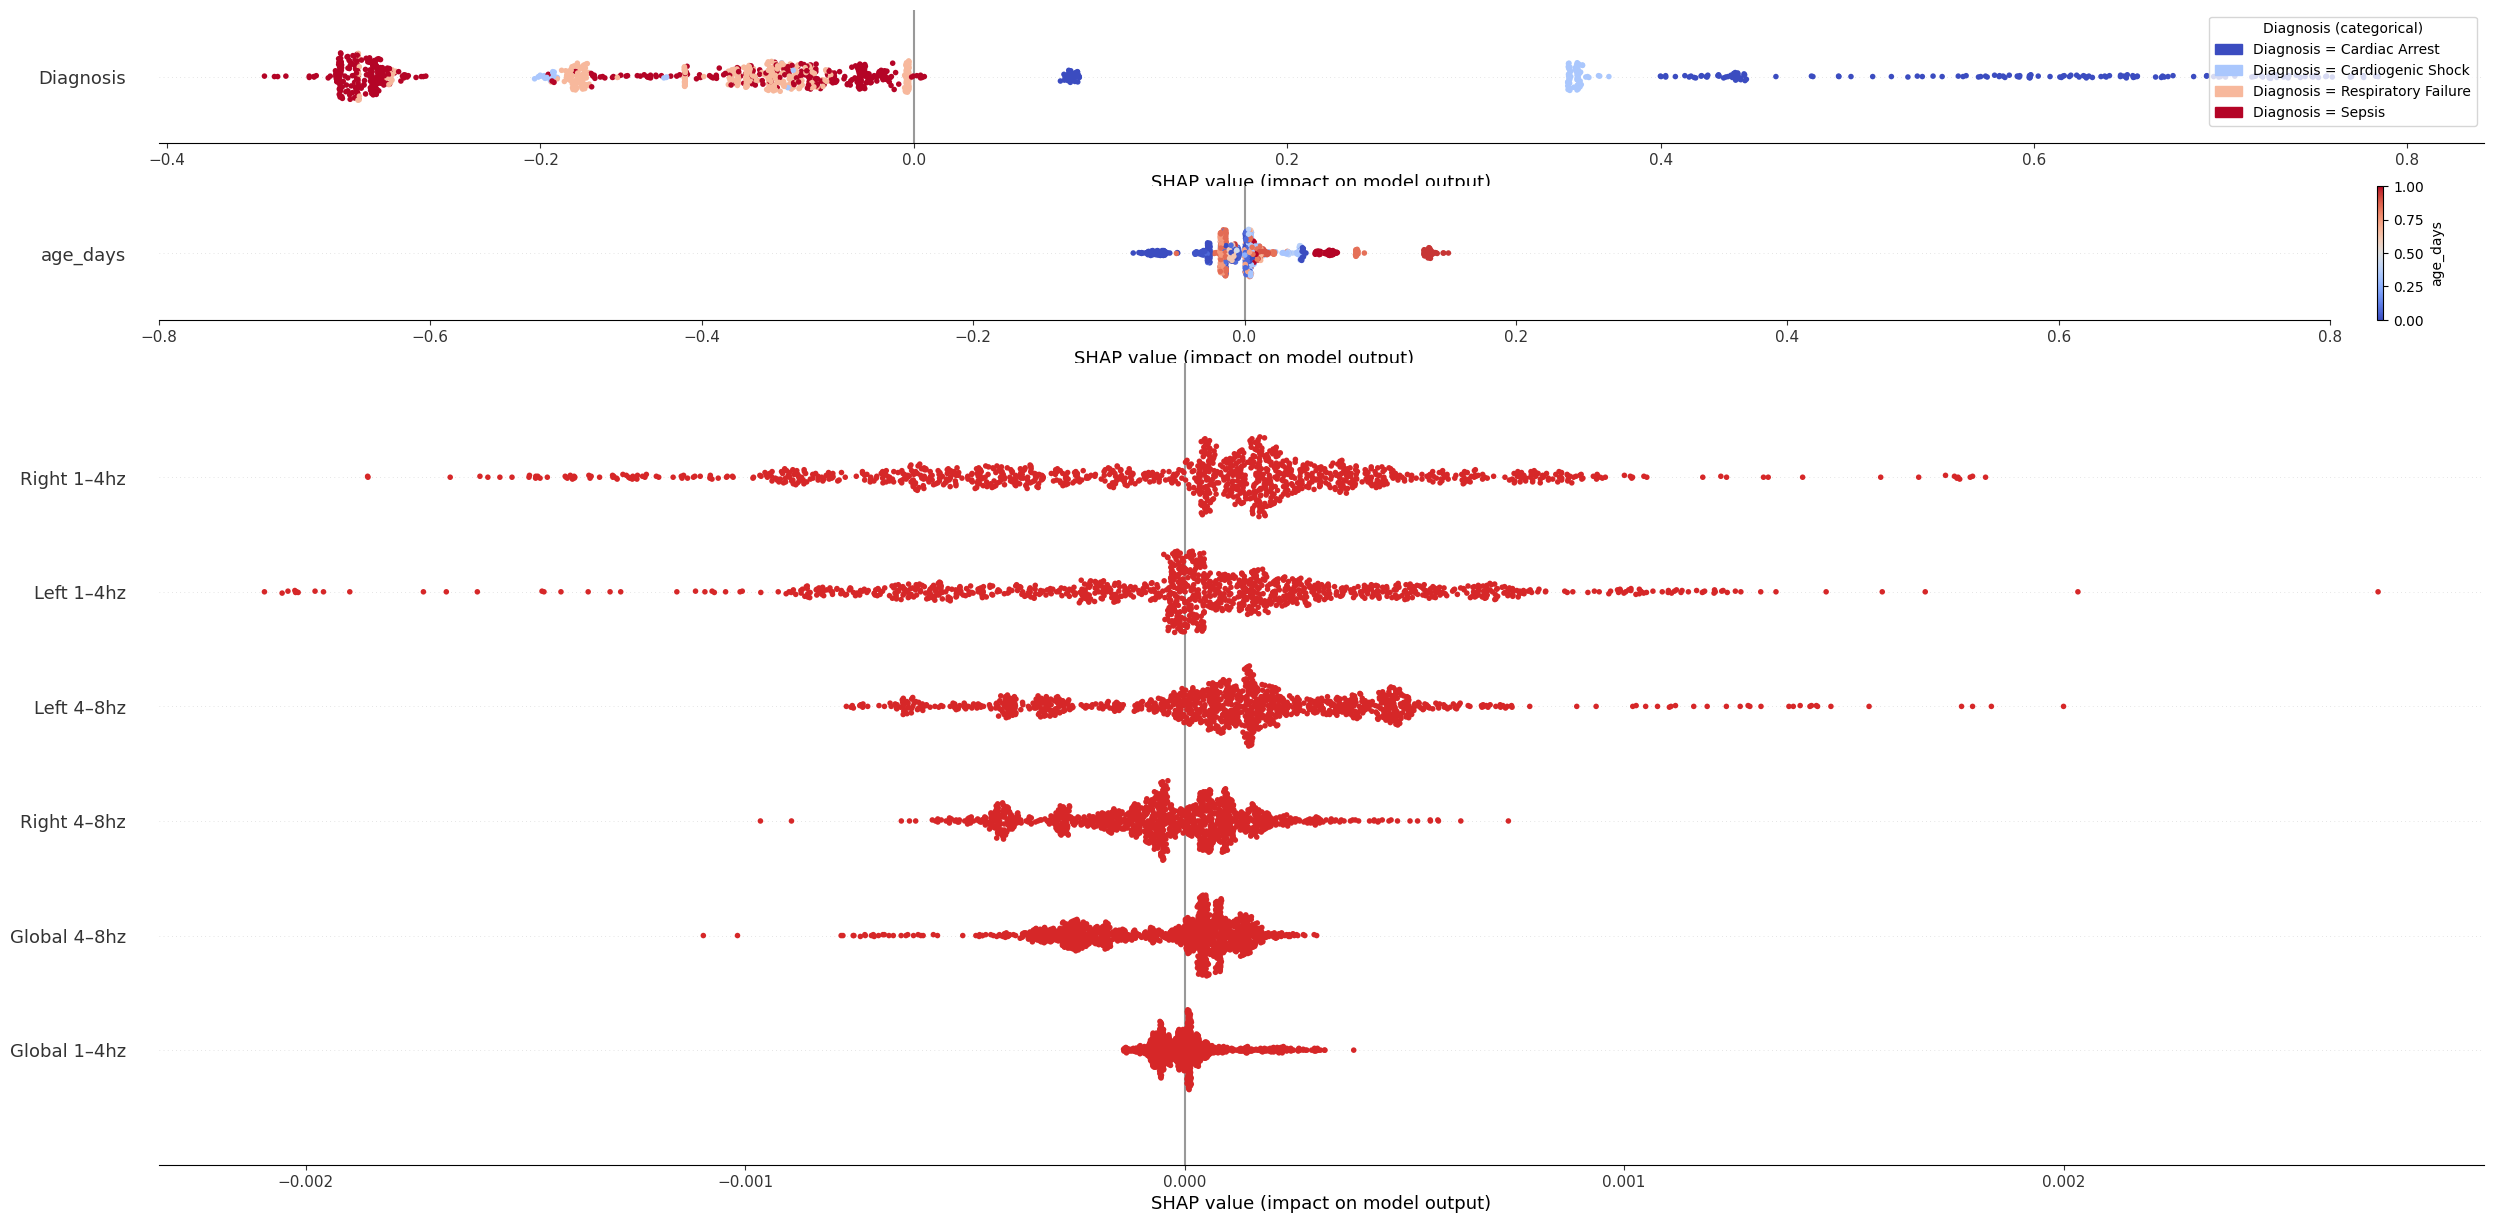

  Global 1–4hz: min=-0.0001388, max=0.0003849, negatives=606
    Left 1–4hz: min=-0.002094, max=0.002716, negatives=519
   Right 1–4hz: min=-0.001859, max=0.001823, negatives=479
  Global 4–8hz: min=-0.001095, max=0.0003006, negatives=523
    Left 4–8hz: min=-0.0007697, max=0.002, negatives=356
   Right 4–8hz: min=-0.0009652, max=0.0007368, negatives=663


In [124]:
# ===================== LOAD AGE & DX, PLOT + ADD EEG 6-FEATURE BEESWARM =====================
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import shap

# --------- 0) Config / paths ---------
PKL_PATH = Path("/content/drive/MyDrive/CD/2Bio_SHAP/exports/shap_age_diagnosis.pkl")
SAVE_DIR = Path("/content/drive/MyDrive/CD/2Bio_SHAP/")  # for EEG SHAP per fold
FOLDS    = range(1, 8)  # 1..7
BACKGROUND_N = 128      # <- use what you used previously

# If you already set W,H before, this preserves; else fallback
W, H = 30, 20  # your previous choice

AGE_XMAX = 0.8  # fix Age x-axis to ±0.8

# --------- 1) Helpers ---------
def to_0123(a):
    """Snap any float-like Dx to integer codes {0,1,2,3}."""
    a = np.asarray(a).reshape(-1)
    choices = np.array([0., 1., 2., 3.], dtype=float)
    idx = np.argmin(np.abs(a[:, None] - choices[None, :]), axis=1)
    return choices[idx].astype(int)

def fold_dir(base, i):  # path helper
    return Path(base) / f"fold_{i:02d}"

# EEG labels (reuse existing ROW_LABELS if present, else define)
try:
    if len(ROW_LABELS) != 6:
        raise ValueError
    EEG_LABELS = ROW_LABELS
except Exception:
    EEG_LABELS = [
        "Global 1–4 Hz","Left 1–4 Hz","Right 1–4 Hz",
        "Global 4–8 Hz","Left 4–8 Hz","Right 4–8 Hz",
    ]

# --------- 2) Load AGE & DX arrays from pickle ---------
with open(PKL_PATH, "rb") as f:
    D = pickle.load(f)

S_age = np.asarray(D["arrays"]["S_age"])          # (N_total,)
S_dx  = np.asarray(D["arrays"]["S_dx"])           # (N_total,)
V_age = np.asarray(D["arrays"]["V_age"])          # (N_total,)
V_dx_codes = np.asarray(D["arrays"]["V_dx_codes"])  # (N_total,) in {0,1,2,3}

AGE_LABEL = D["meta"]["age_label"]
DX_LABEL  = D["meta"]["dx_label"]
dx_text_labels = D["meta"].get("dx_text_labels", {0:"0",1:"1",2:"2",3:"3"})
# keys could be strings if saved that way — normalize
dx_text_labels = {int(k): v for k, v in {**{0:"0",1:"1",2:"2",3:"3"}, **dx_text_labels}.items()}

# Map Dx integer codes to four discrete bins just for coloring & legend
dx_bin_values = {0: -1.5, 1: -0.5, 2: 0.5, 3: 1.5}
V_dx_bins = np.array([dx_bin_values[int(c)] for c in V_dx_codes], dtype=float)

# Build 1-feature Explanations for Dx & Age
exp_dx  = shap.Explanation(values=S_dx.reshape(-1, 1),
                           data=V_dx_bins.reshape(-1, 1),
                           feature_names=[DX_LABEL])
exp_age = shap.Explanation(values=S_age.reshape(-1, 1),
                           data=V_age.reshape(-1, 1),
                           feature_names=[AGE_LABEL])

# --------- 3) Compute per-sample EEG SHAP across all folds (SIGNED) ---------
def eeg_signed_values(shapY, shapN, reducer="mean"):
    """
    Return signed EEG contributions toward the 'Yes' class.
    shapY/shapN: (N, T, 6, 1)
    reducer: 'mean' (scale-invariant) or 'sum'
    """
    A = np.asarray(shapY, dtype=float)
    B = np.asarray(shapN, dtype=float)
    D = A - B  # signed toward Yes
    if reducer == "mean":
        return np.mean(D, axis=(1, 3))  # (N, 6)
    elif reducer == "sum":
        return np.sum(D, axis=(1, 3))   # (N, 6)
    else:
        raise ValueError("reducer must be 'mean' or 'sum'")

all_eeg = []
for i in FOLDS:
    shapN, shapY, info = compute_eeg_shap_per_sample(
        save_dir=str(SAVE_DIR),
        fold_to_run=i,
        background_n=BACKGROUND_N
    )
    vals = eeg_signed_values(shapY, shapN, reducer="mean")  # (N, 6), signed
    if vals.shape[1] != 6:
        raise ValueError(f"Fold {i}: expected 6 EEG features, got {vals.shape[1]}")
    all_eeg.append(vals)

S_eeg = np.concatenate(all_eeg, axis=0)  # (N_total, 6)

# Explanation for EEG panel (6 features). Use a solid-red colormap (no colorbar).
from matplotlib.colors import LinearSegmentedColormap
allred = LinearSegmentedColormap.from_list("allred", ["#d62728", "#d62728"])
exp_eeg = shap.Explanation(
    values=S_eeg,
    data=np.zeros_like(S_eeg, dtype=float),
    feature_names=EEG_LABELS
)

# --------- 4) Plot: three stacked panels (Dx, Age, EEG6) ----------
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

cmap = plt.get_cmap("coolwarm")
dx_norm  = mcolors.Normalize(vmin=min(dx_bin_values.values()),
                             vmax=max(dx_bin_values.values()))
age_norm = mcolors.Normalize(vmin=float(np.nanmin(V_age)),
                             vmax=float(np.nanmax(V_age)))

fig, (ax_dx, ax_age, ax_eeg) = plt.subplots(
    3, 1, figsize=(W, H),
    gridspec_kw={'height_ratios': [1, 1, 6], 'hspace': 0.12}
)

# Panel 1: Diagnosis (categorical, discrete legend)
plt.sca(ax_dx)
try:
    shap.plots.beeswarm(exp_dx, max_display=1, color=cmap, color_bar=False,
                        show=False, plot_size=(W, H/8))
except TypeError:
    shap.plots.beeswarm(exp_dx, max_display=1, color=cmap, color_bar=False, show=False)

legend_handles = [
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[k])),
                   label=f"Diagnosis = {dx_text_labels[k]}")
    for k in [0, 1, 2, 3]
]
ax_dx.legend(handles=legend_handles, title=f"{DX_LABEL} (categorical)",
             loc="upper right", frameon=True)

# Panel 2: Age (continuous colorbar) with fixed ±AGE_XMAX
plt.sca(ax_age)
try:
    shap.plots.beeswarm(exp_age, max_display=1, color=cmap, color_bar=False,
                        show=False, plot_size=(W, H/8))
except TypeError:
    shap.plots.beeswarm(exp_age, max_display=1, color=cmap, color_bar=False, show=False)
ax_age.set_xlim(-float(AGE_XMAX), float(AGE_XMAX))
sm = ScalarMappable(cmap=cmap, norm=age_norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_age, fraction=0.046, pad=0.02)
cbar.set_label(AGE_LABEL)

# Panel 3: EEG (6 features, solid red dots, no colorbar)
plt.sca(ax_eeg)
try:
    shap.plots.beeswarm(exp_eeg, max_display=6, color=allred, color_bar=False,
                        show=False, plot_size=(W, H*6/8))
except TypeError:
    shap.plots.beeswarm(exp_eeg, max_display=6, color=allred, color_bar=False, show=False)
ax_eeg.set_xlabel("SHAP value (impact on model output)")

plt.tight_layout()
plt.show()

# (optional) sanity: verify negatives exist for EEG
for k, name in enumerate(EEG_LABELS):
    mn, mx = float(S_eeg[:, k].min()), float(S_eeg[:, k].max())
    print(f"{name:>14}: min={mn:.4g}, max={mx:.4g}, negatives={(S_eeg[:,k] < 0).sum()}")


X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (293, 360, 6, 1)
X_tab_test.shape = (293, 2)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (293, 360, 6, 1)
  shapY: (293, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (124, 360, 6, 1)
X_tab_test.shape = (124, 2)


SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (124, 360, 6, 1)
  shapY: (124, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (127, 360, 6, 1)
X_tab_test.shape = (127, 2)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (127, 360, 6, 1)
  shapY: (127, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (69, 360, 6, 1)
X_tab_test.shape = (69, 2)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (69, 360, 6, 1)
  shapY: (69, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (110, 360, 6, 1)
X_tab_test.shape = (110, 2)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (110, 360, 6, 1)
  shapY: (110, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (243, 360, 6, 1)
X_tab_test.shape = (243, 2)
SHAP engine: DeepExplainer (two-output)


Per-sample SHAP done:
  shapN: (243, 360, 6, 1)
  shapY: (243, 360, 6, 1)
X_img_bg.shape = (128, 360, 6, 1)
X_tab_bg.shape = (128, 2)
X_img_test.shape = (224, 360, 6, 1)
X_tab_test.shape = (224, 2)
SHAP engine: DeepExplainer (two-output)
Per-sample SHAP done:
  shapN: (224, 360, 6, 1)
  shapY: (224, 360, 6, 1)


/tmp/ipython-input-3828918382.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


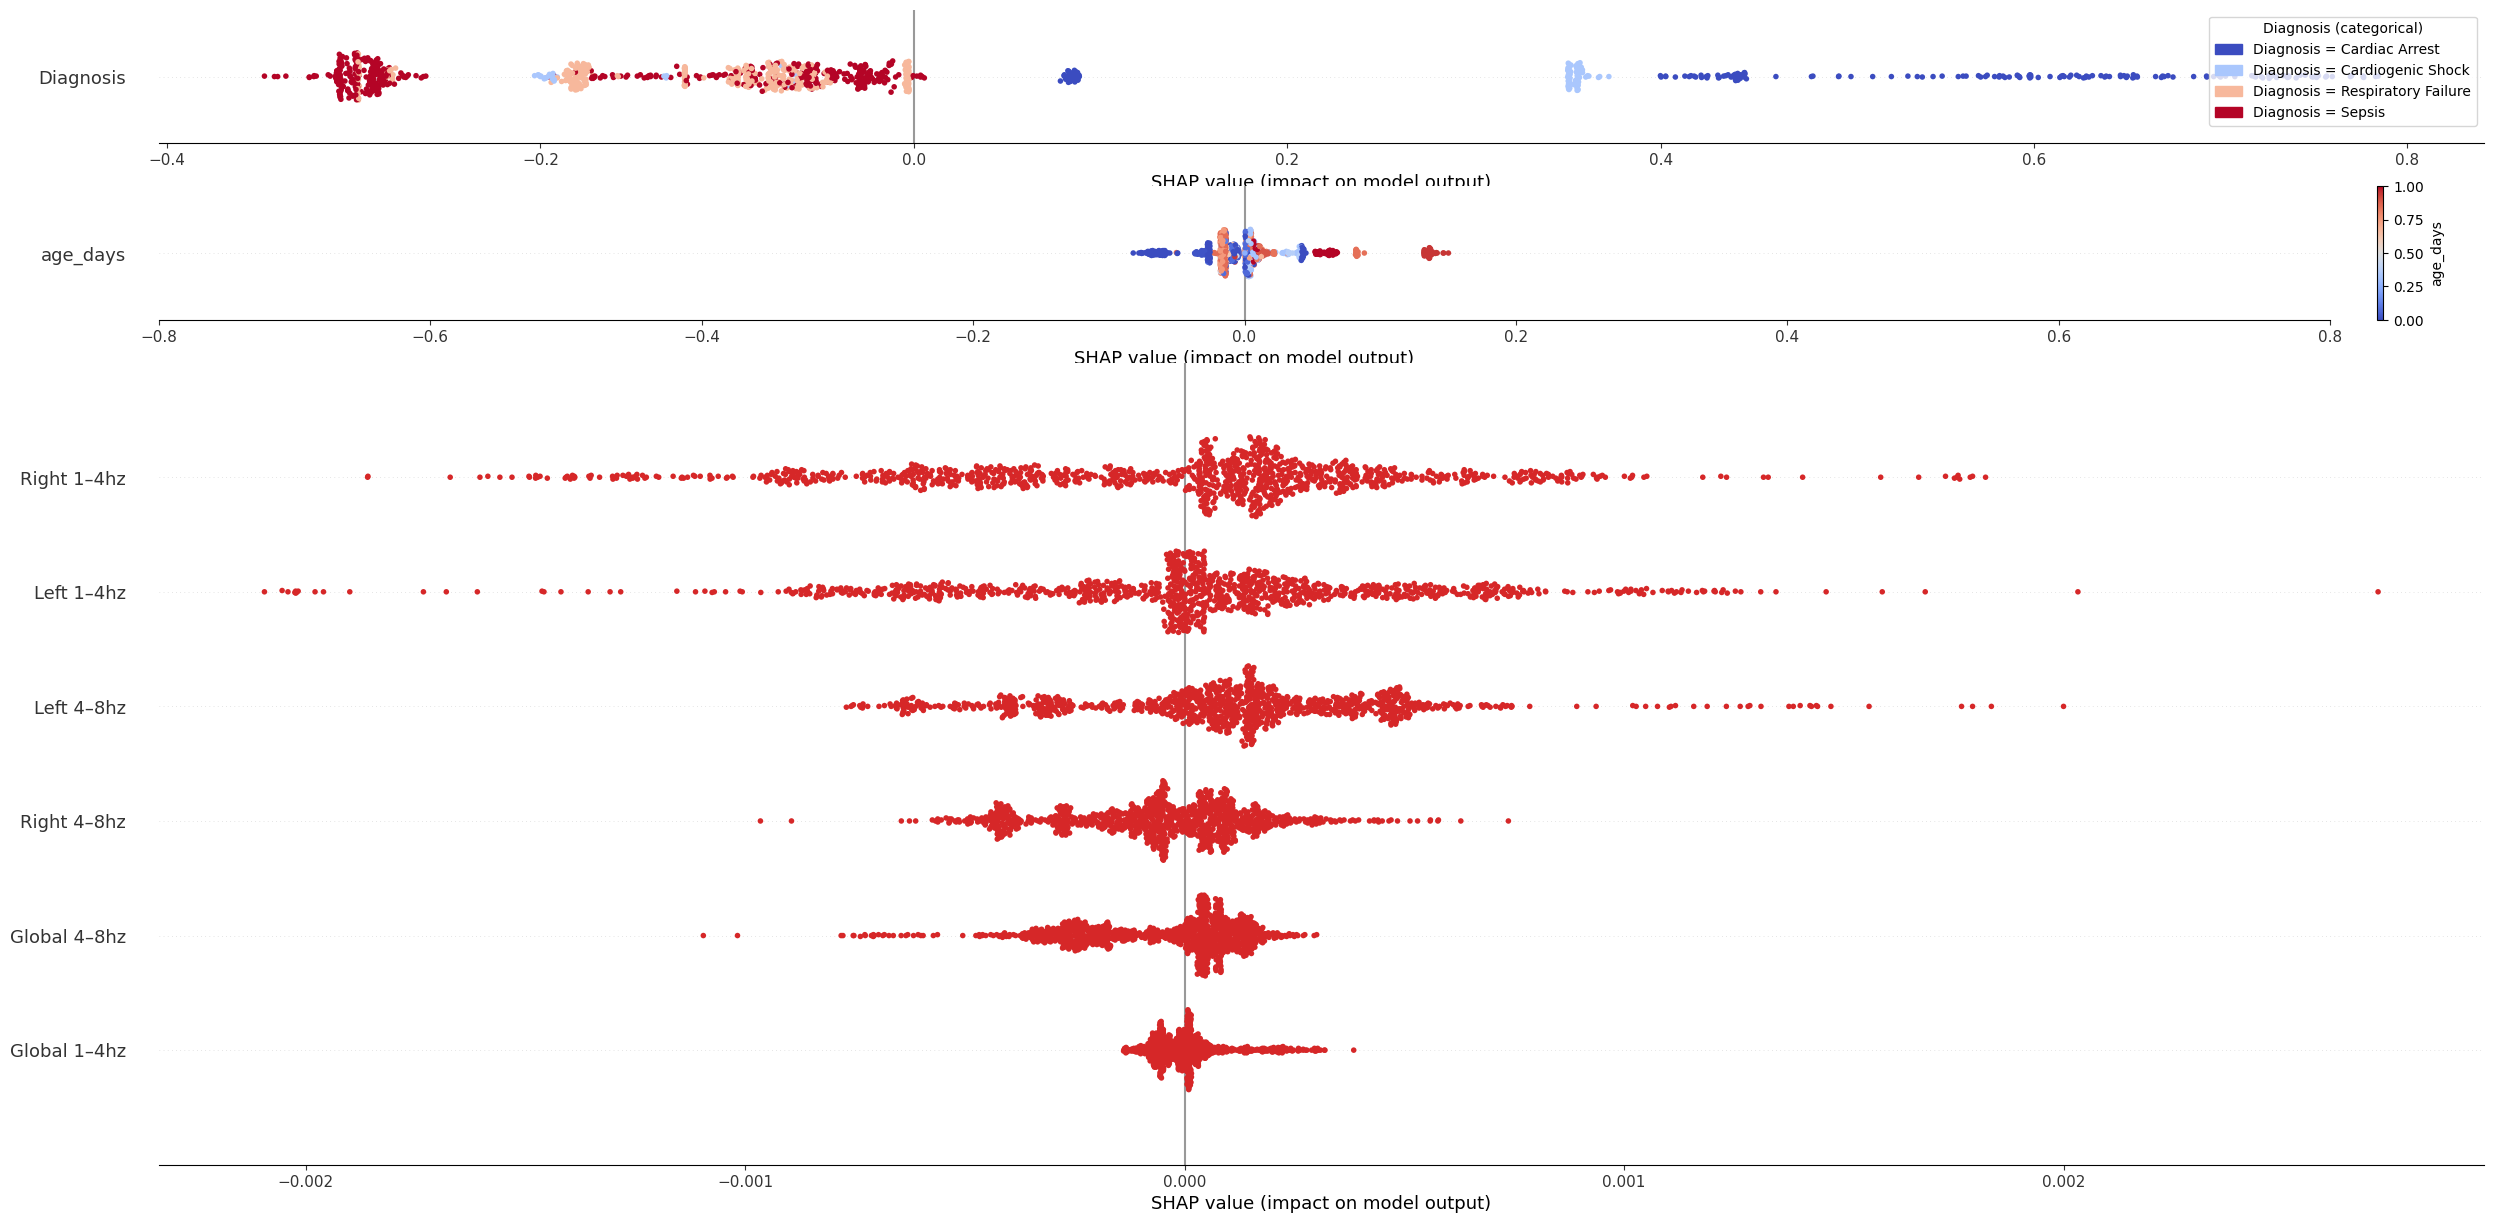

  Global 1–4hz: min=-0.0001388, max=0.0003849, negatives=606
    Left 1–4hz: min=-0.002094, max=0.002716, negatives=519
   Right 1–4hz: min=-0.001859, max=0.001823, negatives=479
  Global 4–8hz: min=-0.001095, max=0.0003006, negatives=523
    Left 4–8hz: min=-0.0007697, max=0.002, negatives=356
   Right 4–8hz: min=-0.0009652, max=0.0007368, negatives=663


In [125]:
# --------- 3) Compute per-sample EEG SHAP across all folds (SIGNED) ---------
def eeg_signed_values(shapY, shapN, reducer="mean"):
    """
    Return signed EEG contributions toward the 'Yes' class.
    shapY/shapN: (N, T, 6, 1)
    reducer: 'mean' (scale-invariant) or 'sum'
    """
    A = np.asarray(shapY, dtype=float)
    B = np.asarray(shapN, dtype=float)
    D = A - B  # signed toward Yes
    if reducer == "mean":
        return np.mean(D, axis=(1, 3))  # (N, 6)
    elif reducer == "sum":
        return np.sum(D, axis=(1, 3))   # (N, 6)
    else:
        raise ValueError("reducer must be 'mean' or 'sum'")

all_eeg = []
for i in FOLDS:
    shapN, shapY, info = compute_eeg_shap_per_sample(
        save_dir=str(SAVE_DIR),
        fold_to_run=i,
        background_n=BACKGROUND_N
    )
    vals = eeg_signed_values(shapY, shapN, reducer="mean")  # (N, 6), signed
    if vals.shape[1] != 6:
        raise ValueError(f"Fold {i}: expected 6 EEG features, got {vals.shape[1]}")
    all_eeg.append(vals)

S_eeg = np.concatenate(all_eeg, axis=0)  # (N_total, 6)

# Explanation for EEG panel (6 features). Use a solid-red colormap (no colorbar).
from matplotlib.colors import LinearSegmentedColormap
allred = LinearSegmentedColormap.from_list("allred", ["#d62728", "#d62728"])
exp_eeg = shap.Explanation(
    values=S_eeg,
    data=np.zeros_like(S_eeg, dtype=float),
    feature_names=EEG_LABELS
)

# --------- 4) Plot: three stacked panels (Dx, Age, EEG6) ----------
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

cmap = plt.get_cmap("coolwarm")
dx_norm  = mcolors.Normalize(vmin=min(dx_bin_values.values()),
                             vmax=max(dx_bin_values.values()))
age_norm = mcolors.Normalize(vmin=float(np.nanmin(V_age)),
                             vmax=float(np.nanmax(V_age)))

fig, (ax_dx, ax_age, ax_eeg) = plt.subplots(
    3, 1, figsize=(W, H),
    gridspec_kw={'height_ratios': [1, 1, 6], 'hspace': 0.12}
)

# Panel 1: Diagnosis (categorical, discrete legend)
plt.sca(ax_dx)
try:
    shap.plots.beeswarm(exp_dx, max_display=1, color=cmap, color_bar=False,
                        show=False, plot_size=(W, H/8))
except TypeError:
    shap.plots.beeswarm(exp_dx, max_display=1, color=cmap, color_bar=False, show=False)

legend_handles = [
    mpatches.Patch(color=cmap(dx_norm(dx_bin_values[k])),
                   label=f"Diagnosis = {dx_text_labels[k]}")
    for k in [0, 1, 2, 3]
]
ax_dx.legend(handles=legend_handles, title=f"{DX_LABEL} (categorical)",
             loc="upper right", frameon=True)

# Panel 2: Age (continuous colorbar) with fixed ±AGE_XMAX
plt.sca(ax_age)
try:
    shap.plots.beeswarm(exp_age, max_display=1, color=cmap, color_bar=False,
                        show=False, plot_size=(W, H/8))
except TypeError:
    shap.plots.beeswarm(exp_age, max_display=1, color=cmap, color_bar=False, show=False)
ax_age.set_xlim(-float(AGE_XMAX), float(AGE_XMAX))
sm = ScalarMappable(cmap=cmap, norm=age_norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_age, fraction=0.046, pad=0.02)
cbar.set_label(AGE_LABEL)

# Panel 3: EEG (6 features, solid red dots, no colorbar)
plt.sca(ax_eeg)
try:
    shap.plots.beeswarm(exp_eeg, max_display=6, color=allred, color_bar=False,
                        show=False, plot_size=(W, H*6/8))
except TypeError:
    shap.plots.beeswarm(exp_eeg, max_display=6, color=allred, color_bar=False, show=False)
ax_eeg.set_xlabel("SHAP value (impact on model output)")

plt.tight_layout()
plt.show()

# (optional) sanity: verify negatives exist for EEG
for k, name in enumerate(EEG_LABELS):
    mn, mx = float(S_eeg[:, k].min()), float(S_eeg[:, k].max())
    print(f"{name:>14}: min={mn:.4g}, max={mx:.4g}, negatives={(S_eeg[:,k] < 0).sum()}")


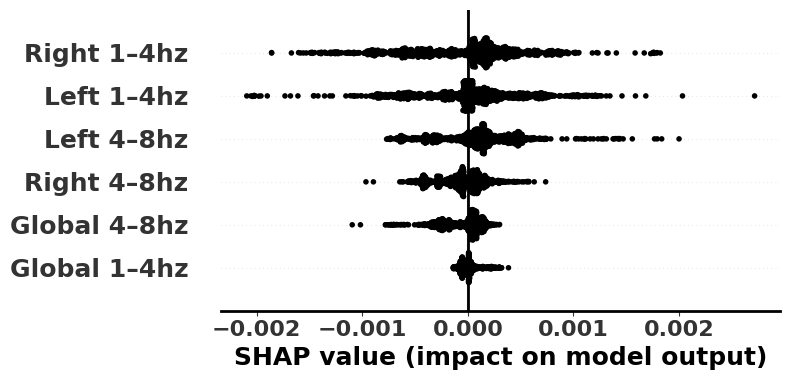

In [126]:

# plot_size=(16, 10)
# ---- EEG-only beeswarm (6 features, black dots, no colorbar) ----
# ---- EEG-only beeswarm (bigger dots, bold labels, bold black boundaries) ----
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import shap

# Build exp_eeg if it doesn't already exist
try:
    exp_eeg
except NameError:
    try:
        EEG_LABELS
    except NameError:
        EEG_LABELS = [
            "Global 1–4hz","Left 1–4hz","Right 1–4hz",
            "Global 4–8hz","Left 4–8hz","Right 4–8hz",
        ]
    exp_eeg = shap.Explanation(
        values=np.asarray(S_eeg),                         # (N_total, 6)
        data=np.zeros_like(S_eeg, dtype=float),           # dummy, we want uniform color
        feature_names=EEG_LABELS
    )

# Figure size

W, H = 30, 20

# Solid black “colormap” so all dots are black
blackmap = LinearSegmentedColormap.from_list("blackmap", ["#000000", "#000000"])

plt.figure(figsize=(W, H))
# Larger dots: try passing dot_size; fall back for SHAP versions without it
try:
    shap.plots.beeswarm(
        exp_eeg, max_display=6, color=blackmap,
        color_bar=False, show=False, plot_size=(W, H), dot_size=18
    )
except TypeError:
    shap.plots.beeswarm(
        exp_eeg, max_display=6, color=blackmap,
        color_bar=False, show=False
    )

ax = plt.gca()

# Bold/large axis labels
ax.set_xlabel("SHAP value (impact on model output)", fontsize=18, fontweight="bold")

# Bold/large tick labels
for lbl in ax.get_xticklabels():
    lbl.set_fontsize(16)
    lbl.set_fontweight("bold")
for lbl in ax.get_yticklabels():
    lbl.set_fontsize(18)
    lbl.set_fontweight("bold")

# Bold black spines (plot boundaries)
for side in ["bottom", "left", "top", "right"]:
    ax.spines[side].set_linewidth(2.0)
    ax.spines[side].set_color("black")

# Bold black baseline at x = 0
ax.axvline(0, color="black", linewidth=2.0)

plt.tight_layout()
plt.show()

# (optional) save:
# plt.savefig("eeg_beeswarm_black_bold.png", dpi=200, bbox_inches="tight")
